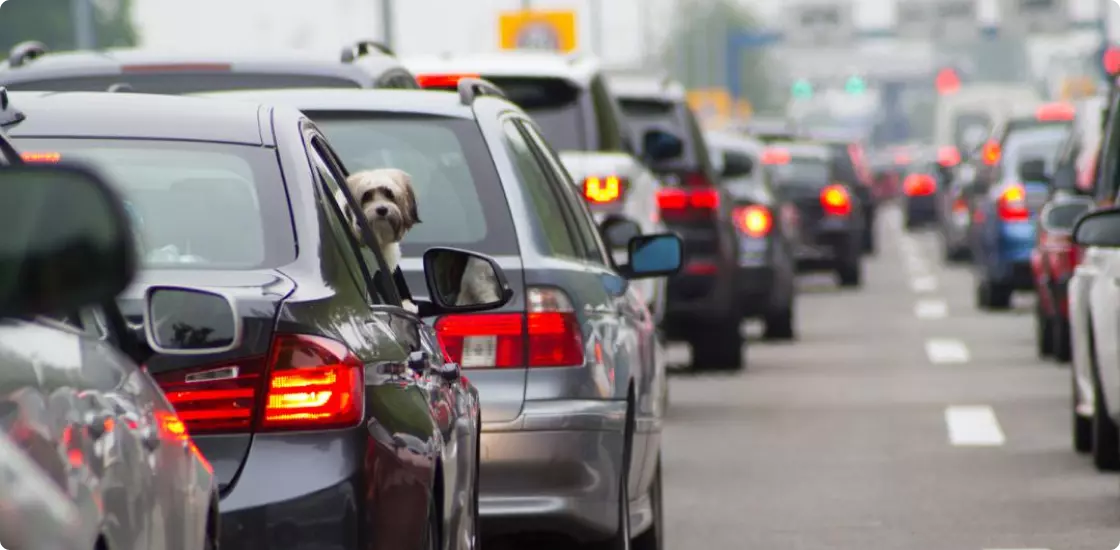

# **US Traffic Accident Analysis**

## Identifying Actionable Opportunities to Improve Road Safety

**Author:** Bennett Trott

**Stakeholder:** United States Department of Transportation (DOT)

**Dataset:** US Accidents (2016-2023)

**Data source:** Kaggle

## Step 1: Overview

This project analyzes US traffic-accident records from 2016 through 2023 to help the United States Department of Transportation identify actionable opportunities for improving road safety. The analysis examines accident frequency and severity across temporal, environmental, geographic, and roadway conditions.

The project includes data cleaning, exploratory data analysis, statistical testing, and an interactive Tableau dashboard. Its final purpose is to provide the DOT with evidence-based recommendations for prioritizing safety resources, infrastructure improvements, and targeted interventions.

### Bottom Line Up Front (BLUF)

The completed analysis highlights three findings most relevant to DOT decision-making:

1. **Junction-related accidents are a major severity concern.** Junction accidents had a severe-accident rate of **26.79%**, compared to **18.88%** for non-junction accidents. This was the strongest tested relationship among the main categorical factors and suggests that intersections, ramps, merges, and other junction areas should be prioritized for safety audits and infrastructure improvements.

2. **Precipitation is associated with a higher severe-accident rate, but the practical effect is modest.** Accidents with recorded precipitation had a severe-accident rate of **22.89%**, compared to **19.21%** for accidents without recorded precipitation. Statistical testing confirmed this relationship, but effect sizes and precipitation-amount comparisons show that precipitation is best interpreted as a contributing environmental risk factor rather than a standalone cause of severe accidents.

3. **Accident frequency and accident severity do not always follow the same patterns.** Weekdays had more total accidents, but weekends had a higher severe-accident rate: **21.60%** compared to **19.06%** on weekdays. Geographic analysis also showed that high accident-count locations are not always the highest severe-rate locations. This means DOT planning should consider both total accident volume and severe-accident rate when prioritizing interventions.

These findings support targeted recommendations focused on improving high-risk junctions, strengthening weather-responsive traffic safety measures, addressing weekend severe-accident risk, and using both accident volume and severity rate to prioritize locations for safety investments.


## **Step 2: Business Understanding**

### Business Problem

Traffic accidents create substantial public-safety and economic consequences across the United States. In addition to injuries and fatalities, accidents contribute to medical expenses, property damage, traffic congestion, emergency-response costs, and lost productivity.

The United States Department of Transportation (DOT) must determine how limited funding and safety resources can be allocated effectively. Data-driven analysis can help the DOT identify when, where, and under what conditions serious accidents are most frequently recorded. These findings can support infrastructure planning, targeted enforcement, public-warning systems, and emergency-response preparation.

### Relevance of the Data

The US Accidents dataset contains traffic-accident records from across the United States between 2016 and 2023. It includes information about:

- Accident severity
- Date and time
- Geographic location
- Weather and visibility
- Precipitation and other environmental measurements
- Daylight and twilight conditions
- Roadway features such as junctions, crossings, traffic signals, and stop signs

These variables allow accident frequency and severity to be investigated across temporal, environmental, geographic, and roadway conditions. This makes the dataset directly relevant to the DOT's goal of identifying conditions and locations that may benefit from targeted safety interventions.

The dataset contains reported accident records rather than a complete measure of all accidents or total driving exposure. Therefore, raw accident counts will not automatically be interpreted as accident risk. Population, traffic volume, vehicle miles traveled, and differences in reporting coverage may also influence recorded accident totals.

### Project Objective

The objective of this project is to identify meaningful patterns associated with recorded accident frequency and severity and translate those patterns into at least three actionable recommendations for the DOT.

The analysis is intended to help the DOT:

1. Identify conditions associated with a higher proportion of severe accidents.
2. Prioritize time periods, locations, and roadway environments for safety interventions.
3. Support infrastructure, enforcement, public-warning, and emergency-response decisions.
4. Establish measurable indicators for evaluating future safety initiatives.
5. Communicate important accident patterns to non-technical stakeholders through an interactive Tableau dashboard.

### Analytical Questions

The project will be guided by the following questions:

#### 1. Temporal and lighting conditions

How do recorded accident frequency and severity vary by hour of day, day of week, month, season, and lighting condition?

This question can help determine whether particular time periods or low-light conditions warrant additional lighting, enforcement, public warnings, or emergency-response resources.

#### 2. Environmental conditions

How are weather, visibility, precipitation, and other environmental conditions associated with accident severity?

This question can help the DOT evaluate weather-responsive interventions such as reduced-speed warnings, variable-message signs, road treatment, and targeted safety communications.

#### 3. Roadway features

Are roadway features such as junctions, crossings, traffic signals, stop signs, and railway crossings associated with differences in accident severity?

This question can help identify roadway environments that may benefit from engineering reviews, improved signage, lighting, signal modifications, or other infrastructure improvements.

#### 4. Geographic patterns

Which states, cities, or counties contain the largest concentrations of recorded accidents, and which have the highest proportions of severe recorded accidents?

This question can provide geographic context for prioritizing further investigation and resource allocation. Raw accident totals will be interpreted cautiously because the dataset does not directly measure traffic exposure.

### Stakeholders and Intended Audience

The primary stakeholder is the United States Department of Transportation, particularly officials responsible for road-safety strategy, transportation policy, and funding allocation.

Additional stakeholders include:

- State departments of transportation
- Transportation planners and traffic-safety engineers
- State and local governments
- Law-enforcement agencies
- Emergency medical and incident-response services
- Public-works departments
- Policymakers responsible for transportation funding
- Members of the public seeking understandable road-safety information

The notebook and Tableau dashboard will be designed for both technical and non-technical audiences. Findings will be presented using clear visualizations, plain-language interpretations, and specific recommendations supported by measurable evidence.

### Expected Business Benefits

This analysis could help transportation officials:

- Direct limited safety funding toward relevant conditions and locations.
- Schedule enforcement and emergency-response resources during high-priority periods.
- Identify roadway environments that warrant engineering review.
- Develop targeted weather and low-visibility safety interventions.
- Establish evidence-based support for infrastructure and policy decisions.
- Communicate safety priorities clearly to policymakers, local governments, and the public.

The project will ultimately provide three data-supported recommendations. Each recommendation will include a proposed action, its supporting evidence, potential implementation challenges, and metrics the DOT could use to evaluate its effectiveness.

## **Step 3: Data Understanding (16 Steps: 1A - 16A)**

The purpose of this section is to load the US Accidents dataset, inspect its structure, document the meaning and relevance of each variable, and identify data-quality issues that may affect the analysis.

Because the dataset is large, the initial inspection will focus on understanding the columns, data types, missing values, duplicate records, severity distribution, time coverage, geographic coverage, and potential outliers. These findings will guide the data-cleaning and feature-engineering decisions in the next section.

#### 1A Import libraries and set display options

In [2]:
# Import core data analysis libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import path library for file handling
from pathlib import Path

# Set display options for easier notebook review
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

#### 2A Define file path and confirm dataset exists

In [3]:
# Define dataset path
data_path = Path("Data/US_Accidents_March23.csv")

# Confirm the file exists before loading
print("Dataset found:", data_path.exists())

# Show file size in GB
if data_path.exists():
    file_size_gb = data_path.stat().st_size / 1_000_000_000
    print(f"File size: {file_size_gb:.2f} GB")

Dataset found: True
File size: 3.06 GB


#### 3A Preview the dataset without loading everything

In [4]:
# Load only the first few rows to inspect structure
sample_df = pd.read_csv(data_path, nrows=5)

# Display sample rows
sample_df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.90,NaN,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.90,NaN,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.00,33.30,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.10,31.00,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.00,33.30,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


#### 4A Inspect column names

In [5]:
# Display all column names
columns = sample_df.columns.tolist()

print(f"Number of columns: {len(columns)}")
columns

Number of columns: 46


['ID',
 'Source',
 'Severity',
 'Start_Time',
 'End_Time',
 'Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Country',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Direction',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Junction',
 'No_Exit',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

#### 5A Load a larger sample for initial data understanding

Since the dataset is large, we’ll inspect a representative sample first. This helps us understand data types, missingness, and value ranges quickly

In [6]:
# Load a manageable sample for initial inspection
sample_size = 100_000

df_sample = pd.read_csv(data_path, nrows=sample_size)

print(f"Sample shape: {df_sample.shape}")
df_sample.head()

Sample shape: (100000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.90,NaN,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.90,NaN,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.00,33.30,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.10,31.00,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.00,33.30,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


This means your sample successfully loaded 100,000 rows and all 46 columns from the dataset.

One important note: because this code uses: 

*pd.read_csv(data_path, nrows=sample_size)*

It loads the first 100,000 rows, not a random sample. Since the dataset appears to be ordered by time, this sample starts with early 2016 records and may overrepresent certain early states, like Ohio. That is completely fine for initial structure inspection, but later, for broader EDA, we may want to load selected columns from the full dataset or create a more representative sampled dataset.

#### 6A Basic structure

In [7]:
# Review data types and non-null counts
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  object 
 1   Source                 100000 non-null  object 
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  object 
 4   End_Time               100000 non-null  object 
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  object 
 11  Street                 100000 non-null  object 
 12  City                   99999 non-null   object 
 13  County                 100000 non-null  object 
 14  State                  100000 non-nul

#### 7A Basic descriptive statistics

In [8]:
# Descriptive statistics for numeric columns
df_sample.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,"100,000.00","100,000.00","100,000.00",0.00,0.00,"100,000.00","98,409.00","4,322.00","98,144.00","98,708.00","98,154.00","76,180.00","7,368.00"
mean,2.45,35.63,-119.32,NaN,NaN,0.01,66.64,48.85,59.79,29.96,9.34,8.04,0.03
std,0.50,2.10,3.66,NaN,NaN,0.26,12.70,19.90,23.18,0.28,1.89,4.30,0.05
min,1.00,32.54,-123.81,NaN,NaN,0.00,3.20,-8.40,4.00,2.98,0.10,0.00,0.00
25%,2.00,33.96,-121.83,NaN,NaN,0.00,57.90,37.10,43.00,29.89,10.00,4.60,0.00
50%,2.00,34.17,-118.38,NaN,NaN,0.00,66.00,42.50,62.00,29.97,10.00,6.90,0.00
75%,3.00,37.78,-117.92,NaN,NaN,0.01,75.00,63.00,78.00,30.06,10.00,10.40,0.03
max,4.00,41.43,-81.55,NaN,NaN,51.13,114.10,107.00,100.00,33.04,80.00,241.70,0.55


In [9]:
# Descriptive statistics for categorical/object columns
df_sample.describe(include="object")

,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,100000,100000,100000,100000,100000,100000,99999,100000,100000,99993,100000,99993,99993,98946,98936,98396,99999,99999,99999,99999
unique,100000,2,98896,96724,71519,9119,785,71,3,12001,1,2,121,37246,24,43,2,2,2,2
top,A-99967,Source2,2016-04-10 08:59:26,2016-10-14 19:50:00,Accident on I-80 Westbound at Exits 8A 8B I-880.,I-5 N,Los Angeles,Los Angeles,CA,91706,US,US/Pacific,KCQT,2016-11-03 10:53:00,Calm,Clear,Day,Day,Day,Day
freq,1,99950,35,24,55,2921,9792,33466,99272,712,100000,99265,7372,37,21920,57255,62510,66178,70266,74325


#### 8A Create an initial data dictionary

This table directly addresses the requirement to document each variable’s meaning and relevance.

In [10]:
data_dictionary = pd.DataFrame({
    "Column": [
        "ID", "Source", "Severity", "Start_Time", "End_Time", "Start_Lat", "Start_Lng",
        "End_Lat", "End_Lng", "Distance(mi)", "Description", "Street", "City", "County",
        "State", "Zipcode", "Country", "Timezone", "Airport_Code", "Weather_Timestamp",
        "Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
        "Wind_Direction", "Wind_Speed(mph)", "Precipitation(in)", "Weather_Condition",
        "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
        "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal",
        "Turning_Loop", "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight",
        "Astronomical_Twilight"
    ],
    "Meaning": [
        "Unique accident record identifier.",
        "Source from which the accident record was collected.",
        "Accident severity level in the dataset.",
        "Timestamp when the accident began.",
        "Timestamp when the accident ended.",
        "Latitude of the accident start location.",
        "Longitude of the accident start location.",
        "Latitude of the accident end location.",
        "Longitude of the accident end location.",
        "Estimated length of road affected by the accident.",
        "Text description of the accident event.",
        "Street where the accident was recorded.",
        "City where the accident was recorded.",
        "County where the accident was recorded.",
        "State where the accident was recorded.",
        "Zip code of the accident location.",
        "Country where the accident was recorded.",
        "Timezone of the accident location.",
        "Nearby airport weather station code.",
        "Timestamp of the weather observation.",
        "Temperature at or near the accident location.",
        "Wind chill at or near the accident location.",
        "Humidity percentage.",
        "Atmospheric pressure.",
        "Visibility in miles.",
        "Wind direction.",
        "Wind speed in miles per hour.",
        "Precipitation in inches.",
        "Reported weather condition.",
        "Whether an amenity was nearby.",
        "Whether a speed bump was nearby.",
        "Whether a crossing was nearby.",
        "Whether a give-way sign was nearby.",
        "Whether a junction was nearby.",
        "Whether a no-exit road feature was nearby.",
        "Whether a railway was nearby.",
        "Whether a roundabout was nearby.",
        "Whether a station was nearby.",
        "Whether a stop sign was nearby.",
        "Whether a traffic-calming feature was nearby.",
        "Whether a traffic signal was nearby.",
        "Whether a turning loop was nearby.",
        "Day or night condition based on sunrise/sunset.",
        "Civil twilight lighting condition.",
        "Nautical twilight lighting condition.",
        "Astronomical twilight lighting condition."
    ],
    "Potential Relevance": [
        "Record tracking only; not useful analytically except for duplicate checks.",
        "Useful for understanding data provenance and possible reporting bias.",
        "Primary outcome variable for severity analysis.",
        "Used to derive hour, weekday, month, season, and year.",
        "Used to calculate accident duration.",
        "Used for geographic mapping and spatial analysis.",
        "Used for geographic mapping and spatial analysis.",
        "May help estimate accident extent, but may contain missing values.",
        "May help estimate accident extent, but may contain missing values.",
        "Useful for measuring road impact and identifying unusually disruptive accidents.",
        "May contain useful text but is not central to this analysis.",
        "Useful for location context but may be high-cardinality.",
        "Useful for geographic summaries and dashboard filters.",
        "Useful for regional summaries.",
        "Important for geographic analysis and dashboard filters.",
        "Useful for location context but may need cleaning.",
        "Likely constant because this project focuses on the US.",
        "Useful for time-based interpretation.",
        "Useful for weather-source context.",
        "Useful for checking weather observation timing.",
        "Relevant to environmental-condition analysis.",
        "Relevant to weather severity analysis, but may have many missing values.",
        "Relevant to environmental-condition analysis.",
        "Relevant to environmental-condition analysis.",
        "Important for visibility and severe-accident analysis.",
        "Useful environmental context.",
        "Relevant to weather-related accident analysis.",
        "Relevant to precipitation and weather severity analysis.",
        "Important categorical weather variable.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Important roadway feature for infrastructure analysis.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Potential roadway/context feature.",
        "Important roadway feature for intersection/signal analysis.",
        "Likely low variation; may not be useful.",
        "Important lighting feature.",
        "Important lighting feature.",
        "Important lighting feature.",
        "Important lighting feature."
    ]
})

data_dictionary

,Column,Meaning,Potential Relevance
0,ID,Unique accident record identifier.,Record tracking only; not useful analytically ...
1,Source,Source from which the accident record was coll...,Useful for understanding data provenance and p...
2,Severity,Accident severity level in the dataset.,Primary outcome variable for severity analysis.
3,Start_Time,Timestamp when the accident began.,"Used to derive hour, weekday, month, season, a..."
4,End_Time,Timestamp when the accident ended.,Used to calculate accident duration.
5,Start_Lat,Latitude of the accident start location.,Used for geographic mapping and spatial analysis.
6,Start_Lng,Longitude of the accident start location.,Used for geographic mapping and spatial analysis.
7,End_Lat,Latitude of the accident end location.,"May help estimate accident extent, but may con..."
8,End_Lng,Longitude of the accident end location.,"May help estimate accident extent, but may con..."
9,Distance(mi),Estimated length of road affected by the accid...,Useful for measuring road impact and identifyi...


#### 9A Missing values summary

In [11]:
# Calculate missing values in the sample
missing_summary = pd.DataFrame({
    "missing_count": df_sample.isna().sum(),
    "missing_percent": (df_sample.isna().mean() * 100).round(2),
    "dtype": df_sample.dtypes
}).sort_values(by="missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent,dtype
End_Lng,100000,100.00,float64
End_Lat,100000,100.00,float64
Wind_Chill(F),95678,95.68,float64
Precipitation(in),92632,92.63,float64
Wind_Speed(mph),23820,23.82,float64
Humidity(%),1856,1.86,float64
Visibility(mi),1846,1.85,float64
Weather_Condition,1604,1.60,object
Temperature(F),1591,1.59,float64
Pressure(in),1292,1.29,float64


### Missing Values Interpretation

The initial 100,000-row sample shows that most core accident variables are complete, including `ID`, `Severity`, `Start_Time`, `End_Time`, `Start_Lat`, `Start_Lng`, `Distance(mi)`, `State`, `County`, and the roadway-feature Boolean columns. This is encouraging because these fields support the main planned analyses of accident severity, timing, geography, and roadway context.

Several columns have substantial missingness. `End_Lat` and `End_Lng` are missing for 100% of the sample, so they are unlikely to be useful for this analysis. Accident mapping will instead rely on `Start_Lat` and `Start_Lng`. `Wind_Chill(F)` is missing for approximately 95.68% of the sample, and `Precipitation(in)` is missing for approximately 92.63% of the sample. These variables may require special handling or exclusion depending on their coverage in the broader dataset.

Other weather variables have much lower missingness. `Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)`, `Wind_Direction`, `Weather_Timestamp`, and `Weather_Condition` are missing in roughly 1–2% of the sample, making them more suitable for environmental-condition analysis after cleaning.

Overall, the missing-value assessment suggests that the dataset is strong for time, severity, location, and roadway-feature analysis, while certain weather-related fields require caution.

#### 10A Duplicate Check

In [12]:
# Check duplicate rows and duplicate IDs in the sample
duplicate_rows = df_sample.duplicated().sum()
duplicate_ids = df_sample["ID"].duplicated().sum()

print(f"Duplicate rows in sample: {duplicate_rows}")
print(f"Duplicate IDs in sample: {duplicate_ids}")

Duplicate rows in sample: 0
Duplicate IDs in sample: 0


#### 11A Severity distribution

In [13]:
# Severity value counts
severity_counts = df_sample["Severity"].value_counts().sort_index()

severity_counts

Severity
1       98
2    55025
3    44844
4       33
Name: count, dtype: int64

In [14]:
# Severity percentage distribution
severity_percent = (df_sample["Severity"].value_counts(normalize=True).sort_index() * 100).round(2)

severity_percent

Severity
1    0.10
2   55.02
3   44.84
4    0.03
Name: proportion, dtype: float64

### Severity Distribution Interpretation

The severity distribution in the initial 100,000-row sample is highly concentrated in Severity 2 and Severity 3 records. Severity 2 accounts for 55.02% of the sample, while Severity 3 accounts for 44.84%. Severity 1 and Severity 4 are rare, representing only 0.10% and 0.03% of the sample, respectively.

This distribution suggests that severity-based analysis may require grouping categories to support clearer comparisons. For example, a binary severe-accident indicator may be created later by grouping Severity 3 and Severity 4 as more severe records and Severity 1 and Severity 2 as less severe records. This decision will be revisited after inspecting the broader dataset.

Because the dataset's severity variable reflects the dataset's reported severity classification, this project will interpret severity cautiously and avoid assuming it directly measures injury severity or fatality risk unless confirmed by the dataset documentation.

#### 12A Time Coverage

In [15]:
# Convert sample Start_Time and End_Time to datetime for inspection
df_sample["Start_Time"] = pd.to_datetime(df_sample["Start_Time"], errors="coerce")
df_sample["End_Time"] = pd.to_datetime(df_sample["End_Time"], errors="coerce")

print("Earliest accident start time:", df_sample["Start_Time"].min())
print("Latest accident start time:", df_sample["Start_Time"].max())
print("Missing Start_Time values:", df_sample["Start_Time"].isna().sum())
print("Missing End_Time values:", df_sample["End_Time"].isna().sum())

Earliest accident start time: 2016-02-08 05:46:00
Latest accident start time: 2017-01-26 20:07:03
Missing Start_Time values: 0
Missing End_Time values: 0


### Time Coverage Interpretation

The initial 100,000-row sample covers accident records from February 8, 2016 through January 26, 2017. Since the sample was loaded using the first 100,000 rows of the CSV, it appears to represent an early chronological portion of the full dataset rather than a random sample across all years.

This is sufficient for initial structure and data-quality inspection, but later exploratory analysis should use either the full dataset or a broader sampled dataset that better represents the full 2016–2023 period.

Both `Start_Time` and `End_Time` have zero missing values in the sample. This supports the creation of derived temporal features such as year, month, day of week, hour of day, weekend indicator, rush-hour indicator, season, and accident duration.

#### 13A Geographic Coverage

In [16]:
# Geographic coverage in the sample
print("Number of states:", df_sample["State"].nunique())
print("Number of cities:", df_sample["City"].nunique())
print("Number of counties:", df_sample["County"].nunique())

df_sample["State"].value_counts().head(15)

Number of states: 3
Number of cities: 785
Number of counties: 71


State
CA    99272
OH      726
WV        2
Name: count, dtype: int64

#### 14A Check ranges for key numeric variables

In [17]:
numeric_columns = [
    "Severity",
    "Start_Lat",
    "Start_Lng",
    "End_Lat",
    "End_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

numeric_summary = df_sample[numeric_columns].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
Severity,"100,000.00",2.45,0.50,1.00,2.00,2.00,3.00,4.00
Start_Lat,"100,000.00",35.63,2.10,32.54,33.96,34.17,37.78,41.43
Start_Lng,"100,000.00",-119.32,3.66,-123.81,-121.83,-118.38,-117.92,-81.55
End_Lat,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Lng,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance(mi),"100,000.00",0.01,0.26,0.00,0.00,0.00,0.01,51.13
Temperature(F),"98,409.00",66.64,12.70,3.20,57.90,66.00,75.00,114.10
Wind_Chill(F),"4,322.00",48.85,19.90,-8.40,37.10,42.50,63.00,107.00
Humidity(%),"98,144.00",59.79,23.18,4.00,43.00,62.00,78.00,100.00
Pressure(in),"98,708.00",29.96,0.28,2.98,29.89,29.97,30.06,33.04


### Numeric Variable Interpretation

The numeric summary confirms that the main analytical variables are mostly usable but also highlights several issues that will need to be addressed during data preparation.

`Severity` ranges from 1 to 4, with a mean of 2.45 and a median of 2.00. This is consistent with the earlier severity distribution showing that most records are classified as Severity 2 or Severity 3.

`Start_Lat` and `Start_Lng` are complete in the sample and contain plausible coordinate ranges for US accident records. These variables will be retained for geographic analysis and Tableau mapping. In contrast, `End_Lat` and `End_Lng` contain no non-null values in the sample, so they are unlikely to be useful for this project.

`Distance(mi)` is highly skewed. Most records have very short affected distances, with a median of 0.00 miles and a 75th percentile of 0.01 miles. However, the maximum value is 51.13 miles, suggesting the presence of extreme records. These may represent valid large traffic disruptions or possible data-quality issues, so distance outliers should be examined further before using this variable in analysis.

Most weather variables have generally plausible ranges, but several potential outliers are present. `Pressure(in)` has a minimum value of 2.98, which is not realistic for normal atmospheric pressure and likely represents an erroneous record. `Wind_Speed(mph)` has a maximum of 241.70 mph, which is highly implausible for typical traffic-accident conditions and should be treated as a likely outlier. `Visibility(mi)` has a maximum of 80 miles, which may be possible as a weather-station observation but is unusually high for road-condition analysis.

`Precipitation(in)` has limited non-null coverage in the sample. Because more than 92% of its values are missing, it may require special handling or exclusion from some statistical tests.

Overall, the numeric summary shows that the dataset is strong for severity, time, location, and several weather variables, but outlier handling and missing-value treatment will be important parts of the data-preparation stage.

#### 15A Check categorical variable consistency

In [18]:
categorical_columns = [
    "Source",
    "Country",
    "Timezone",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df_sample[col].value_counts(dropna=False).head(15))


Source
Source
Source2    99950
Source3       50
Name: count, dtype: int64

Country
Country
US    100000
Name: count, dtype: int64

Timezone
Timezone
US/Pacific    99265
US/Eastern      728
NaN               7
Name: count, dtype: int64

Wind_Direction
Wind_Direction
Calm        21920
West        11926
WNW          7328
Variable     6582
SSW          6340
South        6292
WSW          6172
SW           5899
NW           4623
North        3496
SSE          3110
NNW          3066
SE           2928
East         2502
ESE          2318
Name: count, dtype: int64

Weather_Condition
Weather_Condition
Clear               57255
Overcast            10255
Mostly Cloudy        8829
Partly Cloudy        8260
Scattered Clouds     5684
Light Rain           3211
Haze                 2097
NaN                  1604
Fair                 1039
Rain                  829
Heavy Rain            202
Fog                   159
Cloudy                142
Light Snow            116
Smoke                  79
Name: coun

#### 16A Check Boolean roadway feature columns

In [19]:
roadway_columns = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
]

roadway_summary = pd.DataFrame({
    "true_count": df_sample[roadway_columns].sum(),
    "true_percent": (df_sample[roadway_columns].mean() * 100).round(2)
}).sort_values(by="true_percent", ascending=False)

roadway_summary

,true_count,true_percent
Traffic_Signal,10699,10.70
Junction,10434,10.43
Crossing,6489,6.49
Stop,3324,3.32
Station,3168,3.17
Railway,1262,1.26
Amenity,784,0.78
Give_Way,166,0.17
Traffic_Calming,78,0.08
Bump,48,0.05


#### 17A Explicit outlier and inconsistency checks

In [20]:
# Check for potential numeric outliers or implausible values in the sample

outlier_checks = {
    "negative_distance": (df_sample["Distance(mi)"] < 0).sum(),
    "very_large_distance_over_10_miles": (df_sample["Distance(mi)"] > 10).sum(),
    "temperature_below_minus_40": (df_sample["Temperature(F)"] < -40).sum(),
    "temperature_above_130": (df_sample["Temperature(F)"] > 130).sum(),
    "humidity_below_0": (df_sample["Humidity(%)"] < 0).sum(),
    "humidity_above_100": (df_sample["Humidity(%)"] > 100).sum(),
    "pressure_below_20": (df_sample["Pressure(in)"] < 20).sum(),
    "pressure_above_32": (df_sample["Pressure(in)"] > 32).sum(),
    "visibility_below_0": (df_sample["Visibility(mi)"] < 0).sum(),
    "visibility_above_50": (df_sample["Visibility(mi)"] > 50).sum(),
    "wind_speed_below_0": (df_sample["Wind_Speed(mph)"] < 0).sum(),
    "wind_speed_above_100": (df_sample["Wind_Speed(mph)"] > 100).sum(),
    "precipitation_below_0": (df_sample["Precipitation(in)"] < 0).sum()
}

outlier_summary = pd.DataFrame.from_dict(
    outlier_checks,
    orient="index",
    columns=["count"]
)

outlier_summary

,count
negative_distance,0
very_large_distance_over_10_miles,10
temperature_below_minus_40,0
temperature_above_130,0
humidity_below_0,0
humidity_above_100,0
pressure_below_20,5
pressure_above_32,2
visibility_below_0,0
visibility_above_50,1


### Numeric Outliers and Implausible Values

The initial outlier check identified a small number of potentially implausible or extreme numeric values in the 100,000-row sample. No records had negative accident distances, impossible humidity values, extreme temperatures below -40°F or above 130°F, negative visibility values, negative wind speeds, or negative precipitation values. This suggests that most numeric fields are within reasonable ranges.

However, several variables contain values that should be reviewed during data preparation. There are 10 records with `Distance(mi)` greater than 10 miles. Since the median accident distance is 0.00 miles and the 75th percentile is 0.01 miles, these values are extreme relative to the rest of the sample. They may represent valid large traffic disruptions, but they could also disproportionately influence analysis involving accident distance.

The weather variables also contain a small number of suspicious values. Five records have `Pressure(in)` below 20, and two records have `Pressure(in)` above 32. These values are outside the normal range expected for atmospheric pressure and may reflect data-entry errors or weather-station issues. One record has `Visibility(mi)` above 50 miles, which is unusually high for roadway-condition analysis. Two records have `Wind_Speed(mph)` above 100 mph, which is highly unusual for normal traffic-accident conditions and may represent erroneous observations.

These outliers are rare in the sample, but they should not be ignored. During data preparation, these values will be reviewed and either removed, capped, transformed, or retained with caution depending on their relevance to the final analysis. For now, this section documents their presence so that later cleaning decisions are transparent and reproducible.

#### 18A Date consistency checks

In [21]:
# Check whether accident end times occur before start times

df_sample["Accident_Duration_Minutes"] = (
    df_sample["End_Time"] - df_sample["Start_Time"]
).dt.total_seconds() / 60

duration_summary = df_sample["Accident_Duration_Minutes"].describe()

negative_durations = (df_sample["Accident_Duration_Minutes"] < 0).sum()
zero_durations = (df_sample["Accident_Duration_Minutes"] == 0).sum()
very_long_durations = (df_sample["Accident_Duration_Minutes"] > 24 * 60).sum()

print("Negative durations:", negative_durations)
print("Zero-minute durations:", zero_durations)
print("Durations over 24 hours:", very_long_durations)

duration_summary

Negative durations: 0
Zero-minute durations: 0
Durations over 24 hours: 0


count   100,000.00
mean         42.54
std          21.51
min          10.37
25%          30.00
50%          44.28
75%          45.00
max         871.00
Name: Accident_Duration_Minutes, dtype: float64

### Accident Duration Consistency Check

The accident duration check compared `End_Time` against `Start_Time` to identify possible date or timestamp inconsistencies. In the 100,000-row sample, there were no negative durations, no zero-minute durations, and no durations greater than 24 hours. This suggests that the start and end time fields are internally consistent in the sample.

The average recorded accident duration is approximately 42.54 minutes, with a median of 44.28 minutes. The middle 50% of records fall between approximately 30.00 and 45.00 minutes. The shortest recorded duration is 10.37 minutes, while the longest is 871.00 minutes, or about 14.5 hours.

Although the maximum duration is much longer than most records, it does not exceed 24 hours and may represent a valid long-lasting incident or traffic disruption. During data preparation, accident duration may be retained as a derived feature, but highly skewed duration values should be reviewed before using duration in statistical analysis.

Overall, the duration check does not reveal major timestamp inconsistencies in the sample. This supports using `Start_Time` and `End_Time` to create derived time-based features such as accident duration, hour of day, day of week, month, season, weekend indicator, and rush-hour indicator.

#### 19A Categorical inconsistency checks

In [22]:
# Check expected values for key categorical columns

expected_day_night = {"Day", "Night"}

lighting_columns = [
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in lighting_columns:
    unexpected_values = set(df_sample[col].dropna().unique()) - expected_day_night
    print(f"{col} unexpected values:", unexpected_values)

Sunrise_Sunset unexpected values: set()
Civil_Twilight unexpected values: set()
Nautical_Twilight unexpected values: set()
Astronomical_Twilight unexpected values: set()


#### 20A Boolean consistency checks

In [23]:
# Confirm roadway feature columns are Boolean

roadway_columns = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
    "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
    "Traffic_Signal", "Turning_Loop"
]

for col in roadway_columns:
    print(f"{col}: {df_sample[col].dropna().unique()}")

Amenity: [False  True]
Bump: [False  True]
Crossing: [False  True]
Give_Way: [False  True]
Junction: [False  True]
No_Exit: [False  True]
Railway: [False  True]
Roundabout: [False  True]
Station: [False  True]
Stop: [False  True]
Traffic_Calming: [False  True]
Traffic_Signal: [False  True]
Turning_Loop: [False]


### Data Understanding Summary

The initial data-understanding process used a 100,000-row sample from the US Accidents dataset. The sample contains 46 columns describing accident severity, timing, location, weather conditions, roadway features, and lighting conditions.

The dataset structure aligns well with the business questions developed for the Department of Transportation. `Severity` provides the primary outcome for accident seriousness, while `Start_Time` and `End_Time` support temporal analysis. Geographic fields such as `State`, `County`, `City`, `Start_Lat`, and `Start_Lng` support location-based analysis and dashboard mapping. Weather fields such as `Weather_Condition`, `Temperature(F)`, `Visibility(mi)`, `Wind_Speed(mph)`, and `Precipitation(in)` support environmental-condition analysis. Boolean roadway-feature columns such as `Junction`, `Crossing`, `Stop`, and `Traffic_Signal` support infrastructure-related analysis.

The initial sample contains records from February 8, 2016 through January 26, 2017. Since the sample was created by reading the first 100,000 rows of the CSV, it should be treated as an early chronological sample rather than a representative sample of the full 2016–2023 dataset. Later exploratory analysis should use either the full dataset or a broader sampled dataset that better represents the full date range.

Most core variables are complete, including `ID`, `Severity`, `Start_Time`, `End_Time`, `Start_Lat`, `Start_Lng`, `Distance(mi)`, `State`, `County`, and the roadway-feature Boolean columns. This supports the planned analyses of accident severity, timing, geography, and roadway context. However, several variables have substantial missingness. `End_Lat` and `End_Lng` are missing for all records in the sample, while `Wind_Chill(F)` and `Precipitation(in)` are missing for most records. These fields may need to be excluded or handled carefully during data preparation.

The severity distribution is heavily concentrated in Severity 2 and Severity 3 records. Severity 2 represents 55.02% of the sample, and Severity 3 represents 44.84%. Severity 1 and Severity 4 are rare in this sample, representing only 0.10% and 0.03%, respectively. This imbalance may require grouping severity levels into broader categories for later analysis.

The time fields appear reliable in the sample. `Start_Time` and `End_Time` have no missing values, and the duration check found no negative durations, no zero-minute durations, and no durations greater than 24 hours. The average recorded accident duration is approximately 42.54 minutes, with a median of 44.28 minutes. These results support the use of time-based derived features such as hour of day, day of week, month, season, weekend indicator, rush-hour indicator, and accident duration.

Initial numeric review identified a small number of potential outliers or implausible values. There are 10 records with `Distance(mi)` greater than 10 miles, 5 records with `Pressure(in)` below 20, 2 records with `Pressure(in)` above 32, 1 record with `Visibility(mi)` above 50 miles, and 2 records with `Wind_Speed(mph)` above 100 mph. These values are rare, but they should be reviewed during data preparation to determine whether they should be removed, capped, transformed, or retained with caution.

The duplicate-record check found 0 duplicate rows and 0 duplicate accident IDs in the sample. This suggests that duplicate records are not an immediate concern in the initial sample, although duplicate checks should still be performed again if the full dataset or a larger analysis dataset is loaded.

The categorical and Boolean variables should also be reviewed for consistency. Lighting columns such as `Sunrise_Sunset`, `Civil_Twilight`, `Nautical_Twilight`, and `Astronomical_Twilight` are expected to contain only `Day`, `Night`, or missing values. Roadway-feature columns are expected to contain Boolean values. These checks help confirm that the variables can be used reliably in grouped comparisons and statistical testing.

Overall, the dataset is suitable for the planned analysis, especially for severity, timing, geography, roadway features, and several weather-related variables. The main data-quality concerns are missing values in selected columns, rare but potentially implausible numeric outliers, class imbalance in the severity variable, and the fact that the initial sample represents only an early chronological portion of the full dataset. These issues will be addressed in the data-preparation stage.

Because the initial inspection used the first 100,000 rows rather than the full dataset, these results should be treated as preliminary data-quality findings. Final exploratory analysis and statistical testing will use either the full dataset with selected columns or a broader sample that better represents the full 2016–2023 period.

## **Step 3: Data Preparation (15 Steps: 1B - 15B)**

The purpose of this section is to clean and preprocess the full US Accidents dataset for analysis. The initial data-understanding step used a 100,000-row sample to inspect structure and identify likely data-quality issues. In this section, the full dataset will be loaded using selected relevant columns to create a cleaner analysis-ready dataset.

Data preparation will include:

- Selecting variables relevant to the business questions.
- Converting date and time columns to datetime format.
- Removing duplicate records.
- Handling missing values.
- Removing or flagging implausible numeric values.
- Creating derived temporal, weather, roadway, and severity features.
- Creating descriptive statistics for the cleaned dataset.
- Saving the cleaned dataset for later EDA, statistical analysis, and Tableau dashboarding.

**Because the original dataset is large, only analytically useful columns will be loaded into memory.**

#### 1B Select Columns

In [24]:
# 1. Select columns needed for the final analysis

selected_columns = [
    # Identifiers and source
    "ID",
    "Source",
    
    # Severity outcome
    "Severity",
    
    # Time
    "Start_Time",
    "End_Time",
    
    # Geography
    "Start_Lat",
    "Start_Lng",
    "City",
    "County",
    "State",
    "Zipcode",
    "Timezone",
    
    # Accident impact
    "Distance(mi)",
    
    # Weather and environment
    "Weather_Timestamp",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Direction",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Weather_Condition",
    
    # Roadway features
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop",
    
    # Lighting
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

len(selected_columns)

39

### Column Selection

The original dataset contains 46 columns. For data preparation, 39 analytically relevant columns were retained. The selected columns focus on accident severity, timing, geography, weather conditions, roadway features, and lighting conditions, which directly support the project's business questions.

Several columns were excluded from the cleaned analysis dataset. `End_Lat` and `End_Lng` were excluded because they were completely missing in the initial sample. `Description` and `Street` were excluded because they are high-cardinality text/location fields and are not necessary for the planned aggregate analysis. `Wind_Chill(F)` was excluded because of extremely high missingness. `Country` was excluded because the dataset focuses on US accidents and is expected to provide little analytical variation. `Airport_Code` was also excluded because it primarily identifies the nearby weather station rather than serving as a central analysis feature.

Reducing the dataset to relevant columns helps improve memory efficiency while preserving the variables needed for temporal, geographic, weather-related, roadway-feature, and severity analysis.

#### 2B Load full dataset

In [25]:
# Full dataset load with selected columns only (this may take some time due to file size)
df = pd.read_csv(
    data_path,
    usecols=selected_columns,
    low_memory=False
)

print(f"Full selected dataset shape: {df.shape}")
df.head()

Full selected dataset shape: (7728394, 39)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,State,Zipcode,Timezone,Weather_Timestamp,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,0.01,Dayton,Montgomery,OH,45424,US/Eastern,2016-02-08 05:58:00,36.90,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,0.01,Reynoldsburg,Franklin,OH,43068-3402,US/Eastern,2016-02-08 05:51:00,37.90,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,0.01,Williamsburg,Clermont,OH,45176,US/Eastern,2016-02-08 06:56:00,36.00,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,0.01,Dayton,Montgomery,OH,45417,US/Eastern,2016-02-08 07:38:00,35.10,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,0.01,Dayton,Montgomery,OH,45459,US/Eastern,2016-02-08 07:53:00,36.00,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


### Full Dataset Load

The full US Accidents dataset was loaded using the 39 selected columns identified as relevant to the analysis. The resulting dataset contains 7,728,394 records and 39 columns.

This confirms that the data-preparation process is now being performed on the full dataset rather than the initial 100,000-row sample used during data understanding. Working with the full dataset allows later exploratory analysis and statistical testing to better represent the full 2016–2023 accident record period.

#### 3B Structure Inspection

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 39 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   Distance(mi)           float64
 8   City                   object 
 9   County                 object 
 10  State                  object 
 11  Zipcode                object 
 12  Timezone               object 
 13  Weather_Timestamp      object 
 14  Temperature(F)         float64
 15  Humidity(%)            float64
 16  Pressure(in)           float64
 17  Visibility(mi)         float64
 18  Wind_Direction         object 
 19  Wind_Speed(mph)        float64
 20  Precipitation(in)      float64
 21  Weather_Condition      object 
 22  Amenity           

####  4B Data Type Conversion

In [27]:
# Convert date/time columns to datetime format

df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")
df["Weather_Timestamp"] = pd.to_datetime(df["Weather_Timestamp"], errors="coerce")

df[["Start_Time", "End_Time", "Weather_Timestamp"]].dtypes

Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object

### Data Type Conversion

The `Start_Time`, `End_Time`, and `Weather_Timestamp` columns were converted from object/string format to datetime format. This conversion is necessary for creating time-based features such as year, month, day of week, hour of day, season, rush-hour indicator, and accident duration.

The conversion was successful for all three date/time fields, which are now stored as `datetime64[ns]`.

#### 5B Duplicate Record Handling

In [28]:
# Check duplicate rows and duplicate accident IDs before cleaning

duplicate_rows_before = df.duplicated().sum()
duplicate_ids_before = df["ID"].duplicated().sum()

print(f"Duplicate rows before cleaning: {duplicate_rows_before:,}")
print(f"Duplicate IDs before cleaning: {duplicate_ids_before:,}")

Duplicate rows before cleaning: 0
Duplicate IDs before cleaning: 0


In [29]:
# Remove duplicate accident IDs, keeping the first occurrence

df = df.drop_duplicates(subset="ID", keep="first")

duplicate_ids_after = df["ID"].duplicated().sum()

print(f"Duplicate IDs after cleaning: {duplicate_ids_after:,}")
print(f"Dataset shape after duplicate removal: {df.shape}")

Duplicate IDs after cleaning: 0
Dataset shape after duplicate removal: (7728394, 39)


### Duplicate Record Handling

The full selected dataset was checked for both exact duplicate rows and duplicate accident IDs. No duplicate rows and no duplicate accident IDs were found before cleaning.

Although no duplicates were present, duplicate accident IDs were still removed using `drop_duplicates()` as a safeguard. The dataset shape remained unchanged, confirming that duplicate records were not an issue in the full selected dataset.

#### 6B Derived Time Features

In [30]:
# Reload only the original date/time columns from the CSV
date_cols_raw = pd.read_csv(
    data_path,
    usecols=["Start_Time", "End_Time", "Weather_Timestamp"],
    low_memory=False
)

# Convert mixed-format datetime columns
df["Start_Time"] = pd.to_datetime(date_cols_raw["Start_Time"], errors="coerce", format="mixed")
df["End_Time"] = pd.to_datetime(date_cols_raw["End_Time"], errors="coerce", format="mixed")
df["Weather_Timestamp"] = pd.to_datetime(date_cols_raw["Weather_Timestamp"], errors="coerce", format="mixed")

# Remove temporary dataframe from memory
del date_cols_raw

# Confirm missing datetime values after improved parsing
print("Missing Start_Time values:", df["Start_Time"].isna().sum())
print("Missing End_Time values:", df["End_Time"].isna().sum())
print("Missing Weather_Timestamp values:", df["Weather_Timestamp"].isna().sum())

df[["Start_Time", "End_Time", "Weather_Timestamp"]].dtypes

Missing Start_Time values: 0
Missing End_Time values: 0
Missing Weather_Timestamp values: 120228


Start_Time           datetime64[ns]
End_Time             datetime64[ns]
Weather_Timestamp    datetime64[ns]
dtype: object

In [31]:
# Create derived temporal features

df["Year"] = df["Start_Time"].dt.year
df["Month"] = df["Start_Time"].dt.month
df["Month_Name"] = df["Start_Time"].dt.month_name()
df["Day_of_Week"] = df["Start_Time"].dt.day_name()
df["Hour"] = df["Start_Time"].dt.hour

# Weekend indicator
df["Weekend"] = df["Day_of_Week"].isin(["Saturday", "Sunday"])

# Define rush hour as common weekday commute periods:
# morning rush: 7 AM through 9 AM
# evening rush: 4 PM through 6 PM
df["Rush_Hour"] = (
    (~df["Weekend"]) &
    (
        df["Hour"].between(7, 9) |
        df["Hour"].between(16, 18)
    )
)

# Calculate accident duration in minutes
df["Accident_Duration_Minutes"] = (
    df["End_Time"] - df["Start_Time"]
).dt.total_seconds() / 60

# Create season feature
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    else:
        return np.nan

df["Season"] = df["Month"].apply(assign_season)

# Preview derived time features
df[
    [
        "Start_Time",
        "End_Time",
        "Year",
        "Month",
        "Month_Name",
        "Day_of_Week",
        "Hour",
        "Weekend",
        "Rush_Hour",
        "Season",
        "Accident_Duration_Minutes"
    ]
].head()

,Start_Time,End_Time,Year,Month,Month_Name,Day_of_Week,Hour,Weekend,Rush_Hour,Season,Accident_Duration_Minutes
0,2016-02-08 05:46:00,2016-02-08 11:00:00,2016,2,February,Monday,5,False,False,Winter,314.00
1,2016-02-08 06:07:59,2016-02-08 06:37:59,2016,2,February,Monday,6,False,False,Winter,30.00
2,2016-02-08 06:49:27,2016-02-08 07:19:27,2016,2,February,Monday,6,False,False,Winter,30.00
3,2016-02-08 07:23:34,2016-02-08 07:53:34,2016,2,February,Monday,7,False,True,Winter,30.00
4,2016-02-08 07:39:07,2016-02-08 08:09:07,2016,2,February,Monday,7,False,True,Winter,30.00


In [32]:
# Check derived time feature coverage and accident duration summary

print("Missing Year values:", df["Year"].isna().sum())
print("Missing Month values:", df["Month"].isna().sum())
print("Missing Hour values:", df["Hour"].isna().sum())
print("Missing Season values:", df["Season"].isna().sum())
print("Negative accident durations:", (df["Accident_Duration_Minutes"] < 0).sum())

df["Accident_Duration_Minutes"].describe()

Missing Year values: 0
Missing Month values: 0
Missing Hour values: 0
Missing Season values: 0
Negative accident durations: 0


count   7,728,394.00
mean          444.42
std        13,512.29
min             1.22
25%            31.50
50%            74.83
75%           125.15
max     2,812,939.00
Name: Accident_Duration_Minutes, dtype: float64

### Derived Time Features Interpretation

After correcting the datetime parsing, all derived time features were successfully created from `Start_Time` and `End_Time`. The dataset has 0 missing values for `Year`, `Month`, `Hour`, and `Season`, which confirms that the temporal fields are now complete and usable for analysis.

The derived time features include year, month, month name, day of week, hour of day, weekend indicator, rush-hour indicator, season, and accident duration in minutes. These variables will support the project's temporal analysis by allowing accident frequency and severity to be compared across different time periods.

The accident-duration calculation also produced 0 negative durations, meaning no records show an accident ending before it began. This suggests that the corrected `Start_Time` and `End_Time` fields are internally consistent. Accident duration will still be reviewed later for unusually long values, but there are no invalid negative durations at this stage.

Overall, the time-based feature engineering step was successful and provides a strong foundation for analyzing accident patterns by year, month, day of week, hour, season, weekend status, and rush-hour status.

#### 7B Severity Feature Engineering


In [33]:
# Create binary severe accident indicator

df["Severe_Accident"] = df["Severity"].isin([3, 4]).astype(int)

# Check severity distribution in the full dataset
severity_clean_summary = pd.DataFrame({
    "count": df["Severity"].value_counts().sort_index(),
    "percent": (df["Severity"].value_counts(normalize=True).sort_index() * 100).round(2)
})

severity_clean_summary

,count,percent
Severity,,
1,67366,0.87
2,6156981,79.67
3,1299337,16.81
4,204710,2.65


In [34]:
# Check binary severe accident distribution

severe_binary_summary = pd.DataFrame({
    "count": df["Severe_Accident"].value_counts().sort_index(),
    "percent": (df["Severe_Accident"].value_counts(normalize=True).sort_index() * 100).round(2)
})

severe_binary_summary

,count,percent
Severe_Accident,,
0,6224347,80.54
1,1504047,19.46


### Severity Feature Engineering Interpretation

The original `Severity` variable contains four ordered severity levels. In the full dataset, Severity 2 is by far the most common category, representing 79.67% of records. Severity 3 represents 16.81%, Severity 4 represents 2.65%, and Severity 1 represents only 0.87%.

Because Severity 1 and Severity 4 are relatively uncommon compared with Severity 2, a binary `Severe_Accident` feature was created to support clearer comparisons and statistical testing. Records with Severity 3 or Severity 4 were coded as severe accidents, while records with Severity 1 or Severity 2 were coded as non-severe accidents.

Using this grouping, 1,504,047 records, or 19.46% of the dataset, were classified as severe accidents. The remaining 6,224,347 records, or 80.54%, were classified as non-severe accidents. This binary feature will be useful for comparing severe accident rates across time periods, weather conditions, roadway features, lighting conditions, and geographic locations.

The class distribution is still imbalanced, with non-severe accidents making up most of the dataset. However, the severe-accident group is large enough to support meaningful exploratory analysis and statistical testing.

#### 8B Outlier and Implausible Value Handling

In [35]:
# Check implausible numeric values before cleaning

outlier_checks_before = {
    "negative_distance": (df["Distance(mi)"] < 0).sum(),
    "very_large_distance_over_10_miles": (df["Distance(mi)"] > 10).sum(),
    
    "temperature_below_minus_40": (df["Temperature(F)"] < -40).sum(),
    "temperature_above_130": (df["Temperature(F)"] > 130).sum(),
    
    "humidity_below_0": (df["Humidity(%)"] < 0).sum(),
    "humidity_above_100": (df["Humidity(%)"] > 100).sum(),
    
    "pressure_below_20": (df["Pressure(in)"] < 20).sum(),
    "pressure_above_32": (df["Pressure(in)"] > 32).sum(),
    
    "visibility_below_0": (df["Visibility(mi)"] < 0).sum(),
    "visibility_above_50": (df["Visibility(mi)"] > 50).sum(),
    
    "wind_speed_below_0": (df["Wind_Speed(mph)"] < 0).sum(),
    "wind_speed_above_100": (df["Wind_Speed(mph)"] > 100).sum(),
    
    "precipitation_below_0": (df["Precipitation(in)"] < 0).sum()
}

outlier_checks_before

{'negative_distance': np.int64(0),
 'very_large_distance_over_10_miles': np.int64(35518),
 'temperature_below_minus_40': np.int64(25),
 'temperature_above_130': np.int64(44),
 'humidity_below_0': np.int64(0),
 'humidity_above_100': np.int64(0),
 'pressure_below_20': np.int64(362),
 'pressure_above_32': np.int64(89),
 'visibility_below_0': np.int64(0),
 'visibility_above_50': np.int64(1029),
 'wind_speed_below_0': np.int64(0),
 'wind_speed_above_100': np.int64(139),
 'precipitation_below_0': np.int64(0)}

In [36]:
# Convert implausible numeric values to missing values (cleaning cell)

df.loc[df["Distance(mi)"] < 0, "Distance(mi)"] = np.nan

df.loc[
    (df["Temperature(F)"] < -40) | (df["Temperature(F)"] > 130),
    "Temperature(F)"
] = np.nan

df.loc[
    (df["Humidity(%)"] < 0) | (df["Humidity(%)"] > 100),
    "Humidity(%)"
] = np.nan

df.loc[
    (df["Pressure(in)"] < 20) | (df["Pressure(in)"] > 32),
    "Pressure(in)"
] = np.nan

df.loc[
    (df["Visibility(mi)"] < 0) | (df["Visibility(mi)"] > 50),
    "Visibility(mi)"
] = np.nan

df.loc[
    (df["Wind_Speed(mph)"] < 0) | (df["Wind_Speed(mph)"] > 100),
    "Wind_Speed(mph)"
] = np.nan

df.loc[df["Precipitation(in)"] < 0, "Precipitation(in)"] = np.nan

In [37]:
# Recheck implausible numeric values after cleaning (confirmation check)

outlier_checks_after = {
    "negative_distance": (df["Distance(mi)"] < 0).sum(),
    "temperature_below_minus_40": (df["Temperature(F)"] < -40).sum(),
    "temperature_above_130": (df["Temperature(F)"] > 130).sum(),
    "humidity_below_0": (df["Humidity(%)"] < 0).sum(),
    "humidity_above_100": (df["Humidity(%)"] > 100).sum(),
    "pressure_below_20": (df["Pressure(in)"] < 20).sum(),
    "pressure_above_32": (df["Pressure(in)"] > 32).sum(),
    "visibility_below_0": (df["Visibility(mi)"] < 0).sum(),
    "visibility_above_50": (df["Visibility(mi)"] > 50).sum(),
    "wind_speed_below_0": (df["Wind_Speed(mph)"] < 0).sum(),
    "wind_speed_above_100": (df["Wind_Speed(mph)"] > 100).sum(),
    "precipitation_below_0": (df["Precipitation(in)"] < 0).sum()
}

outlier_checks_after

{'negative_distance': np.int64(0),
 'temperature_below_minus_40': np.int64(0),
 'temperature_above_130': np.int64(0),
 'humidity_below_0': np.int64(0),
 'humidity_above_100': np.int64(0),
 'pressure_below_20': np.int64(0),
 'pressure_above_32': np.int64(0),
 'visibility_below_0': np.int64(0),
 'visibility_above_50': np.int64(0),
 'wind_speed_below_0': np.int64(0),
 'wind_speed_above_100': np.int64(0),
 'precipitation_below_0': np.int64(0)}

### Outlier and Implausible Value Handling Interpretation

Several numeric fields were checked for implausible or extreme values before additional analysis. The dataset did not contain negative distances, impossible humidity values, negative visibility values, negative wind speeds, or negative precipitation values. However, a small number of implausible weather-related values were identified.

Before cleaning, the dataset contained 25 temperature values below -40°F, 44 temperature values above 130°F, 362 pressure values below 20 inches, 89 pressure values above 32 inches, 1,029 visibility values above 50 miles, and 139 wind-speed values above 100 mph. These values were treated as implausible for the purposes of this analysis and were converted to missing values rather than removing entire accident records.

After cleaning, all checked implausible-value counts were reduced to 0. This confirms that the outlier-handling rules were successfully applied.

The dataset also contained 35,518 records with `Distance(mi)` greater than 10 miles. These values were not automatically removed because long accident-distance records may represent extended road closures, congestion zones, or the reported impact area of an incident. These records will be retained but interpreted cautiously during later analysis.

#### 9B Missing Value Handling

In [38]:
# Check missing values before missing-value handling

missing_before = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes
}).sort_values(by="missing_percent", ascending=False)

missing_before.head(30)

,missing_count,missing_percent,dtype
Precipitation(in),2203586,28.51,float64
Wind_Speed(mph),571372,7.39,float64
Visibility(mi),178127,2.30,float64
Wind_Direction,175206,2.27,object
Humidity(%),174144,2.25,float64
Weather_Condition,173459,2.24,object
Temperature(F),163922,2.12,float64
Pressure(in),141130,1.83,float64
Weather_Timestamp,120228,1.56,datetime64[ns]
Civil_Twilight,23246,0.30,object


In [39]:
# Create missing-value indicators for important numeric weather variables (missing-value handling)

weather_numeric_cols = [
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

for col in weather_numeric_cols:
    clean_col_name = (
        col.replace("(", "")
           .replace(")", "")
           .replace("%", "pct")
           .replace("/", "_")
           .replace(" ", "_")
           .replace(".", "")
    )
    df[f"{clean_col_name}_Missing"] = df[col].isna().astype(int)

# Create precipitation-specific features
df["Precipitation_Recorded"] = df["Precipitation(in)"].notna().astype(int)
df["Precipitation_Filled_0"] = df["Precipitation(in)"].fillna(0)
df["Any_Precipitation"] = (df["Precipitation_Filled_0"] > 0).astype(int)

# Fill missing categorical weather and lighting values with "Unknown"
df["Weather_Condition"] = df["Weather_Condition"].fillna("Unknown")

lighting_cols = [
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight"
]

for col in lighting_cols:
    df[col] = df[col].fillna("Unknown")

In [40]:
# Check missing values after missing-value handling (confirmation check)

missing_after = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes
}).sort_values(by="missing_percent", ascending=False)

missing_after.head(30)

,missing_count,missing_percent,dtype
Precipitation(in),2203586,28.51,float64
Wind_Speed(mph),571372,7.39,float64
Visibility(mi),178127,2.30,float64
Wind_Direction,175206,2.27,object
Humidity(%),174144,2.25,float64
Temperature(F),163922,2.12,float64
Pressure(in),141130,1.83,float64
Weather_Timestamp,120228,1.56,datetime64[ns]
Timezone,7808,0.10,object
Zipcode,1915,0.02,object


In [41]:
# Preview newly created missingness and precipitation features (feature check)

new_missing_features = [
    "TemperatureF_Missing",
    "Humiditypct_Missing",
    "Pressurein_Missing",
    "Visibilitymi_Missing",
    "Wind_Speedmph_Missing",
    "Precipitationin_Missing",
    "Precipitation_Recorded",
    "Precipitation_Filled_0",
    "Any_Precipitation"
]

df[new_missing_features].head()

,TemperatureF_Missing,Humiditypct_Missing,Pressurein_Missing,Visibilitymi_Missing,Wind_Speedmph_Missing,Precipitationin_Missing,Precipitation_Recorded,Precipitation_Filled_0,Any_Precipitation
0,0,0,0,0,1,0,1,0.02,1
1,0,0,0,0,1,0,1,0.00,0
2,0,0,0,0,0,1,0,0.00,0
3,0,0,0,0,0,1,0,0.00,0
4,0,0,0,0,0,1,0,0.00,0


### Missing Value Handling Interpretation

Missing values were reviewed after the implausible-value cleaning step. The highest missingness was found in `Precipitation(in)`, which had 2,203,586 missing values, or 28.51% of the dataset. Other weather-related fields also had missing values, including `Wind_Speed(mph)` at 7.39%, `Visibility(mi)` at 2.30%, `Humidity(%)` at 2.25%, `Temperature(F)` at 2.12%, and `Pressure(in)` at 1.83%.

The numeric weather variables were not filled with mean or median values because missing weather data may reflect unavailable weather-station observations rather than typical weather conditions. Imputing these values could introduce artificial patterns into the analysis. Instead, missing-value indicator columns were created for the major numeric weather variables so that missingness can be tracked during later analysis.

Precipitation was handled separately because it has the highest missingness among the retained variables. The original `Precipitation(in)` column was preserved, while additional features were created to indicate whether precipitation data was recorded, whether any precipitation was present, and a filled version of precipitation where missing values were set to 0 for limited use in grouped comparisons.

Categorical weather and lighting fields were handled by replacing missing values with `Unknown` where needed. This preserves records while making unavailable categorical information explicit.

Overall, this approach keeps the full dataset as complete as possible while avoiding potentially misleading numeric imputation. The created missingness indicators will allow the analysis to account for missing weather data rather than ignoring it.

#### 10B Categorical Cleaning and Weather Category Engineering

In [42]:
# Clean categorical text columns by converting to string and stripping extra spaces

categorical_cols = [
    "Source",
    "City",
    "County",
    "State",
    "Timezone",
    "Wind_Direction",
    "Weather_Condition",
    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",
    "Day_of_Week",
    "Month_Name",
    "Season"
]

for col in categorical_cols:
    df[col] = df[col].astype("string").str.strip()

In [43]:
# Check unique values for selected categorical fields after cleaning

for col in ["State", "Sunrise_Sunset", "Civil_Twilight", "Weather_Condition", "Season"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(15))


State:
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
AZ     170609
GA     169234
IL     168958
TN     167388
MI     162191
Name: count, dtype: Int64

Sunrise_Sunset:
Sunrise_Sunset
Day        5334553
Night      2370595
Unknown      23246
Name: count, dtype: Int64

Civil_Twilight:
Civil_Twilight
Day        5695619
Night      2009529
Unknown      23246
Name: count, dtype: Int64

Weather_Condition:
Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Unknown              173459
Light Snow           128680
Fog                   99238
Rain                  84331
Haze                  76223
Fair / Windy          35671
Heavy Rain            32309
Name: count, dtype: Int64

Season:
Season
Winter    2258273
Fa

In [44]:
# Create broader weather categories from detailed weather-condition descriptions

def categorize_weather(condition):
    condition = str(condition).lower()
    
    if condition == "unknown" or condition == "nan" or condition == "<na>":
        return "Unknown"
    elif "rain" in condition or "drizzle" in condition:
        return "Rain"
    elif "snow" in condition or "sleet" in condition or "ice" in condition:
        return "Snow/Ice"
    elif "fog" in condition or "mist" in condition or "haze" in condition or "smoke" in condition:
        return "Low Visibility"
    elif "thunder" in condition or "storm" in condition:
        return "Storm"
    elif "cloud" in condition or "overcast" in condition:
        return "Cloudy"
    elif "clear" in condition or "fair" in condition:
        return "Clear/Fair"
    elif "wind" in condition or "squalls" in condition:
        return "Windy"
    else:
        return "Other"

df["Weather_Category"] = df["Weather_Condition"].apply(categorize_weather)

df["Weather_Category"].value_counts(dropna=False)

Weather_Category
Clear/Fair        3405216
Cloudy            3163750
Rain               538878
Low Visibility     202399
Unknown            173459
Snow/Ice           161637
Storm               65271
Other               17025
Windy                 759
Name: count, dtype: int64

In [45]:
# Preview original and grouped weather categories

df[["Weather_Condition", "Weather_Category"]].head(20)

,Weather_Condition,Weather_Category
0,Light Rain,Rain
1,Light Rain,Rain
2,Overcast,Cloudy
3,Mostly Cloudy,Cloudy
4,Mostly Cloudy,Cloudy
5,Light Rain,Rain
6,Overcast,Cloudy
7,Overcast,Cloudy
8,Mostly Cloudy,Cloudy
9,Light Rain,Rain


### Categorical Cleaning and Weather Category Engineering Interpretation

Categorical text columns were cleaned by converting them to string format and removing leading or trailing spaces. This helps prevent duplicated category labels caused by inconsistent spacing or formatting.

The selected categorical checks show that the state, lighting, season, and weather fields are usable for grouped analysis. California has the largest number of recorded accidents in the dataset, followed by Florida and Texas. The lighting field `Sunrise_Sunset` contains mostly `Day` and `Night` values, with a small number of `Unknown` records.

The original `Weather_Condition` variable contains many detailed weather descriptions, so a broader `Weather_Category` feature was created to support clearer visualizations and statistical comparisons. The most common grouped weather categories are `Clear/Fair` and `Cloudy`, followed by `Rain`, `Low Visibility`, `Unknown`, `Snow/Ice`, `Storm`, `Other`, and `Windy`.

The preview of the weather grouping confirms that detailed conditions were categorized appropriately. For example, `Light Rain` and `Rain` were grouped as `Rain`, while `Overcast` and `Mostly Cloudy` were grouped as `Cloudy`.

The original `Weather_Condition` column was retained for detail, while the new `Weather_Category` feature will be used for higher-level analysis and dashboard visualizations.

#### 11B Roadway Feature Engineering

In [46]:
# Create roadway feature count from Boolean roadway columns

roadway_columns = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop"
]

df["Roadway_Feature_Count"] = df[roadway_columns].sum(axis=1)

df[["Roadway_Feature_Count"] + roadway_columns].head()

,Roadway_Feature_Count,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0,False,False,False,False,False,False,False,False,False,False,False,False,False
2,1,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1,False,False,False,False,False,False,False,False,False,False,False,True,False


In [47]:
# Summarize roadway feature counts (summary cell)

roadway_feature_summary = pd.DataFrame({
    "count": df["Roadway_Feature_Count"].value_counts().sort_index(),
    "percent": (df["Roadway_Feature_Count"].value_counts(normalize=True).sort_index() * 100).round(2)
})

roadway_feature_summary

,count,percent
Roadway_Feature_Count,,
0,5427044,70.22
1,1543182,19.97
2,609259,7.88
3,124709,1.61
4,21086,0.27
5,2907,0.04
6,205,0.00
7,2,0.00


In [48]:
# Check how often each roadway feature appears

roadway_feature_prevalence = pd.DataFrame({
    "count_true": df[roadway_columns].sum().sort_values(ascending=False),
    "percent_true": (df[roadway_columns].mean().sort_values(ascending=False) * 100).round(2)
})

roadway_feature_prevalence

,count_true,percent_true
Traffic_Signal,1143772,14.80
Crossing,873763,11.31
Junction,571342,7.39
Stop,214371,2.77
Station,201901,2.61
Amenity,96334,1.25
Railway,66979,0.87
Give_Way,36582,0.47
No_Exit,19545,0.25
Traffic_Calming,7598,0.10


### Roadway Feature Engineering Interpretation

A `Roadway_Feature_Count` variable was created by summing the Boolean roadway-feature columns for each accident record. This feature represents how many selected roadway-context indicators were present for a given accident, including features such as traffic signals, crossings, junctions, stop signs, railway crossings, and traffic-calming features.

Most records did not have any selected roadway feature marked as present. Specifically, 5,427,044 records, or 70.22% of the dataset, had a roadway feature count of 0. Another 1,543,182 records, or 19.97%, had exactly one roadway feature present. Records with two or more roadway features were less common.

Among the individual roadway features, `Traffic_Signal` was the most frequently recorded feature, appearing in 14.80% of records. This was followed by `Crossing` at 11.31%, `Junction` at 7.39%, `Stop` at 2.77%, and `Station` at 2.61%. Less common features included `Railway`, `Give_Way`, `No_Exit`, `Traffic_Calming`, `Bump`, and `Roundabout`.

The `Turning_Loop` variable had 0 true values, meaning it does not provide analytical variation in this dataset. It may be retained for completeness, but it is unlikely to be useful in later analysis.

The roadway-feature variables and the new `Roadway_Feature_Count` column will support later analysis of whether specific roadway environments or higher roadway-feature counts are associated with differences in accident severity.

#### 12B Essential Field Cleaning

In [49]:
# Remove rows missing fields essential to the main analysis

essential_cols = [
    "ID",
    "Severity",
    "Start_Time",
    "End_Time",
    "Start_Lat",
    "Start_Lng",
    "State"
]

rows_before_essential_drop = df.shape[0]

df_clean = df.dropna(subset=essential_cols).copy()

rows_after_essential_drop = df_clean.shape[0]
rows_removed = rows_before_essential_drop - rows_after_essential_drop

print(f"Rows before essential-field cleaning: {rows_before_essential_drop:,}")
print(f"Rows after essential-field cleaning: {rows_after_essential_drop:,}")
print(f"Rows removed: {rows_removed:,}")

Rows before essential-field cleaning: 7,728,394
Rows after essential-field cleaning: 7,728,394
Rows removed: 0


In [50]:
# Confirm essential fields have no missing values in cleaned dataset

df_clean[essential_cols].isna().sum()

ID            0
Severity      0
Start_Time    0
End_Time      0
Start_Lat     0
Start_Lng     0
State         0
dtype: int64

### Essential Field Cleaning Interpretation

Rows were checked for missing values in fields required for the main analysis: `ID`, `Severity`, `Start_Time`, `End_Time`, `Start_Lat`, `Start_Lng`, and `State`.

No records were missing any of these essential fields. The dataset contained 7,728,394 rows before essential-field cleaning and 7,728,394 rows after cleaning, meaning 0 rows were removed.

This confirms that every retained record can support the core analyses of accident severity, timing, geography, and mapping. Weather-related missing values were retained because they are not required for every analysis and were already handled using missingness indicators.

#### 13B Duration Cleaning

In [51]:
# Remove records with negative accident durations, if any

rows_before_duration_cleaning = df_clean.shape[0]

df_clean = df_clean[df_clean["Accident_Duration_Minutes"] >= 0].copy()

rows_after_duration_cleaning = df_clean.shape[0]

print(f"Rows before duration cleaning: {rows_before_duration_cleaning:,}")
print(f"Rows after duration cleaning: {rows_after_duration_cleaning:,}")
print(f"Rows removed: {rows_before_duration_cleaning - rows_after_duration_cleaning:,}")

Rows before duration cleaning: 7,728,394
Rows after duration cleaning: 7,728,394
Rows removed: 0


In [52]:
# Summarize accident duration after duration cleaning

df_clean["Accident_Duration_Minutes"].describe()

count   7,728,394.00
mean          444.42
std        13,512.29
min             1.22
25%            31.50
50%            74.83
75%           125.15
max     2,812,939.00
Name: Accident_Duration_Minutes, dtype: float64

### Duration Cleaning Interpretation

Accident duration was reviewed after creating the cleaned dataset. No records had negative accident durations, meaning no accidents were recorded as ending before they began. As a result, 0 rows were removed during the negative-duration cleaning step.

The median accident duration was 74.83 minutes, and the middle 50% of records ranged from approximately 31.50 minutes to 125.15 minutes. However, the maximum recorded duration was 2,812,939 minutes, which is an extreme value and likely reflects reporting, closure, or timestamp issues rather than a typical accident duration.

Because accident duration is not required for the main frequency, severity, geographic, weather, or roadway-feature analyses, records with extreme durations were not removed from the dataset. Instead, duration will be treated cautiously in later analysis. Additional duration flags or cleaned-duration versions may be used if accident duration is analyzed directly.

In [53]:
# Create duration flags and a cleaned duration field for duration-specific analysis
# To make duration safer for later analysis without deleting accident records

df_clean["Duration_Over_24_Hours"] = (df_clean["Accident_Duration_Minutes"] > 1440).astype(int)
df_clean["Duration_Over_7_Days"] = (df_clean["Accident_Duration_Minutes"] > 10080).astype(int)

# Preserve original duration, but create a cleaned version for duration-specific summaries
df_clean["Accident_Duration_Clean_Minutes"] = df_clean["Accident_Duration_Minutes"].where(
    df_clean["Accident_Duration_Minutes"] <= 1440,
    np.nan
)

print("Durations over 24 hours:", df_clean["Duration_Over_24_Hours"].sum())
print("Durations over 7 days:", df_clean["Duration_Over_7_Days"].sum())

df_clean["Accident_Duration_Clean_Minutes"].describe()

Durations over 24 hours: 34981
Durations over 7 days: 6824


count   7,693,413.00
mean          108.03
std           123.60
min             1.22
25%            31.25
50%            74.75
75%           124.52
max         1,440.00
Name: Accident_Duration_Clean_Minutes, dtype: float64

### Duration Flagging and Cleaned Duration Interpretation

Although no accident records had negative durations, the original duration field contained extreme high values. To preserve the full dataset while making duration analysis more reliable, additional duration-related features were created.

Two flag variables were created: `Duration_Over_24_Hours` and `Duration_Over_7_Days`. The dataset contained 34,981 records with durations greater than 24 hours and 6,824 records with durations greater than 7 days. These records were not removed because they may still contain useful information for severity, location, weather, and roadway-feature analysis.

A cleaned duration variable, `Accident_Duration_Clean_Minutes`, was also created. This column preserves durations up to 24 hours and converts longer durations to missing values. After this adjustment, the cleaned duration field contained 7,693,413 valid records, with a mean duration of 108.03 minutes and a median duration of 74.75 minutes. The maximum cleaned duration was capped at 1,440 minutes, or 24 hours.

This approach preserves the original accident records while preventing extreme duration values from distorting duration-specific summaries. Later analysis can use the original duration field when needed, the duration flags to identify extreme records, and the cleaned duration field for more reliable duration comparisons.

#### 14B Final Cleaned Dataset Checks

In [54]:
# Final missing-value summary for cleaned dataset

clean_missing_summary = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_percent": (df_clean.isna().mean() * 100).round(2),
    "dtype": df_clean.dtypes
}).sort_values(by="missing_percent", ascending=False)

clean_missing_summary.head(30)

,missing_count,missing_percent,dtype
Precipitation(in),2203586,28.51,float64
Wind_Speed(mph),571372,7.39,float64
Visibility(mi),178127,2.30,float64
Wind_Direction,175206,2.27,string[python]
Humidity(%),174144,2.25,float64
Temperature(F),163922,2.12,float64
Pressure(in),141130,1.83,float64
Weather_Timestamp,120228,1.56,datetime64[ns]
Accident_Duration_Clean_Minutes,34981,0.45,float64
Timezone,7808,0.10,string[python]


In [55]:
# Final numeric summary for key analysis variables

final_numeric_cols = [
    "Severity",
    "Severe_Accident",
    "Start_Lat",
    "Start_Lng",
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Accident_Duration_Minutes",
    "Accident_Duration_Clean_Minutes",
    "Roadway_Feature_Count"
]

df_clean[final_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Severity,"7,728,394.00",2.21,0.49,1.00,2.00,2.00,2.00,4.00
Severe_Accident,"7,728,394.00",0.19,0.40,0.00,0.00,0.00,0.00,1.00
Start_Lat,"7,728,394.00",36.20,5.08,24.55,33.40,35.82,40.08,49.00
Start_Lng,"7,728,394.00",-94.70,17.39,-124.62,-117.22,-87.77,-80.35,-67.11
Distance(mi),"7,728,394.00",0.56,1.78,0.00,0.00,0.03,0.46,441.75
Temperature(F),"7,564,472.00",61.66,19.01,-40.00,49.00,64.00,76.00,129.20
Humidity(%),"7,554,250.00",64.83,22.82,1.00,48.00,67.00,84.00,100.00
Pressure(in),"7,587,264.00",29.54,1.00,20.00,29.37,29.86,30.03,31.15
Visibility(mi),"7,550,267.00",9.08,2.58,0.00,10.00,10.00,10.00,50.00
Wind_Speed(mph),"7,157,022.00",7.68,5.26,0.00,4.60,7.00,10.40,100.00


In [56]:
# Final cleaned dataset overview

print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Date range: {df_clean['Start_Time'].min()} to {df_clean['Start_Time'].max()}")
print(f"Number of states: {df_clean['State'].nunique()}")
print(f"Number of cities: {df_clean['City'].nunique()}")
print(f"Number of counties: {df_clean['County'].nunique()}")

df_clean[[
    "Severity",
    "Severe_Accident",
    "Year",
    "Month",
    "Day_of_Week",
    "Hour",
    "Season",
    "Weather_Category",
    "Sunrise_Sunset",
    "Roadway_Feature_Count"
]].head()

Cleaned dataset shape: (7728394, 63)
Date range: 2016-01-14 20:18:33 to 2023-03-31 23:30:00
Number of states: 49
Number of cities: 13678
Number of counties: 1871


,Severity,Severe_Accident,Year,Month,Day_of_Week,Hour,Season,Weather_Category,Sunrise_Sunset,Roadway_Feature_Count
0,3,1,2016,2,Monday,5,Winter,Rain,Night,0
1,2,0,2016,2,Monday,6,Winter,Rain,Night,0
2,2,0,2016,2,Monday,6,Winter,Cloudy,Night,1
3,3,1,2016,2,Monday,7,Winter,Cloudy,Night,0
4,2,0,2016,2,Monday,7,Winter,Cloudy,Day,1


### Final Cleaned Dataset Checks Interpretation

The final cleaned dataset contains 7,728,394 records. No records were removed during essential-field cleaning or negative-duration cleaning because all records had complete values for the core analysis fields and no negative accident durations were present.

The final missing-value summary shows that remaining missing values are concentrated primarily in weather-related fields. `Precipitation(in)` has the highest missingness at 28.51%, followed by `Wind_Speed(mph)` at 7.39%, `Visibility(mi)` at 2.30%, `Humidity(%)` at 2.25%, `Temperature(F)` at 2.12%, and `Pressure(in)` at 1.83%. These values were intentionally not imputed because missing weather observations may reflect unavailable weather-station data rather than typical conditions. Missingness indicator columns were created earlier to preserve this information.

The cleaned dataset also includes the engineered variables needed for later analysis, including `Severe_Accident`, temporal features, `Weather_Category`, precipitation indicators, roadway-feature indicators, `Roadway_Feature_Count`, duration flags, and `Accident_Duration_Clean_Minutes`.

The numeric summary confirms that implausible weather values were successfully addressed. Temperature values now range from -40°F to 129.2°F, humidity ranges from 1% to 100%, pressure ranges from 20 to 31.15 inches, visibility ranges from 0 to 50 miles, and wind speed ranges from 0 to 100 mph. These ranges are more appropriate for analysis after the implausible-value cleaning step.

The original accident-duration field still contains extreme high values, but the cleaned duration field limits duration-specific analysis to accidents lasting 24 hours or less. The cleaned duration variable has a median of 74.75 minutes and a maximum of 1,440 minutes.

Overall, the cleaned dataset is ready for exploratory data analysis, statistical testing, and Tableau dashboard preparation. The dataset retains the full accident record count while adding cleaned, grouped, and engineered variables that directly support the project's business questions.

#### 15B Saved Cleaned Dataset

In [57]:
# Save cleaned dataset as a parquet file

cleaned_path_parquet = Path("Data/cleaned_us_accidents.parquet")

df_clean.to_parquet(cleaned_path_parquet, index=False)

print(f"Cleaned dataset saved to: {cleaned_path_parquet}")

Cleaned dataset saved to: Data\cleaned_us_accidents.parquet


In [58]:
# Confirm saved parquet file exists

cleaned_path_parquet.exists()

True

### Data Preparation Summary

The data-preparation stage cleaned and transformed the full US Accidents dataset into an analysis-ready format. The full selected dataset contained 7,728,394 accident records and 39 initially retained columns relevant to severity, timing, geography, weather, lighting, and roadway features.

Date and time fields were converted to datetime format, and mixed datetime parsing was corrected to ensure that `Start_Time` and `End_Time` had 0 missing values. These fields were then used to create temporal features such as year, month, day of week, hour, weekend indicator, rush-hour indicator, season, and accident duration.

A binary `Severe_Accident` feature was created to support clearer comparisons between severe and non-severe accidents. Severity 3 and Severity 4 records were coded as severe accidents, representing 19.46% of the dataset, while Severity 1 and Severity 2 records were coded as non-severe accidents, representing 80.54%.

Implausible numeric weather values were converted to missing values rather than removing entire accident records. Missing weather values were retained and tracked using missingness indicator columns instead of being broadly imputed. This approach avoids introducing artificial weather patterns while preserving useful accident records.

Additional engineered features were created, including grouped weather categories, precipitation indicators, roadway feature counts, duration flags, and a cleaned accident-duration field capped at 24 hours for duration-specific analysis. Essential-field cleaning removed 0 rows because all records contained the required fields for the main analysis.

The final cleaned dataset contains 7,728,394 records and is ready for exploratory data analysis, statistical testing, and Tableau dashboard development. The cleaned dataset was saved locally as a Parquet file and excluded from GitHub using `.gitignore` because of its large file size.


## **Step 5: Exploratory Data Analysis (12 Steps: 1C - 12C)**

This section explores patterns in the cleaned US Accidents dataset. The analysis is guided by the business questions developed earlier and focuses on accident frequency and severity across time, weather, lighting, roadway features, and geography.

The goal of this section is to identify meaningful patterns that can later be tested statistically and translated into actionable recommendations for the Department of Transportation.

In [59]:
# Confirm cleaned dataset is available for EDA (setup cell)

print(f"Cleaned dataset shape: {df_clean.shape}")
df_clean.head()

Cleaned dataset shape: (7728394, 63)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,State,Zipcode,Timezone,Weather_Timestamp,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,Month,Month_Name,Day_of_Week,Hour,Weekend,Rush_Hour,Accident_Duration_Minutes,Season,Severe_Accident,TemperatureF_Missing,Humiditypct_Missing,Pressurein_Missing,Visibilitymi_Missing,Wind_Speedmph_Missing,Precipitationin_Missing,Precipitation_Recorded,Precipitation_Filled_0,Any_Precipitation,Weather_Category,Roadway_Feature_Count,Duration_Over_24_Hours,Duration_Over_7_Days,Accident_Duration_Clean_Minutes
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,0.01,Dayton,Montgomery,OH,45424,US/Eastern,2016-02-08 05:58:00,36.90,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2016,2,February,Monday,5,False,False,314.00,Winter,1,0,0,0,0,1,0,1,0.02,1,Rain,0,0,0,314.00
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,0.01,Reynoldsburg,Franklin,OH,43068-3402,US/Eastern,2016-02-08 05:51:00,37.90,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day,2016,2,February,Monday,6,False,False,30.00,Winter,0,0,0,0,0,1,0,1,0.00,0,Rain,0,0,0,30.00
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,0.01,Williamsburg,Clermont,OH,45176,US/Eastern,2016-02-08 06:56:00,36.00,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day,2016,2,February,Monday,6,False,False,30.00,Winter,0,0,0,0,0,0,1,0,0.00,0,Cloudy,1,0,0,30.00
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,0.01,Dayton,Montgomery,OH,45417,US/Eastern,2016-02-08 07:38:00,35.10,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,2016,2,February,Monday,7,False,True,30.00,Winter,1,0,0,0,0,0,1,0,0.00,0,Cloudy,0,0,0,30.00
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,0.01,Dayton,Montgomery,OH,45459,US/Eastern,2016-02-08 07:53:00,36.00,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2016,2,February,Monday,7,False,True,30.00,Winter,0,0,0,0,0,0,1,0,0.00,0,Cloudy,1,0,0,30.00


In [ ]:
# Load cleaned dataset for exploratory data analysis (if kernel restarted or df_clean is not available run this instead of the previous cell)
# Delete below hashtags to run this cell if needed

# cleaned_path_parquet = Path("Data/cleaned_us_accidents.parquet")

# df_clean = pd.read_parquet(cleaned_path_parquet)

# print(f"Cleaned dataset loaded: {df_clean.shape}")
# df_clean.head()

### **1C Overall Severity Distribution**

The goal is to show the difference in amount between "severe" and "non-severe" car accidents.

Run this first summary table:

In [60]:
# Severity distribution summary

severity_eda_summary = pd.DataFrame({
    "count": df_clean["Severity"].value_counts().sort_index(),
    "percent": (df_clean["Severity"].value_counts(normalize=True).sort_index() * 100).round(2)
})

severity_eda_summary

,count,percent
Severity,,
1,67366,0.87
2,6156981,79.67
3,1299337,16.81
4,204710,2.65


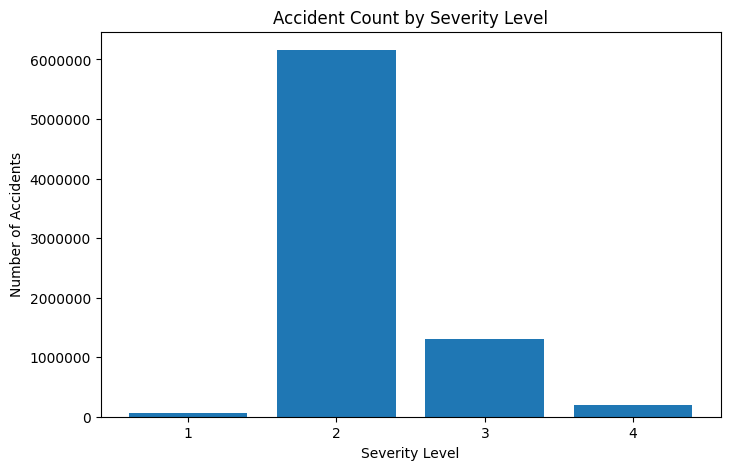

In [61]:
# Visualize accident count by severity level

plt.figure(figsize=(8, 5))

severity_counts = df_clean["Severity"].value_counts().sort_index()

plt.bar(severity_counts.index.astype(str), severity_counts.values)

plt.title("Accident Count by Severity Level")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)

plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [62]:
# Severe vs non-severe accident summary

severe_eda_summary = pd.DataFrame({
    "count": df_clean["Severe_Accident"].value_counts().sort_index(),
    "percent": (df_clean["Severe_Accident"].value_counts(normalize=True).sort_index() * 100).round(2)
})

severe_eda_summary.index = ["Non-Severe (Severity 1-2)", "Severe (Severity 3-4)"]

severe_eda_summary

,count,percent
Non-Severe (Severity 1-2),6224347,80.54
Severe (Severity 3-4),1504047,19.46


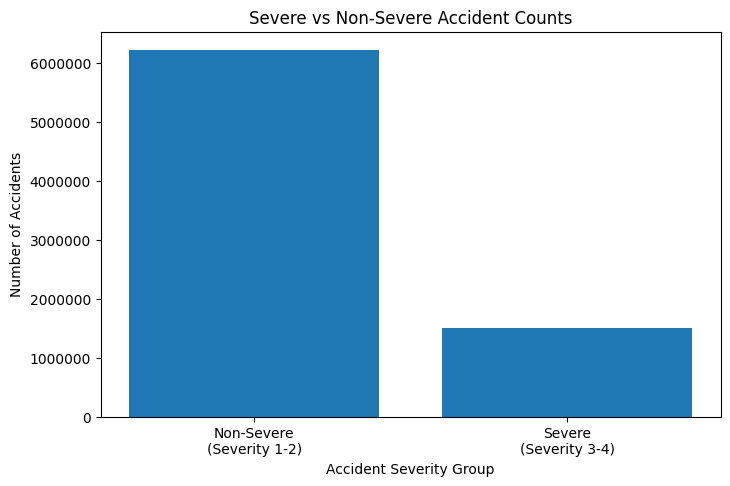

In [63]:
# Visualize severe vs non-severe accidents

plt.figure(figsize=(8, 5))

severe_counts = df_clean["Severe_Accident"].value_counts().sort_index()
severe_labels = ["Non-Severe\n(Severity 1-2)", "Severe\n(Severity 3-4)"]

plt.bar(severe_labels, severe_counts.values)

plt.title("Severe vs Non-Severe Accident Counts")
plt.xlabel("Accident Severity Group")
plt.ylabel("Number of Accidents")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

### Overall Severity Distribution Interpretation

The severity distribution shows that the dataset is heavily concentrated in Severity 2 accidents. Severity 2 accounts for the largest share of recorded accidents, while Severity 1 and Severity 4 are much less common. This imbalance is clearly visible in the accident-count chart, where the Severity 2 bar is substantially larger than the other severity levels.

The binary severity grouping provides a clearer way to compare more serious accidents against less serious accidents. Using this grouping, 6,224,347 records, or 80.54% of the dataset, are classified as non-severe accidents. The remaining 1,504,047 records, or 19.46%, are classified as severe accidents.

This finding is important for the rest of the analysis because raw accident counts will mostly reflect the dominant non-severe group. To better understand safety concerns, later EDA sections will compare the severe-accident rate across time periods, weather conditions, lighting conditions, roadway features, and geographic locations.

A key takeaway from this section is that severe accidents make up a smaller but still substantial portion of the dataset. Because nearly one in five recorded accidents is classified as severe, the `Severe_Accident` feature will be useful for identifying conditions associated with higher accident seriousness.

### **2C Accident Frequency Over Time**

This section examines how recorded accident counts vary over time. The analysis begins with yearly and monthly accident counts to identify broad trends across the 2016–2023 dataset period.

In [64]:
# Accident counts by year

accidents_by_year = df_clean.groupby("Year").size().reset_index(name="Accident_Count")

accidents_by_year

,Year,Accident_Count
0,2016,410821
1,2017,718093
2,2018,893426
3,2019,954303
4,2020,1178913
5,2021,1563753
6,2022,1762452
7,2023,246633


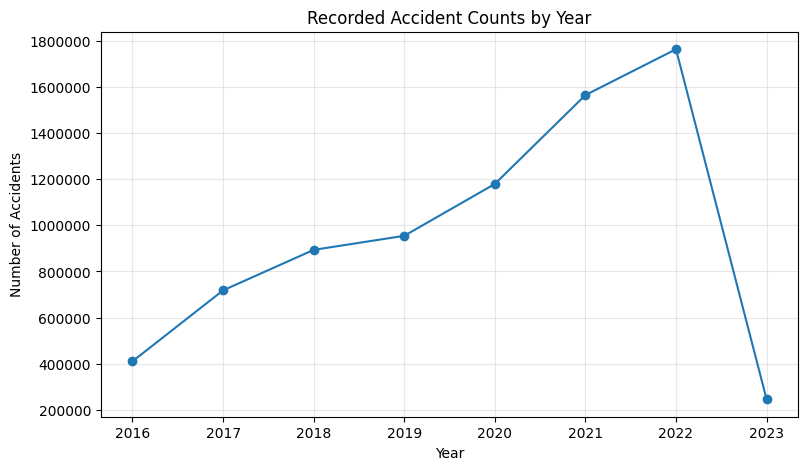

In [65]:
# Visualize accident counts by year

plt.figure(figsize=(9, 5))

plt.plot(accidents_by_year["Year"], accidents_by_year["Accident_Count"], marker="o")

plt.title("Recorded Accident Counts by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")

plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, alpha=0.3)

plt.show()

In [66]:
# Accident counts by month across all years

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

accidents_by_month = (
    df_clean.groupby(["Month", "Month_Name"])
    .size()
    .reset_index(name="Accident_Count")
    .sort_values("Month")
)

accidents_by_month

,Month,Month_Name,Accident_Count
0,1,January,751946
1,2,February,658984
2,3,March,554595
3,4,April,587300
4,5,May,558176
5,6,June,571373
6,7,July,512335
7,8,August,599666
8,9,September,651381
9,10,October,675130


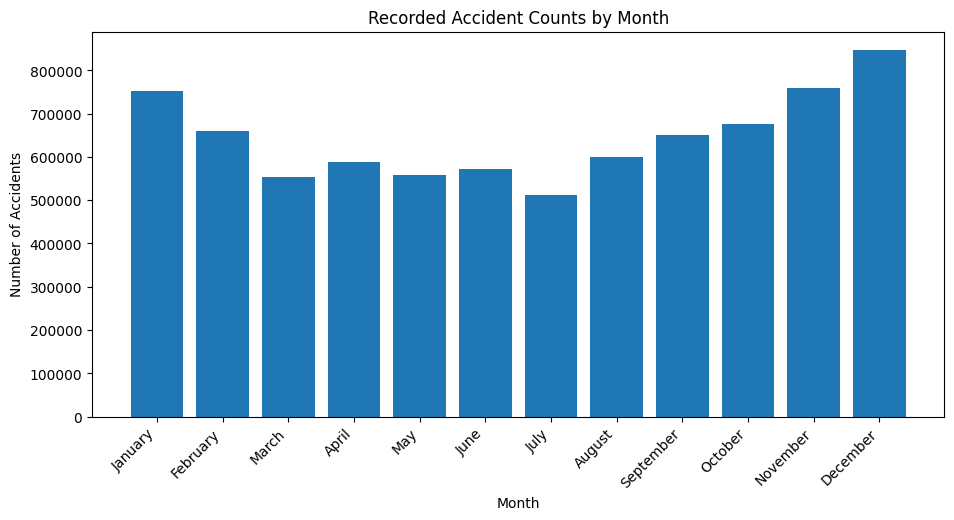

In [67]:
# Visualize accident counts by month

plt.figure(figsize=(11, 5))

plt.bar(accidents_by_month["Month_Name"], accidents_by_month["Accident_Count"])

plt.title("Recorded Accident Counts by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [68]:
# Accident counts by year and month

monthly_trend = (
    df_clean.groupby(["Year", "Month"])
    .size()
    .reset_index(name="Accident_Count")
)

monthly_trend["Year_Month"] = pd.to_datetime(
    monthly_trend["Year"].astype(str) + "-" + monthly_trend["Month"].astype(str) + "-01"
)

monthly_trend = monthly_trend.sort_values("Year_Month")

monthly_trend.head()

,Year,Month,Accident_Count,Year_Month
0,2016,1,7,2016-01-01
1,2016,2,985,2016-02-01
2,2016,3,6330,2016-03-01
3,2016,4,18088,2016-04-01
4,2016,5,17610,2016-05-01


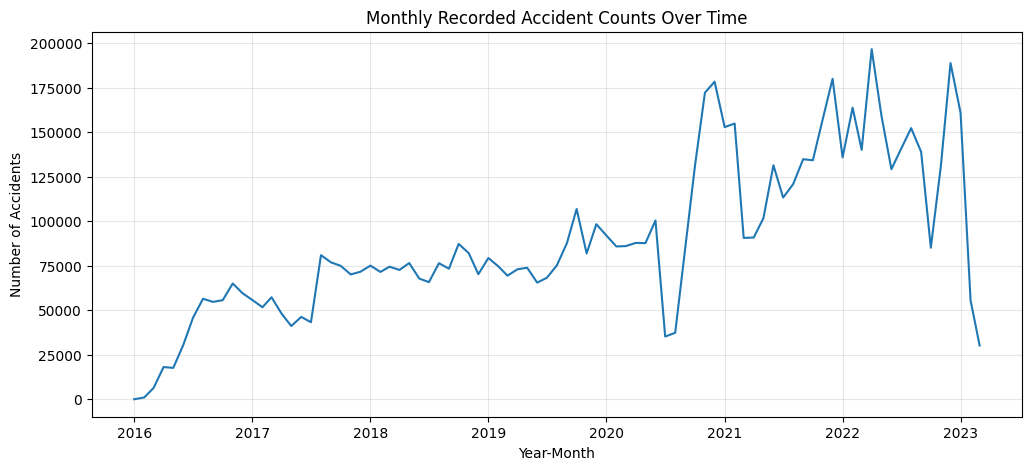

In [69]:
# Visualize monthly accident trend over time

plt.figure(figsize=(12, 5))

plt.plot(monthly_trend["Year_Month"], monthly_trend["Accident_Count"])

plt.title("Monthly Recorded Accident Counts Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Number of Accidents")

plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, alpha=0.3)

plt.show()

### Accident Frequency Over Time Interpretation

Recorded accident counts increased substantially from 2016 through 2022. The dataset contains 410,821 records in 2016, increasing to 1,762,452 records in 2022. This upward trend is visible in the yearly line chart, which shows steady growth across most years, with especially large increases after 2019.

The 2023 count is much lower at 246,633 records because the dataset only includes records through March 31, 2023. Therefore, the 2023 total should not be interpreted as a full-year decline. Similarly, early 2016 monthly counts are very low, suggesting that the beginning of the dataset may not represent a complete year of reporting coverage.

Monthly accident counts across all years show that December has the highest number of recorded accidents, followed by November and January. July has the lowest recorded accident count. This pattern suggests that late fall and winter months may be associated with higher accident frequency, although raw counts should be interpreted cautiously because they do not account for traffic volume, weather exposure, population, or changes in reporting coverage.

The monthly trend over time shows both long-term growth and noticeable month-to-month variation. There is a clear decline around early 2020, which is consistent with the timing of COVID-19-related travel reductions and stay-at-home restrictions. However, this dataset does not include traffic volume, vehicle miles traveled, or mobility data, so the decline should be interpreted as a change in recorded accident counts rather than direct evidence of reduced accident risk. Later increases may reflect a combination of resumed travel activity, reporting coverage, seasonal conditions, and broader changes in commuting behavior.

The monthly accident trend shows substantial variation over time, including a noticeable decline around early 2020 and inconsistent increases and decreases afterward. This pattern may partly reflect COVID-19-related travel reductions, stay-at-home restrictions, and the longer-term rise of remote or hybrid work arrangements. These changes likely altered traditional commuting patterns and may have contributed to less consistent month-to-month accident counts.

However, the pattern should be interpreted cautiously. The dataset contains recorded accident counts rather than direct measures of accident risk, traffic volume, or vehicle miles traveled. Changes in reporting coverage, seasonal weather conditions, holiday travel, and broader shifts in driving behavior may also contribute to the observed variation. Therefore, the trend should be described as a change in recorded accident frequency rather than definitive evidence of changing accident risk.

Overall, the time-based accident frequency analysis suggests that recorded accidents are not evenly distributed across years or months. Later EDA sections should examine whether accident severity rates also vary by time period, because high accident counts do not necessarily mean a higher proportion of severe accidents.

### **3C Accident Frequency by Day of Week and Hour of Day**

This section examines how recorded accident counts vary by day of week and hour of day. These patterns can help identify periods when transportation agencies may need additional monitoring, public warnings, enforcement, or emergency-response readiness.

In [70]:
# Accident counts by day of week

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

accidents_by_day = (
    df_clean["Day_of_Week"]
    .value_counts()
    .reindex(day_order)
    .reset_index()
)

accidents_by_day.columns = ["Day_of_Week", "Accident_Count"]

accidents_by_day

,Day_of_Week,Accident_Count
0,Monday,1210921
1,Tuesday,1290929
2,Wednesday,1312389
3,Thursday,1316229
4,Friday,1366499
5,Saturday,668683
6,Sunday,562744


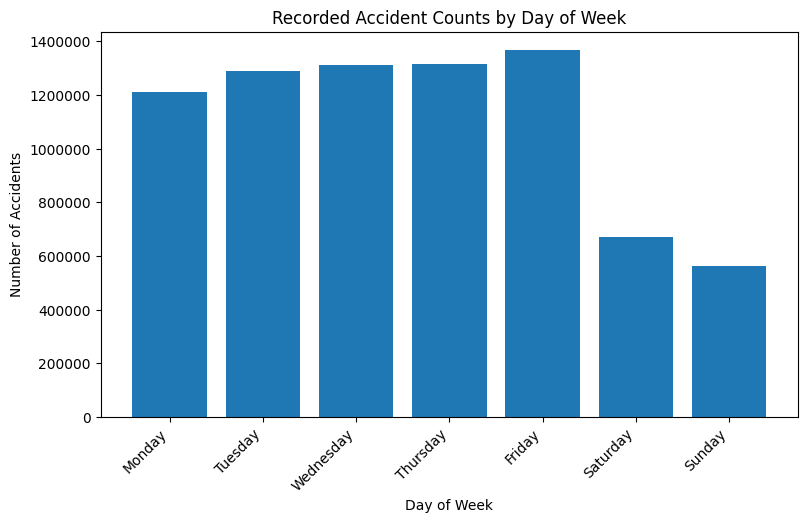

In [71]:
# Visualize accident counts by day of week

plt.figure(figsize=(9, 5))

plt.bar(accidents_by_day["Day_of_Week"], accidents_by_day["Accident_Count"])

plt.title("Recorded Accident Counts by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [72]:
# Accident counts by hour of day

accidents_by_hour = (
    df_clean.groupby("Hour")
    .size()
    .reset_index(name="Accident_Count")
    .sort_values("Hour")
)

accidents_by_hour

,Hour,Accident_Count
0,0,112378
1,1,97071
2,2,93227
3,3,83863
4,4,159852
5,5,228182
6,6,405837
7,7,587472
8,8,577576
9,9,363034


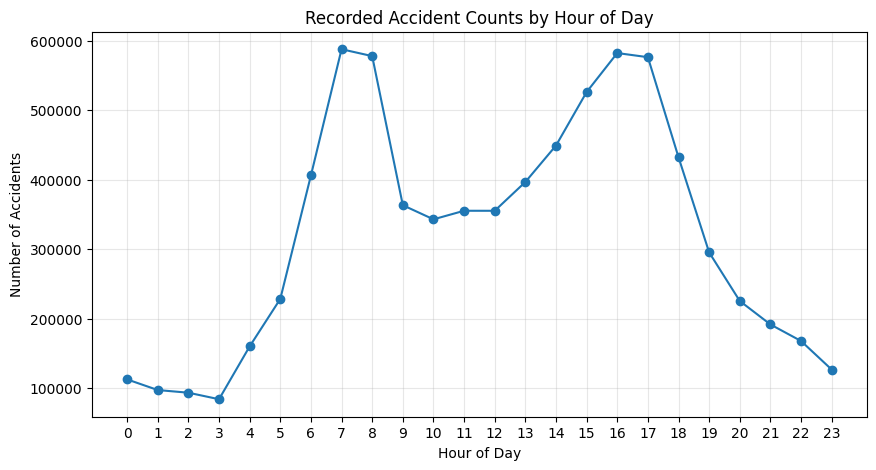

In [73]:
# Visualize accident counts by hour of day

plt.figure(figsize=(10, 5))

plt.plot(accidents_by_hour["Hour"], accidents_by_hour["Accident_Count"], marker="o")

plt.title("Recorded Accident Counts by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))

plt.ticklabel_format(style="plain", axis="y")
plt.grid(True, alpha=0.3)

plt.show()

In [74]:
# Accident counts by weekend status

weekend_summary = pd.DataFrame({
    "count": df_clean["Weekend"].value_counts().sort_index(),
    "percent": (df_clean["Weekend"].value_counts(normalize=True).sort_index() * 100).round(2)
})

weekend_summary.index = ["Weekday", "Weekend"]

weekend_summary

,count,percent
Weekday,6496967,84.07
Weekend,1231427,15.93


In [75]:
# Accident counts by rush-hour status

rush_hour_summary = pd.DataFrame({
    "count": df_clean["Rush_Hour"].value_counts().sort_index(),
    "percent": (df_clean["Rush_Hour"].value_counts(normalize=True).sort_index() * 100).round(2)
})

rush_hour_summary.index = ["Non-Rush Hour", "Rush Hour"]

rush_hour_summary

,count,percent
Non-Rush Hour,4945978,64.00
Rush Hour,2782416,36.00


### Accident Frequency by Day of Week and Hour of Day Interpretation

Recorded accidents are much more common on weekdays than weekends. Weekdays account for 6,496,967 accidents, or 84.07% of the dataset, while weekends account for 1,231,427 accidents, or 15.93%. This pattern is consistent with heavier weekday commuting, work travel, school travel, commercial activity, and general traffic volume.

Among individual days, Friday has the highest number of recorded accidents with 1,366,499 records. Thursday and Wednesday also have high counts, with 1,316,229 and 1,312,389 records respectively. Saturday and Sunday have substantially fewer recorded accidents than weekdays, with Sunday having the lowest count at 562,744 records.

The hourly accident pattern shows clear commuting-related peaks. Accident counts rise sharply in the morning, especially between 6 AM and 8 AM, with the highest morning counts occurring at 7 AM and 8 AM. Counts increase again during the afternoon and early evening commute period, especially from 3 PM through 5 PM. The highest hourly count occurs at 7 AM with 587,472 accidents, followed closely by 4 PM and 8 AM.

Rush-hour periods account for 2,782,416 accidents, or 36.00% of all recorded accidents, even though rush hour represents only a limited portion of the day. This suggests that commute periods are an important time window for DOT monitoring, congestion management, public alerts, enforcement, and emergency-response planning.

A notable pattern is that accident counts are lowest overnight, especially between midnight and 3 AM. However, lower accident frequency does not necessarily mean lower severity risk. Later analysis should compare severe-accident rates by hour and day of week to determine whether less frequent time periods, such as overnight hours or weekends, have a higher proportion of severe accidents.

### **4C Severe Accident Rate by Time Features**

This section compares the proportion of accidents classified as severe across different time periods. This helps distinguish between periods with high accident counts and periods where accidents are more likely to be severe.

In [76]:
# Severe accident rate by day of week

severity_by_day = (
    df_clean.groupby("Day_of_Week")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reindex(day_order)
    .reset_index()
)

severity_by_day["Severe_Rate_Percent"] = (severity_by_day["Severe_Rate"] * 100).round(2)

severity_by_day

,Day_of_Week,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,Monday,1210921,233688,0.19,19.30
1,Tuesday,1290929,245469,0.19,19.01
2,Wednesday,1312389,247629,0.19,18.87
3,Thursday,1316229,249714,0.19,18.97
4,Friday,1366499,261509,0.19,19.14
5,Saturday,668683,140368,0.21,20.99
6,Sunday,562744,125670,0.22,22.33


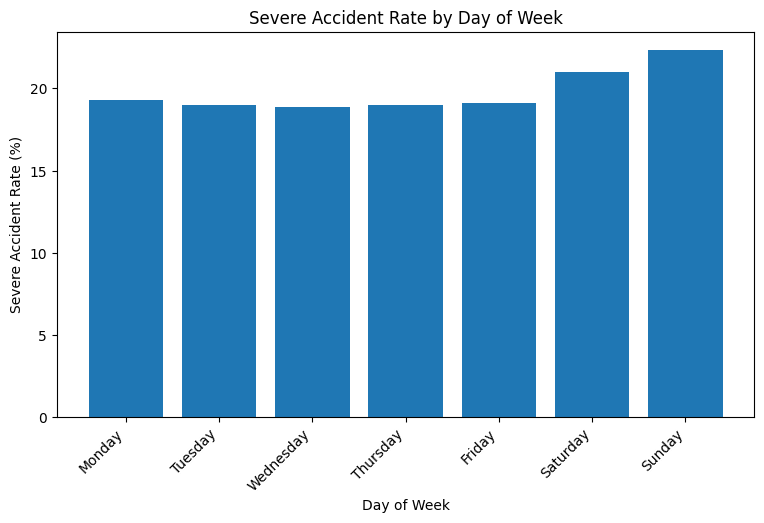

In [77]:
# Visualize severe accident rate by day of week

plt.figure(figsize=(9, 5))

plt.bar(severity_by_day["Day_of_Week"], severity_by_day["Severe_Rate_Percent"])

plt.title("Severe Accident Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [78]:
# Severe accident rate by hour of day

severity_by_hour = (
    df_clean.groupby("Hour")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
    .sort_values("Hour")
)

severity_by_hour["Severe_Rate_Percent"] = (severity_by_hour["Severe_Rate"] * 100).round(2)

severity_by_hour

,Hour,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,0,112378,17807,0.16,15.85
1,1,97071,13735,0.14,14.15
2,2,93227,14693,0.16,15.76
3,3,83863,14779,0.18,17.62
4,4,159852,34214,0.21,21.40
5,5,228182,45776,0.20,20.06
6,6,405837,81612,0.20,20.11
7,7,587472,110609,0.19,18.83
8,8,577576,109660,0.19,18.99
9,9,363034,75575,0.21,20.82


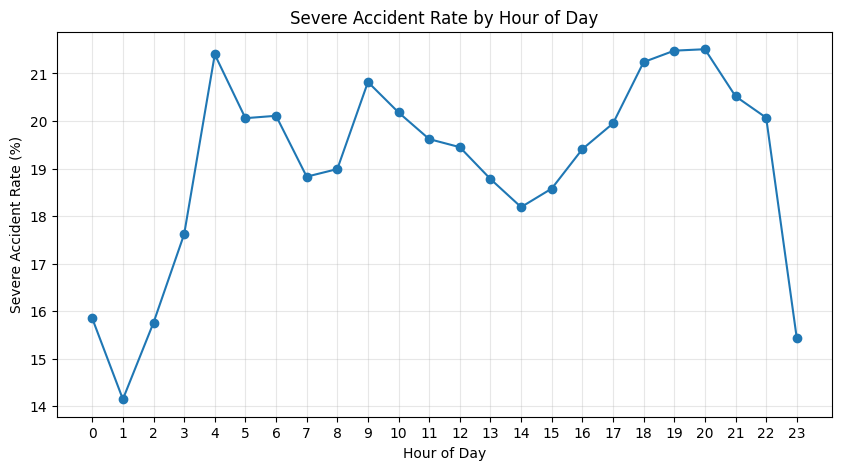

In [79]:
# Visualize severe accident rate by hour of day

plt.figure(figsize=(10, 5))

plt.plot(
    severity_by_hour["Hour"],
    severity_by_hour["Severe_Rate_Percent"],
    marker="o"
)

plt.title("Severe Accident Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(range(0, 24))

plt.grid(True, alpha=0.3)

plt.show()

In [80]:
# Severe accident rate by weekend status

severity_by_weekend = (
    df_clean.groupby("Weekend")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

severity_by_weekend["Weekend"] = severity_by_weekend["Weekend"].map({
    False: "Weekday",
    True: "Weekend"
})

severity_by_weekend["Severe_Rate_Percent"] = (severity_by_weekend["Severe_Rate"] * 100).round(2)

severity_by_weekend

,Weekend,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,Weekday,6496967,1238009,0.19,19.06
1,Weekend,1231427,266038,0.22,21.60


In [81]:
# Severe accident rate by rush-hour status

severity_by_rush_hour = (
    df_clean.groupby("Rush_Hour")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

severity_by_rush_hour["Rush_Hour"] = severity_by_rush_hour["Rush_Hour"].map({
    False: "Non-Rush Hour",
    True: "Rush Hour"
})

severity_by_rush_hour["Severe_Rate_Percent"] = (severity_by_rush_hour["Severe_Rate"] * 100).round(2)

severity_by_rush_hour

,Rush_Hour,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,Non-Rush Hour,4945978,966968,0.20,19.55
1,Rush Hour,2782416,537079,0.19,19.30


### Severe Accident Rate by Time Features Interpretation

The severe-accident rate varies by time period, and the pattern is different from the raw accident-count pattern. Weekdays have substantially more recorded accidents overall, but weekends have a higher proportion of severe accidents.

By day of week, Sunday has the highest severe-accident rate at 22.33%, followed by Saturday at 20.99%. Weekday severe-accident rates are lower and relatively consistent, ranging from 18.87% on Wednesday to 19.30% on Monday. This suggests that although fewer accidents are recorded on weekends, weekend accidents are more likely to be severe.

The hourly severe-accident rate also shows a different pattern than raw hourly accident counts. Accident counts are highest during commute periods, especially around 7 AM, 8 AM, 4 PM, and 5 PM. However, severe-accident rates are not highest during the busiest commute hours. Instead, higher severe-accident rates appear during early morning and evening periods, including 4 AM, 6 PM, 7 PM, and 8 PM. The highest hourly severe-accident rate occurs at 8 PM, with 21.51% of accidents classified as severe.

Rush-hour accidents make up a large share of total accident counts, but their severe-accident rate is slightly lower than non-rush-hour accidents. Rush-hour accidents have a severe-accident rate of 19.30%, while non-rush-hour accidents have a rate of 19.55%. This suggests that rush hour is important for accident volume, but not necessarily the period with the highest accident severity proportion.

Weekend accidents show a clearer severity difference. Weekday accidents have a severe-accident rate of 19.06%, while weekend accidents have a higher rate of 21.60%. This is a potentially important finding for DOT planning because weekends may require different safety strategies than weekdays, even though weekday accident counts are higher.

Overall, this section shows that high accident frequency and high accident severity rate do not always occur at the same times. Weekday commute periods have the highest accident volumes, while weekends and some lower-volume hours have higher severe-accident rates. This finding supports analyzing both accident counts and severe-accident rates when developing recommendations.

### **5C Weather Conditions and Accident Severity

This section examines how recorded accident frequency and severe-accident rates vary across grouped weather categories. This helps identify whether certain weather conditions are associated with a higher proportion of severe accidents.

In [82]:
# Accident count and severe accident rate by weather category

weather_severity_summary = (
    df_clean.groupby("Weather_Category")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

weather_severity_summary["Severe_Rate_Percent"] = (
    weather_severity_summary["Severe_Rate"] * 100
).round(2)

weather_severity_summary = weather_severity_summary.sort_values(
    by="Accident_Count",
    ascending=False
)

weather_severity_summary

,Weather_Category,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,Clear/Fair,3405216,575770,0.17,16.91
1,Cloudy,3163750,685039,0.22,21.65
4,Rain,538878,126175,0.23,23.41
2,Low Visibility,202399,32808,0.16,16.21
7,Unknown,173459,37724,0.22,21.75
5,Snow/Ice,161637,32432,0.20,20.06
6,Storm,65271,11872,0.18,18.19
3,Other,17025,2111,0.12,12.40
8,Windy,759,116,0.15,15.28


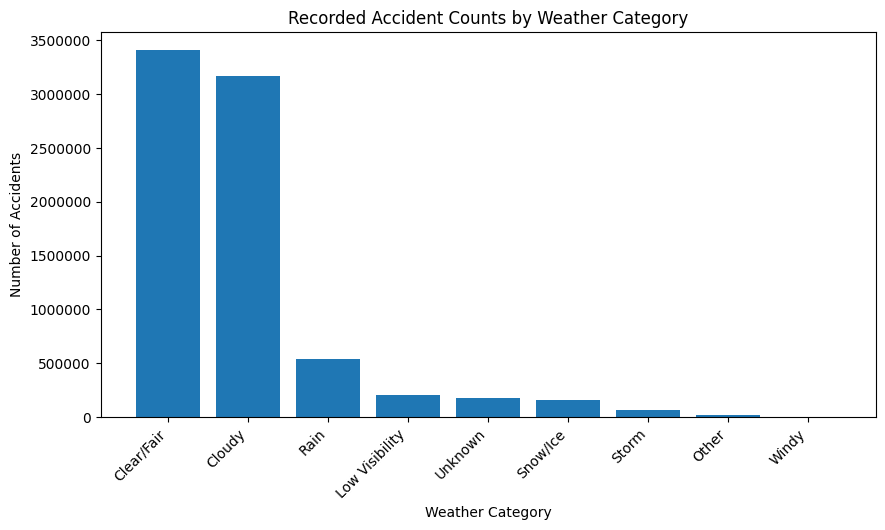

In [83]:
# Visualize accident counts by weather category

plt.figure(figsize=(10, 5))

plt.bar(
    weather_severity_summary["Weather_Category"],
    weather_severity_summary["Accident_Count"]
)

plt.title("Recorded Accident Counts by Weather Category")
plt.xlabel("Weather Category")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

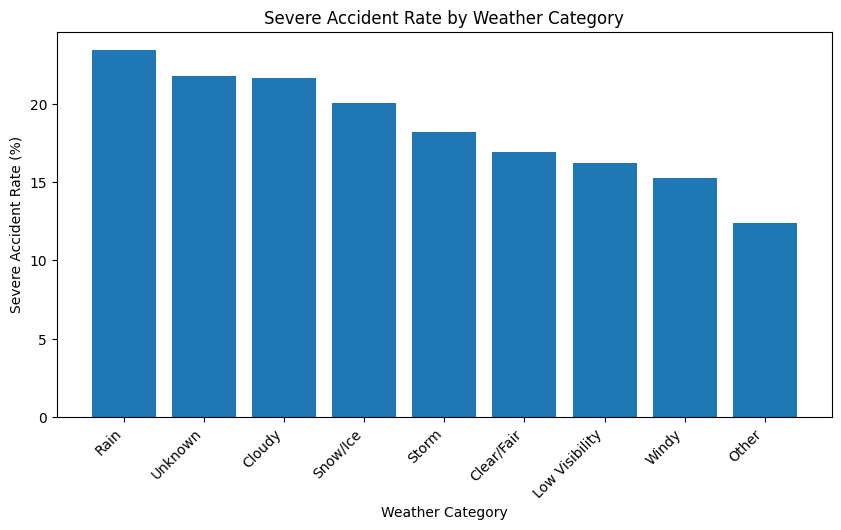

In [84]:
# Visualize severe accident rate by weather category

weather_severity_rate_sorted = weather_severity_summary.sort_values(
    by="Severe_Rate_Percent",
    ascending=False
)

plt.figure(figsize=(10, 5))

plt.bar(
    weather_severity_rate_sorted["Weather_Category"],
    weather_severity_rate_sorted["Severe_Rate_Percent"]
)

plt.title("Severe Accident Rate by Weather Category")
plt.xlabel("Weather Category")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [85]:
# Accident count and severe accident rate by precipitation presence

precipitation_severity_summary = (
    df_clean.groupby("Any_Precipitation")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

precipitation_severity_summary["Any_Precipitation"] = precipitation_severity_summary[
    "Any_Precipitation"
].map({
    0: "No Recorded Precipitation",
    1: "Recorded Precipitation"
})

precipitation_severity_summary["Severe_Rate_Percent"] = (
    precipitation_severity_summary["Severe_Rate"] * 100
).round(2)

precipitation_severity_summary

,Any_Precipitation,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,No Recorded Precipitation,7195304,1382002,0.19,19.21
1,Recorded Precipitation,533090,122045,0.23,22.89


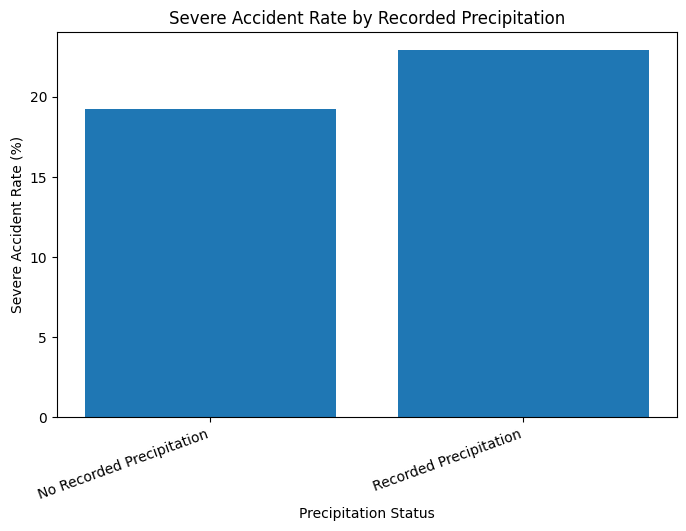

In [86]:
# Visualize severe accident rate by precipitation presence

plt.figure(figsize=(8, 5))

plt.bar(
    precipitation_severity_summary["Any_Precipitation"],
    precipitation_severity_summary["Severe_Rate_Percent"]
)

plt.title("Severe Accident Rate by Recorded Precipitation")
plt.xlabel("Precipitation Status")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(rotation=20, ha="right")

plt.show()

### Weather Conditions and Accident Severity Interpretation

Weather conditions show a clear difference between accident frequency and accident severity rate. Most recorded accidents occurred under `Clear/Fair` or `Cloudy` conditions. `Clear/Fair` conditions had the highest accident count with 3,405,216 records, followed closely by `Cloudy` conditions with 3,163,750 records. This suggests that most accidents occur during common weather conditions rather than only during severe or unusual weather.

However, the severe-accident rate shows a different pattern. `Rain` had the highest severe-accident rate among the major weather categories at 23.41%, even though it accounted for fewer total accidents than `Clear/Fair` or `Cloudy` conditions. `Unknown` weather conditions had a severe-accident rate of 21.75%, and `Cloudy` conditions had a severe-accident rate of 21.65%. `Snow/Ice` also had an elevated severe-accident rate of 20.06%.

By comparison, `Clear/Fair` conditions had a lower severe-accident rate of 16.91%. This is an important contrast because clear or fair weather produced the largest number of recorded accidents, but those accidents were less likely to be severe compared with rain or cloudy conditions.

The precipitation comparison supports this pattern. Accidents with no recorded precipitation had a severe-accident rate of 19.21%, while accidents with recorded precipitation had a higher severe-accident rate of 22.89%. Although precipitation-related accidents make up a smaller share of total records, they appear more likely to be severe.

This finding is relevant for DOT planning because it suggests that wet-weather conditions may be associated with increased accident seriousness, not just accident occurrence. Potential interventions could include weather-responsive speed warnings, improved drainage, pavement-friction improvements, variable-message signs, and targeted public safety messaging during rain events.

These results should still be interpreted cautiously because precipitation data contains missing values, and the dataset reflects recorded accident counts rather than direct measures of traffic exposure. Even so, the higher severe-accident rates during rain and recorded precipitation are notable patterns that should be considered in later statistical testing and recommendations.

## **Visibility and Accident Severity**

This section examines whether lower visibility conditions are associated with differences in accident frequency and severe-accident rate. Visibility is especially relevant for DOT planning because low-visibility conditions may affect driver reaction time, stopping distance, and roadway awareness.

In [87]:
# Create visibility categories

def categorize_visibility(visibility):
    if pd.isna(visibility):
        return "Unknown"
    elif visibility < 1:
        return "Very Low (<1 mile)"
    elif visibility < 3:
        return "Low (1-3 miles)"
    elif visibility < 10:
        return "Moderate (3-10 miles)"
    else:
        return "Clear (10+ miles)"

df_clean["Visibility_Category"] = df_clean["Visibility(mi)"].apply(categorize_visibility)

visibility_order = [
    "Very Low (<1 mile)",
    "Low (1-3 miles)",
    "Moderate (3-10 miles)",
    "Clear (10+ miles)",
    "Unknown"
]

visibility_severity_summary = (
    df_clean.groupby("Visibility_Category")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reindex(visibility_order)
    .reset_index()
)

visibility_severity_summary["Severe_Rate_Percent"] = (
    visibility_severity_summary["Severe_Rate"] * 100
).round(2)

visibility_severity_summary

,Visibility_Category,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,Very Low (<1 mile),117131,20596,0.18,17.58
1,Low (1-3 miles),269487,56344,0.21,20.91
2,Moderate (3-10 miles),1063602,218101,0.21,20.51
3,Clear (10+ miles),6100047,1170744,0.19,19.19
4,Unknown,178127,38262,0.21,21.48


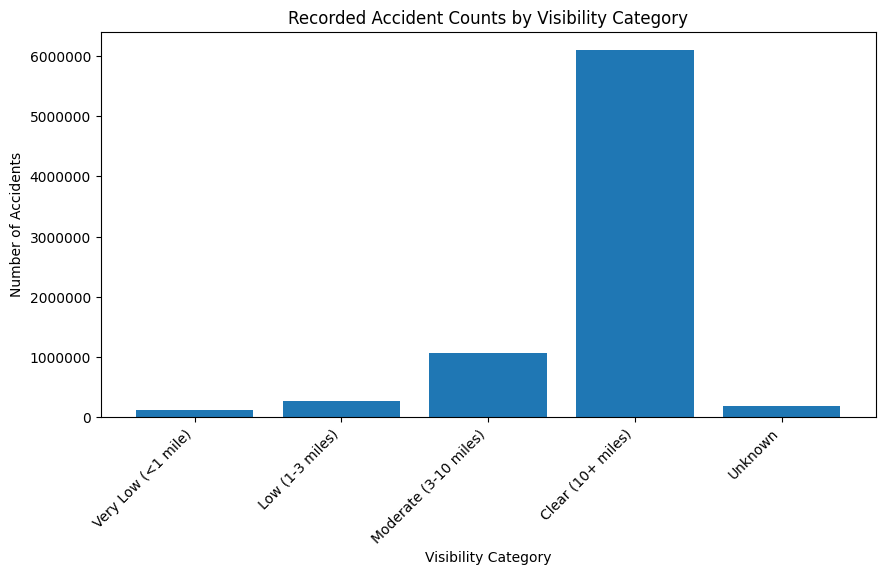

In [88]:
# Visualize accident counts by visibility category

plt.figure(figsize=(10, 5))

plt.bar(
    visibility_severity_summary["Visibility_Category"],
    visibility_severity_summary["Accident_Count"]
)

plt.title("Recorded Accident Counts by Visibility Category")
plt.xlabel("Visibility Category")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

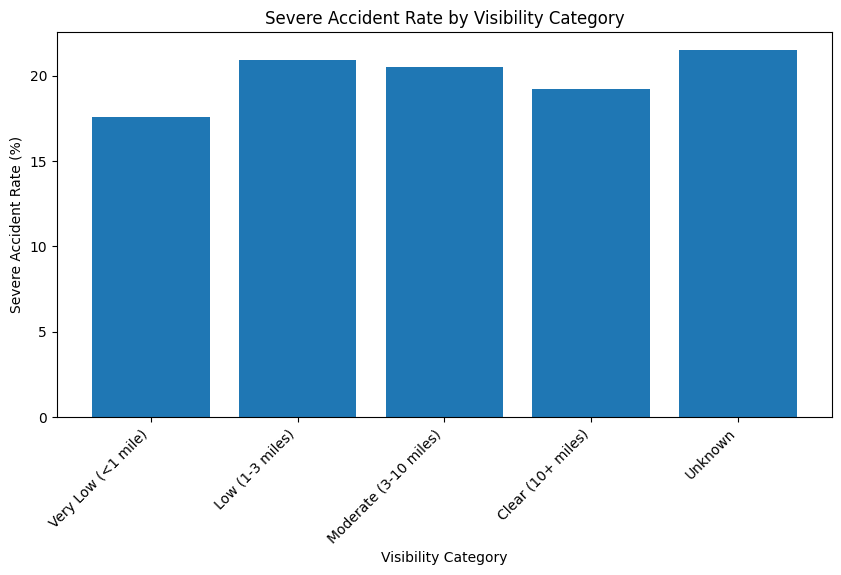

In [89]:
# Visualize severe accident rate by visibility category

plt.figure(figsize=(10, 5))

plt.bar(
    visibility_severity_summary["Visibility_Category"],
    visibility_severity_summary["Severe_Rate_Percent"]
)

plt.title("Severe Accident Rate by Visibility Category")
plt.xlabel("Visibility Category")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

### Visibility and Accident Severity Interpretation

Visibility conditions show that most recorded accidents occurred when visibility was clear. The `Clear (10+ miles)` category had 6,100,047 recorded accidents, which is much higher than the other visibility groups. This suggests that, as with weather categories, most accidents occur during common driving conditions rather than only during visibly hazardous conditions.

However, severe-accident rates vary across visibility categories. Accidents with `Clear (10+ miles)` visibility had a severe-accident rate of 19.19%. Accidents with `Low (1-3 miles)` visibility had a higher severe-accident rate of 20.91%, and accidents with `Moderate (3-10 miles)` visibility had a severe-accident rate of 20.51%. The `Unknown` visibility group had the highest severe-accident rate at 21.48%.

One somewhat surprising result is that the `Very Low (<1 mile)` category had a severe-accident rate of 17.58%, which is lower than the low, moderate, clear, and unknown categories. This may reflect differences in driving behavior during very low visibility, such as slower speeds, fewer trips, or more cautious driving. It may also reflect reporting patterns or the relatively smaller number of accidents in this category.

Overall, the visibility analysis suggests that reduced visibility conditions may be associated with somewhat higher severe-accident rates, especially in the low and moderate visibility categories. However, the pattern is not perfectly linear, so visibility should be interpreted alongside other environmental factors such as precipitation, weather category, lighting conditions, and time of day.

### **7C Lighting Conditions and Accident Severity**

This section examines how accident frequency and severe-accident rates vary by lighting condition. Lighting is relevant to DOT decision-making because nighttime and twilight conditions may affect driver visibility, reaction time, and roadway awareness.

In [90]:
# Accident count and severe accident rate by sunrise/sunset lighting condition

lighting_severity_summary = (
    df_clean.groupby("Sunrise_Sunset")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

lighting_severity_summary["Severe_Rate_Percent"] = (
    lighting_severity_summary["Severe_Rate"] * 100
).round(2)

lighting_severity_summary = lighting_severity_summary.sort_values(
    by="Accident_Count",
    ascending=False
)

lighting_severity_summary

,Sunrise_Sunset,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,Day,5334553,1052558,0.20,19.73
1,Night,2370595,448526,0.19,18.92
2,Unknown,23246,2963,0.13,12.75


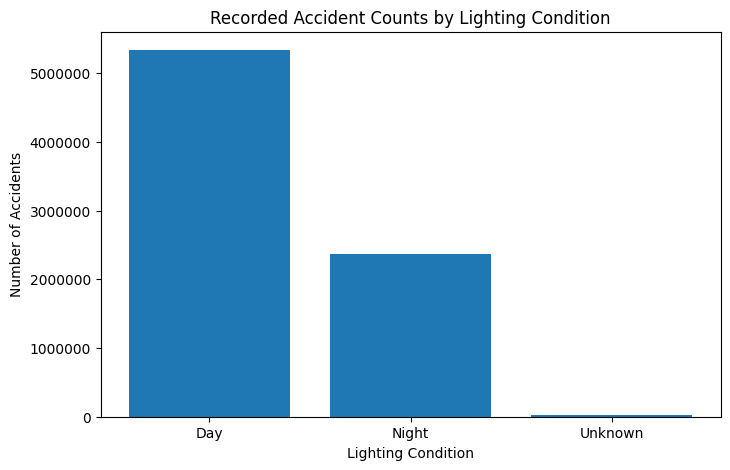

In [91]:
# Visualize accident counts by lighting condition

plt.figure(figsize=(8, 5))

plt.bar(
    lighting_severity_summary["Sunrise_Sunset"],
    lighting_severity_summary["Accident_Count"]
)

plt.title("Recorded Accident Counts by Lighting Condition")
plt.xlabel("Lighting Condition")
plt.ylabel("Number of Accidents")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

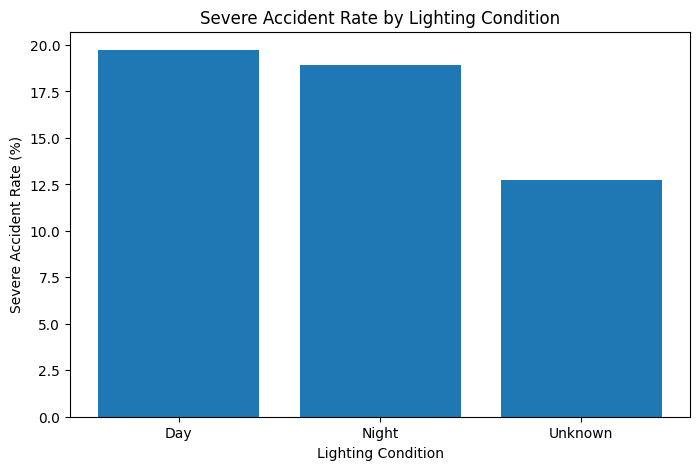

In [92]:
# Visualize severe accident rate by lighting condition

lighting_severity_rate_sorted = lighting_severity_summary.sort_values(
    by="Severe_Rate_Percent",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    lighting_severity_rate_sorted["Sunrise_Sunset"],
    lighting_severity_rate_sorted["Severe_Rate_Percent"]
)

plt.title("Severe Accident Rate by Lighting Condition")
plt.xlabel("Lighting Condition")
plt.ylabel("Severe Accident Rate (%)")

plt.show()

In [93]:
# Severe accident rate by civil twilight condition

civil_twilight_summary = (
    df_clean.groupby("Civil_Twilight")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

civil_twilight_summary["Severe_Rate_Percent"] = (
    civil_twilight_summary["Severe_Rate"] * 100
).round(2)

civil_twilight_summary = civil_twilight_summary.sort_values(
    by="Accident_Count",
    ascending=False
)

civil_twilight_summary

,Civil_Twilight,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,Day,5695619,1124169,0.20,19.74
1,Night,2009529,376915,0.19,18.76
2,Unknown,23246,2963,0.13,12.75


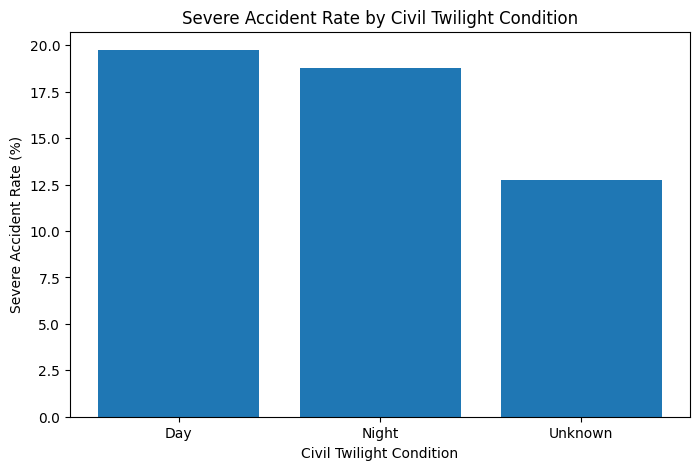

In [94]:
# Visualize severe accident rate by civil twilight condition

civil_twilight_rate_sorted = civil_twilight_summary.sort_values(
    by="Severe_Rate_Percent",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    civil_twilight_rate_sorted["Civil_Twilight"],
    civil_twilight_rate_sorted["Severe_Rate_Percent"]
)

plt.title("Severe Accident Rate by Civil Twilight Condition")
plt.xlabel("Civil Twilight Condition")
plt.ylabel("Severe Accident Rate (%)")

plt.show()

### Lighting Conditions and Accident Severity Interpretation

Lighting conditions show that most recorded accidents occurred during daylight conditions. Using the `Sunrise_Sunset` field, daytime accidents accounted for 5,334,553 records, while nighttime accidents accounted for 2,370,595 records. This pattern is likely influenced by higher daytime traffic volume, commuting activity, business travel, school travel, and general roadway use.

The severe-accident rate was slightly higher during the day than at night. Daytime accidents had a severe-accident rate of 19.73%, compared with 18.92% for nighttime accidents. This is somewhat counterintuitive because nighttime driving is often associated with reduced visibility and potentially higher risk. However, this dataset measures recorded accident counts and severity classifications, not exposure-adjusted accident risk.

The civil twilight comparison shows a very similar pattern. Accidents occurring during civil daylight conditions had a severe-accident rate of 19.74%, while accidents during civil nighttime conditions had a severe-accident rate of 18.76%. Records with unknown lighting conditions had lower severe-accident rates, but this group is much smaller and should be interpreted cautiously.

These findings suggest that, in this dataset, lighting condition alone does not show higher severe-accident rates at night. One possible explanation is that daytime periods include heavier traffic volumes, more congestion, more interactions at intersections, and more commuting-related exposure. Another possibility is that nighttime accidents may be underrepresented or influenced by differences in reporting patterns.

Overall, lighting conditions should not be interpreted in isolation. Later analysis may need to consider interactions between lighting, hour of day, roadway features, weather, and geography. Although nighttime conditions remain important for roadway-safety planning, this dataset does not show a simple pattern of nighttime accidents being more severe than daytime accidents.

### **8C Roadway Features and Accident Severity**

This section examines whether roadway-context features are associated with differences in accident frequency and severe-accident rate. These features are important for DOT planning because they may identify roadway environments that warrant engineering review, signage improvements, signal changes, lighting upgrades, or other infrastructure interventions.

In [95]:
# Accident count and severe accident rate by roadway feature count

roadway_count_severity_summary = (
    df_clean.groupby("Roadway_Feature_Count")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

roadway_count_severity_summary["Severe_Rate_Percent"] = (
    roadway_count_severity_summary["Severe_Rate"] * 100
).round(2)

roadway_count_severity_summary

,Roadway_Feature_Count,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
0,0,5427044,1201195,0.22,22.13
1,1,1543182,242680,0.16,15.73
2,2,609259,48088,0.08,7.89
3,3,124709,9974,0.08,8.00
4,4,21086,1872,0.09,8.88
5,5,2907,230,0.08,7.91
6,6,205,8,0.04,3.90
7,7,2,0,0.00,0.00


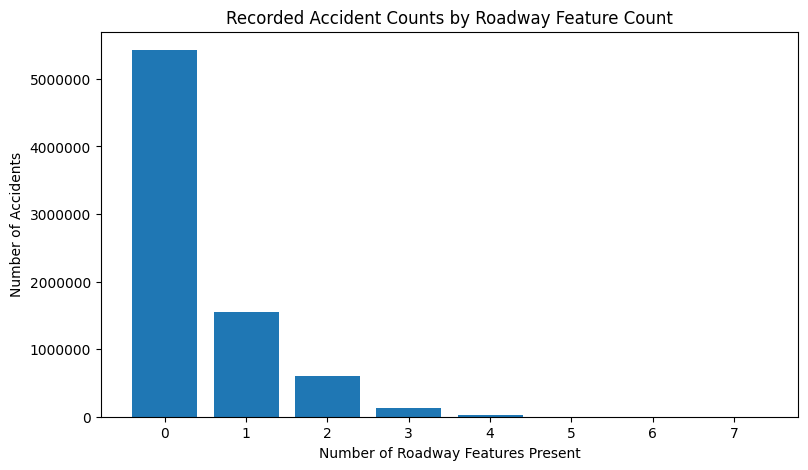

In [96]:
# Visualize accident counts by roadway feature count

plt.figure(figsize=(9, 5))

plt.bar(
    roadway_count_severity_summary["Roadway_Feature_Count"].astype(str),
    roadway_count_severity_summary["Accident_Count"]
)

plt.title("Recorded Accident Counts by Roadway Feature Count")
plt.xlabel("Number of Roadway Features Present")
plt.ylabel("Number of Accidents")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

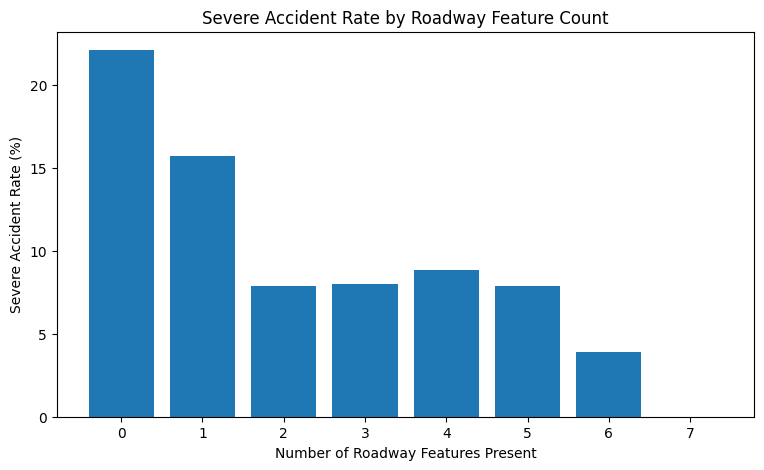

In [97]:
# Visualize severe accident rate by roadway feature count

plt.figure(figsize=(9, 5))

plt.bar(
    roadway_count_severity_summary["Roadway_Feature_Count"].astype(str),
    roadway_count_severity_summary["Severe_Rate_Percent"]
)

plt.title("Severe Accident Rate by Roadway Feature Count")
plt.xlabel("Number of Roadway Features Present")
plt.ylabel("Severe Accident Rate (%)")

plt.show()

In [98]:
# Accident count and severe accident rate by individual roadway feature

roadway_feature_results = []

for col in roadway_columns:
    feature_summary = (
        df_clean.groupby(col)
        .agg(
            Accident_Count=("ID", "count"),
            Severe_Count=("Severe_Accident", "sum"),
            Severe_Rate=("Severe_Accident", "mean")
        )
        .reset_index()
    )
    
    # Keep only rows where the feature is present
    feature_present = feature_summary[feature_summary[col] == True].copy()
    feature_present["Roadway_Feature"] = col
    
    roadway_feature_results.append(feature_present)

roadway_feature_severity_summary = pd.concat(
    roadway_feature_results,
    ignore_index=True
)

roadway_feature_severity_summary["Severe_Rate_Percent"] = (
    roadway_feature_severity_summary["Severe_Rate"] * 100
).round(2)

roadway_feature_severity_summary = roadway_feature_severity_summary[
    [
        "Roadway_Feature",
        "Accident_Count",
        "Severe_Count",
        "Severe_Rate",
        "Severe_Rate_Percent"
    ]
].sort_values(by="Accident_Count", ascending=False)

roadway_feature_severity_summary

,Roadway_Feature,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
11,Traffic_Signal,1143772,108759,0.10,9.51
2,Crossing,873763,61526,0.07,7.04
4,Junction,571342,153076,0.27,26.79
9,Stop,214371,13338,0.06,6.22
8,Station,201901,15156,0.08,7.51
0,Amenity,96334,6063,0.06,6.29
6,Railway,66979,10134,0.15,15.13
3,Give_Way,36582,5910,0.16,16.16
5,No_Exit,19545,2204,0.11,11.28
10,Traffic_Calming,7598,951,0.13,12.52


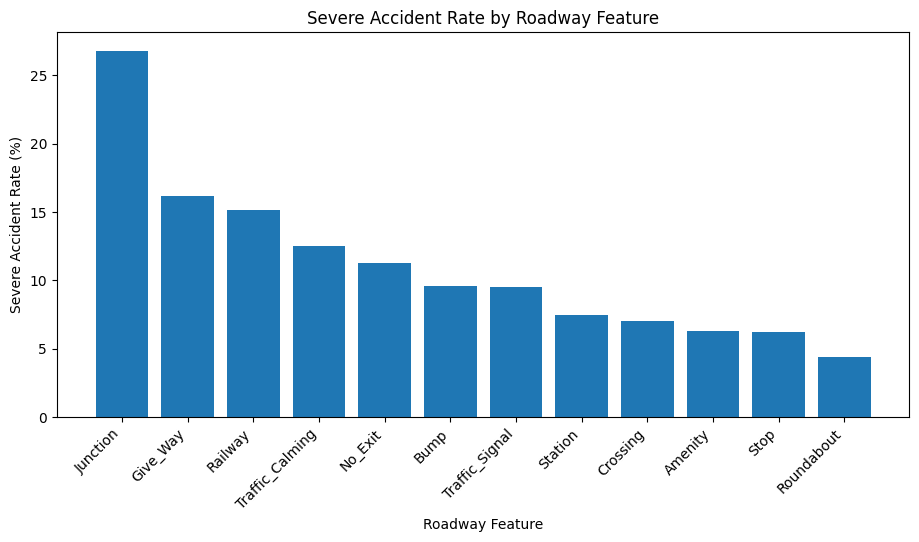

In [99]:
# Visualize severe accident rate by individual roadway feature

roadway_feature_rate_sorted = roadway_feature_severity_summary.sort_values(
    by="Severe_Rate_Percent",
    ascending=False
)

plt.figure(figsize=(11, 5))

plt.bar(
    roadway_feature_rate_sorted["Roadway_Feature"],
    roadway_feature_rate_sorted["Severe_Rate_Percent"]
)

plt.title("Severe Accident Rate by Roadway Feature")
plt.xlabel("Roadway Feature")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

### Roadway Features and Accident Severity Interpretation

Roadway-feature patterns show a major difference between accident frequency and severe-accident rate. Most recorded accidents occurred where none of the selected roadway features were marked as present. Records with `Roadway_Feature_Count` equal to 0 accounted for 5,427,044 accidents and had a severe-accident rate of 22.13%.

As the number of marked roadway features increased, the severe-accident rate generally decreased. Records with one roadway feature had a severe-accident rate of 15.73%, while records with two or more features generally had severe-accident rates below 9%. This pattern may suggest that areas with more recorded roadway features, such as signals, crossings, stops, or nearby amenities, are often lower-speed or more controlled environments. In contrast, records with no marked roadway features may include roadway segments where crashes occur at higher speeds or away from controlled intersections.

Among individual roadway features, `Traffic_Signal` was the most common feature, appearing in 1,143,772 accident records. However, accidents near traffic signals had a relatively low severe-accident rate of 9.51%. `Crossing`, `Stop`, `Station`, and `Amenity` also had relatively low severe-accident rates.

The most notable individual feature was `Junction`. Accidents marked with `Junction` had a severe-accident rate of 26.79%, which was much higher than most other roadway features and higher than the overall severe-accident rate. This suggests that junction-related environments may be especially important for infrastructure review and safety planning.

Other features with elevated severe-accident rates included `Give_Way` at 16.16%, `Railway` at 15.13%, `Traffic_Calming` at 12.52%, and `No_Exit` at 11.28%. However, some of these categories have much smaller accident counts than traffic signals, crossings, or junctions, so they should be interpreted with more caution.

Overall, this section suggests that roadway context matters for accident severity. The high severe-accident rate for junction-related accidents stands out as a potential infrastructure-focused finding. This may support recommendations related to junction design reviews, improved signage, signal timing evaluation, lighting improvements, speed management, or targeted safety audits at high-severity junction locations.

### **9C Geographic Patterns by State**

This section examines how recorded accident frequency and severe-accident rates vary by state. Geographic patterns can help identify where accident records are concentrated and where severe accidents make up a higher share of recorded incidents.

In [100]:
# Accident count and severe accident rate by state

state_severity_summary = (
    df_clean.groupby("State")
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

state_severity_summary["Severe_Rate_Percent"] = (
    state_severity_summary["Severe_Rate"] * 100
).round(2)

state_severity_summary = state_severity_summary.sort_values(
    by="Accident_Count",
    ascending=False
)

state_severity_summary.head(15)

,State,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
3,CA,1741433,285316,0.16,16.38
8,FL,880192,117214,0.13,13.32
41,TX,582837,127652,0.22,21.90
38,SC,382557,45565,0.12,11.91
32,NY,347960,80811,0.23,23.22
25,NC,338199,39994,0.12,11.83
43,VA,303301,69526,0.23,22.92
36,PA,296620,46898,0.16,15.81
21,MN,192084,30747,0.16,16.01
35,OR,179660,15624,0.09,8.70


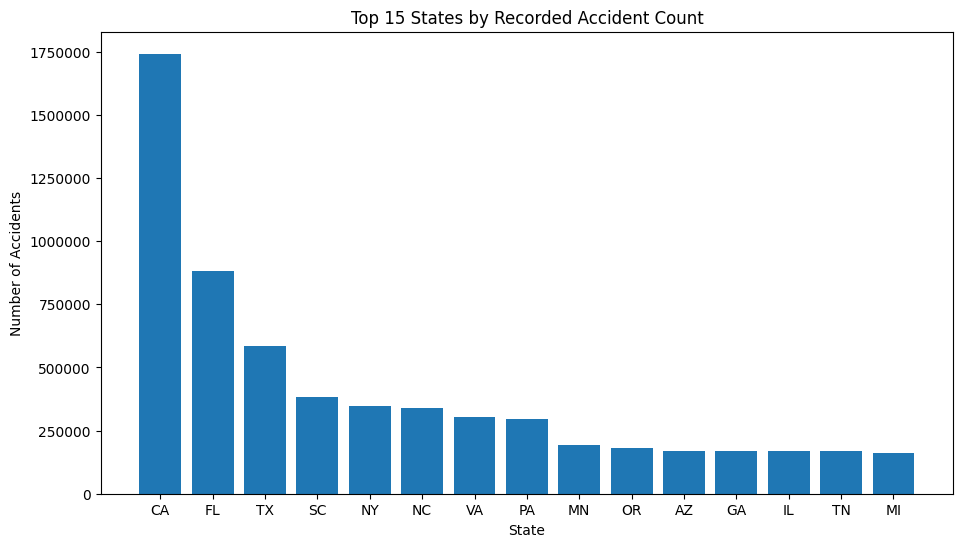

In [101]:
# Visualize top 15 states by accident count

top_states_by_count = state_severity_summary.head(15)

plt.figure(figsize=(11, 6))

plt.bar(
    top_states_by_count["State"],
    top_states_by_count["Accident_Count"]
)

plt.title("Top 15 States by Recorded Accident Count")
plt.xlabel("State")
plt.ylabel("Number of Accidents")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [102]:
# Top states by severe accident rate, limited to states with at least 10,000 accident records

state_severity_rate_filtered = state_severity_summary[
    state_severity_summary["Accident_Count"] >= 10000
].sort_values(
    by="Severe_Rate_Percent",
    ascending=False
)

state_severity_rate_filtered.head(15)

,State,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
37,RI,16971,7847,0.46,46.24
9,GA,169234,74021,0.44,43.74
15,KY,32254,13708,0.43,42.50
46,WI,34688,13068,0.38,37.67
4,CO,90885,33810,0.37,37.20
12,IL,168958,62065,0.37,36.73
22,MO,77323,28287,0.37,36.58
10,IA,26307,9023,0.34,34.30
30,NM,10325,3422,0.33,33.14
13,IN,67224,21482,0.32,31.96


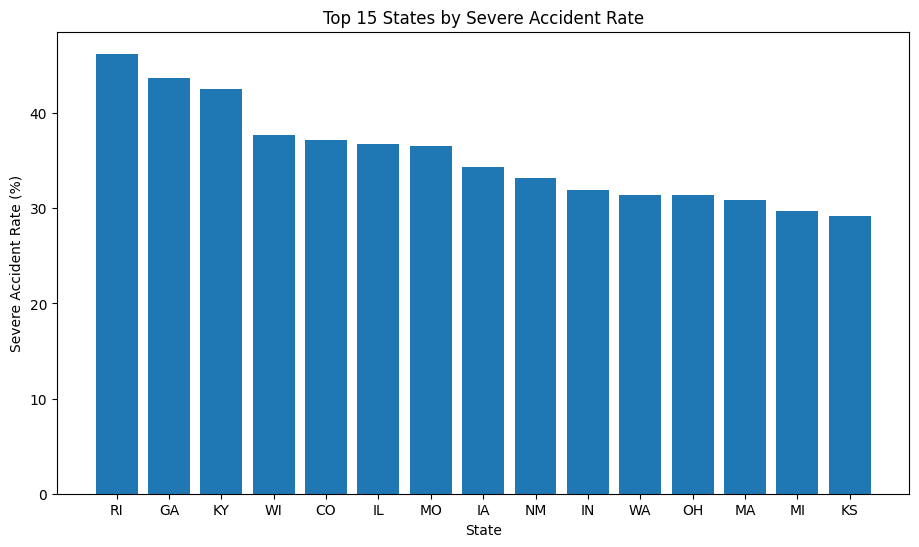

In [103]:
# Visualize top 15 states by severe accident rate

top_states_by_severe_rate = state_severity_rate_filtered.head(15)

plt.figure(figsize=(11, 6))

plt.bar(
    top_states_by_severe_rate["State"],
    top_states_by_severe_rate["Severe_Rate_Percent"]
)

plt.title("Top 15 States by Severe Accident Rate")
plt.xlabel("State")
plt.ylabel("Severe Accident Rate (%)")

plt.show()

In [104]:
# Review South Carolina accident count and severe accident rate

state_severity_summary[state_severity_summary["State"] == "SC"]

,State,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
38,SC,382557,45565,0.12,11.91


### Geographic Patterns by State Interpretation

State-level accident patterns show that recorded accident counts are heavily concentrated in a relatively small number of states. California had the highest number of recorded accidents with 1,741,433 records, followed by Florida with 880,192, Texas with 582,837, South Carolina with 382,557, and New York with 347,960. These raw counts help identify where accident records are most concentrated, but they should not be interpreted as direct measures of accident risk because the dataset does not account for population, traffic volume, vehicle miles traveled, or differences in reporting coverage.

The severe-accident rate by state shows a different pattern from raw accident counts. Some states with high accident counts had relatively low severe-accident rates. For example, Florida had 880,192 recorded accidents but a severe-accident rate of 13.32%, and South Carolina had 382,557 recorded accidents but a severe-accident rate of 11.91%. California had the highest total accident count but a severe-accident rate of 16.38%, which is below the overall severe-accident share of 19.46%.

By contrast, several states had much higher severe-accident rates despite having fewer total records than the largest accident-count states. Rhode Island had the highest severe-accident rate among states with at least 10,000 records at 46.24%. Georgia followed closely at 43.74%, and Kentucky had a severe-accident rate of 42.50%. Illinois, Colorado, Wisconsin, Missouri, and Iowa also showed elevated severe-accident rates.

This contrast is important for DOT decision-making because it shows that states with the most recorded accidents are not always the states with the highest proportion of severe accidents. High-count states may require broad accident-reduction strategies, while high-severity-rate states may warrant targeted investigation into roadway design, speed environments, reporting practices, rural-versus-urban patterns, or other contributing factors.

South Carolina is notable because it ranks fourth in total recorded accidents but has a relatively low severe-accident rate of 11.91%. This suggests that South Carolina contributes a large number of recorded accident events in the dataset, but a smaller share of those records are classified as severe compared with many other states.

Overall, the state-level analysis suggests that geographic prioritization should consider both accident volume and severe-accident rate. Raw accident counts can help identify where incidents are concentrated, while severe-accident rates help identify where recorded accidents are more likely to be serious.

### **10C Geographic Patterns by City or County**

### Geographic Patterns by City and County

This section examines recorded accident frequency and severe-accident rates at the city and county levels. City and county summaries provide more local context than state-level analysis and can help identify areas that may warrant closer review in the Tableau dashboard or later recommendations.

In [105]:
# Accident count and severe accident rate by city

city_severity_summary = (
    df_clean.groupby(["State", "City"])
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

city_severity_summary["Severe_Rate_Percent"] = (
    city_severity_summary["Severe_Rate"] * 100
).round(2)

city_severity_summary = city_severity_summary.sort_values(
    by="Accident_Count",
    ascending=False
)

city_severity_summary.head(15)

,State,City,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
3300,FL,Miami,186768,16814,0.09,9.00
17483,TX,Houston,169428,30498,0.18,18.00
1689,CA,Los Angeles,156491,35866,0.23,22.92
10153,NC,Charlotte,138345,7740,0.06,5.59
17308,TX,Dallas,130303,34142,0.26,26.20
3365,FL,Orlando,109690,7080,0.06,6.45
17152,TX,Austin,96604,8916,0.09,9.23
10503,NC,Raleigh,86066,8513,0.10,9.89
16968,TN,Nashville,72670,10972,0.15,15.10
6610,LA,Baton Rouge,71588,6827,0.10,9.54


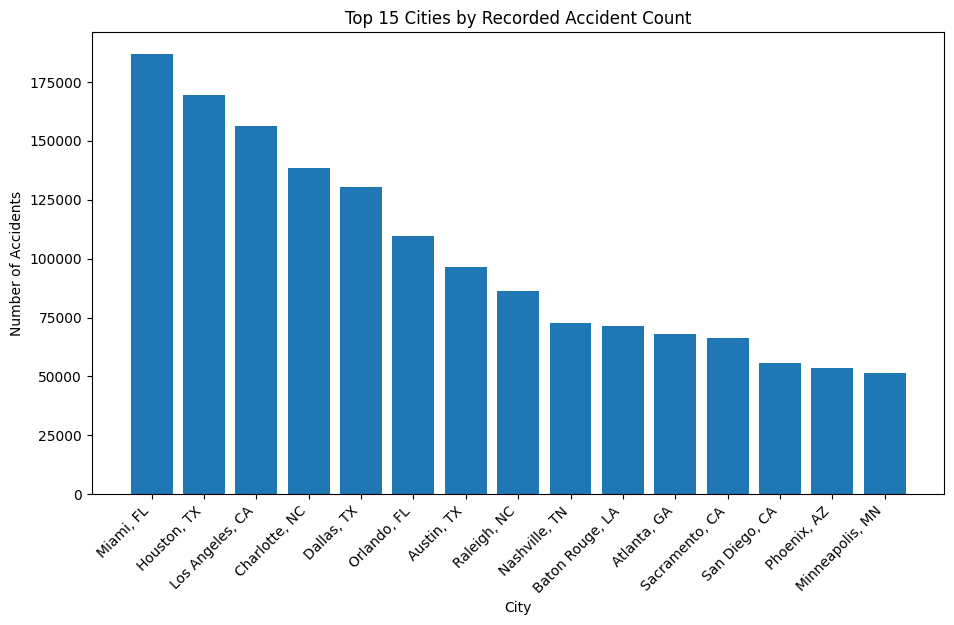

In [106]:
# Visualize top 15 cities by accident count

top_cities_by_count = city_severity_summary.head(15).copy()

top_cities_by_count["City_State"] = (
    top_cities_by_count["City"].astype(str) + ", " + top_cities_by_count["State"].astype(str)
)

plt.figure(figsize=(11, 6))

plt.bar(
    top_cities_by_count["City_State"],
    top_cities_by_count["Accident_Count"]
)

plt.title("Top 15 Cities by Recorded Accident Count")
plt.xlabel("City")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [107]:
# Top cities by severe accident rate, limited to cities with at least 5,000 accident records

city_severity_rate_filtered = city_severity_summary[
    city_severity_summary["Accident_Count"] >= 5000
].sort_values(
    by="Severe_Rate_Percent",
    ascending=False
)

city_severity_rate_filtered.head(15)

,State,City,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
9422,MO,Saint Louis,17045,10884,0.64,63.85
4931,IL,Chicago,32035,18867,0.59,58.89
6461,KY,Louisville,16221,9273,0.57,57.17
3699,GA,Decatur,7164,4056,0.57,56.62
16253,RI,Providence,7741,4043,0.52,52.23
3582,GA,Atlanta,68154,33842,0.50,49.66
17389,TX,Fort Worth,19766,9245,0.47,46.77
17643,TX,Mesquite,6539,2925,0.45,44.73
12228,NY,Albany,7403,3233,0.44,43.67
13583,OH,Columbus,19254,8358,0.43,43.41


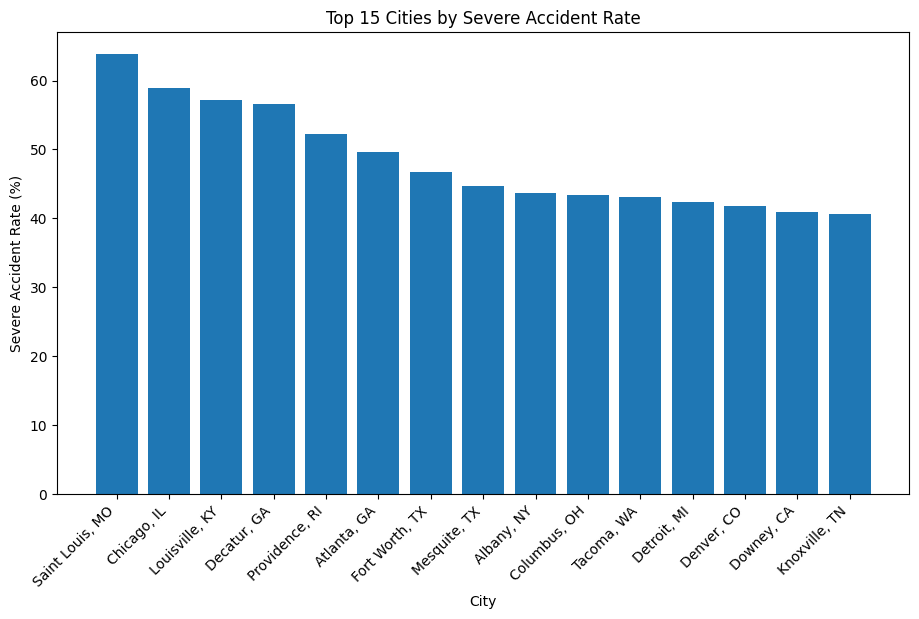

In [108]:
# Visualize top 15 cities by severe accident rate

top_cities_by_severe_rate = city_severity_rate_filtered.head(15).copy()

top_cities_by_severe_rate["City_State"] = (
    top_cities_by_severe_rate["City"].astype(str) + ", " + top_cities_by_severe_rate["State"].astype(str)
)

plt.figure(figsize=(11, 6))

plt.bar(
    top_cities_by_severe_rate["City_State"],
    top_cities_by_severe_rate["Severe_Rate_Percent"]
)

plt.title("Top 15 Cities by Severe Accident Rate")
plt.xlabel("City")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

In [110]:
# Accident count and severe accident rate by county

county_severity_summary = (
    df_clean.groupby(["State", "County"])
    .agg(
        Accident_Count=("ID", "count"),
        Severe_Count=("Severe_Accident", "sum"),
        Severe_Rate=("Severe_Accident", "mean")
    )
    .reset_index()
)

county_severity_summary["Severe_Rate_Percent"] = (
    county_severity_summary["Severe_Rate"] * 100
).round(2)

county_severity_summary = county_severity_summary.sort_values(
    by="Accident_Count",
    ascending=False
)

county_severity_summary.head(15)

,State,County,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
180,CA,Los Angeles,526851,117818,0.22,22.36
351,FL,Miami-Dade,251601,19386,0.08,7.71
2542,TX,Harris,180905,34212,0.19,18.91
2499,TX,Dallas,155733,44601,0.29,28.64
1689,NC,Mecklenburg,145788,8855,0.06,6.07
356,FL,Orange,124321,8937,0.07,7.19
1721,NC,Wake,117890,11278,0.10,9.57
197,CA,San Bernardino,109631,20268,0.18,18.49
2660,TX,Travis,107881,9860,0.09,9.14
191,CA,Orange,107580,18114,0.17,16.84


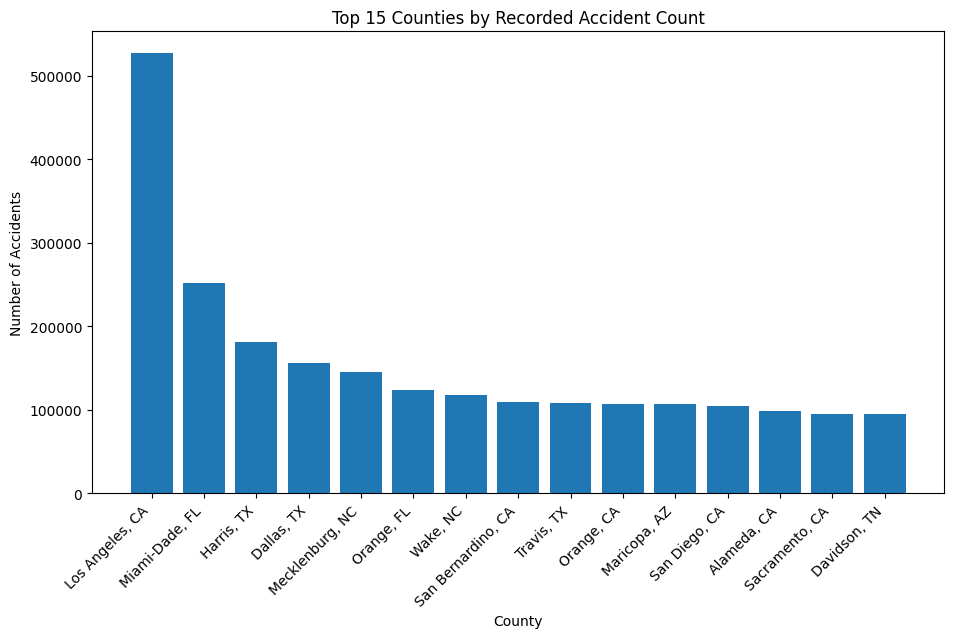

In [111]:
# Visualize top 15 counties by accident count

top_counties_by_count = county_severity_summary.head(15).copy()

top_counties_by_count["County_State"] = (
    top_counties_by_count["County"].astype(str) + ", " + top_counties_by_count["State"].astype(str)
)

plt.figure(figsize=(11, 6))

plt.bar(
    top_counties_by_count["County_State"],
    top_counties_by_count["Accident_Count"]
)

plt.title("Top 15 Counties by Recorded Accident Count")
plt.xlabel("County")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [112]:
# Top counties by severe accident rate, limited to counties with at least 10,000 accident records

county_severity_rate_filtered = county_severity_summary[
    county_severity_summary["Accident_Count"] >= 10000
].sort_values(
    by="Severe_Rate_Percent",
    ascending=False
)

county_severity_rate_filtered.head(15)

,State,County,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
1481,MO,St. Louis County,16924,10502,0.62,62.05
1017,KY,Jefferson,16672,9365,0.56,56.17
422,GA,DeKalb,21807,12233,0.56,56.10
701,IL,Cook,65369,34143,0.52,52.23
412,GA,Cobb,12373,6399,0.52,51.72
1270,MI,Oakland,16953,8380,0.49,49.43
2265,RI,Providence,13435,6410,0.48,47.71
440,GA,Fulton,54565,25601,0.47,46.92
1292,MI,Wayne,40273,17954,0.45,44.58
220,CO,Adams,12825,5534,0.43,43.15


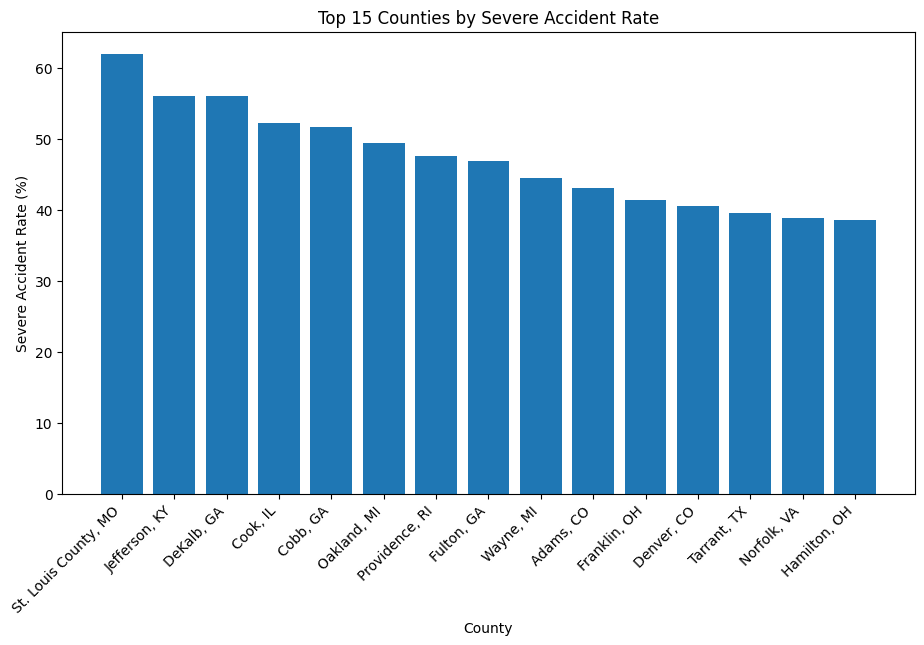

In [113]:
# Visualize top 15 counties by severe accident rate

top_counties_by_severe_rate = county_severity_rate_filtered.head(15).copy()

top_counties_by_severe_rate["County_State"] = (
    top_counties_by_severe_rate["County"].astype(str) + ", " + top_counties_by_severe_rate["State"].astype(str)
)

plt.figure(figsize=(11, 6))

plt.bar(
    top_counties_by_severe_rate["County_State"],
    top_counties_by_severe_rate["Severe_Rate_Percent"]
)

plt.title("Top 15 Counties by Severe Accident Rate")
plt.xlabel("County")
plt.ylabel("Severe Accident Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.show()

### Geographic Patterns by City and County Interpretation

City- and county-level accident patterns provide more local detail than the state-level analysis. The cities with the highest recorded accident counts are concentrated in large metropolitan areas. Miami had the highest number of recorded accidents with 186,768 records, followed by Houston with 169,428, Los Angeles with 156,491, Charlotte with 138,345, and Dallas with 130,303.

However, the cities with the highest severe-accident rates are not the same as the cities with the highest accident counts. Among cities with at least 5,000 recorded accidents, Saint Louis had the highest severe-accident rate at 63.85%, followed by Chicago at 58.89%, Louisville at 57.17%, Decatur at 56.62%, and Providence at 52.23%. Atlanta is notable because it appears in both views: it ranks among the top cities by accident count and also has a high severe-accident rate of 49.66%.

County-level patterns show a similar distinction between accident volume and severity rate. Los Angeles County, California had the highest recorded accident count with 526,851 records, followed by Miami-Dade County, Florida with 251,601, Harris County, Texas with 180,905, Dallas County, Texas with 155,733, and Mecklenburg County, North Carolina with 145,788.

The counties with the highest severe-accident rates are different from the highest-count counties. Among counties with at least 10,000 recorded accidents, St. Louis County, Missouri had the highest severe-accident rate at 62.05%, followed by Jefferson County, Kentucky at 56.17%, DeKalb County, Georgia at 56.10%, Cook County, Illinois at 52.23%, and Cobb County, Georgia at 51.72%.

These results reinforce an important theme from the state-level analysis: areas with the most recorded accidents are not always the areas with the highest severe-accident rates. High-count cities and counties may require broad congestion, enforcement, and incident-response strategies, while high-severity-rate cities and counties may warrant targeted safety audits, roadway-design reviews, speed-management strategies, or focused infrastructure improvements.

The city and county findings are especially useful for dashboard development because they can help users compare accident volume and severe-accident rate geographically. For DOT decision-making, both measures should be considered together rather than relying on raw accident counts alone.

## **11C EDA Summary Candidate Findings**

### EDA Summary and Candidate Findings

The exploratory data analysis identified several important patterns in recorded accident frequency and severe-accident rates across time, weather, lighting, roadway features, and geography. A key theme throughout the EDA is that high accident counts and high severe-accident rates do not always occur in the same categories. This distinction is important because the DOT may need different strategies for reducing total accident volume versus reducing the share of severe accidents.

The overall severity distribution showed that most accidents were classified as non-severe. Severity 1 and Severity 2 accidents accounted for 80.54% of the dataset, while Severity 3 and Severity 4 accidents accounted for 19.46%. Because severe accidents still represent nearly one in five recorded accidents, the binary `Severe_Accident` feature provides a useful outcome for comparing accident seriousness across conditions.

Temporal analysis showed that recorded accident counts increased substantially from 2016 through 2022, while 2023 appears lower because the dataset only includes records through March 31, 2023. Monthly accident counts were highest in December, November, and January, suggesting that late fall and winter months may be important periods for safety planning. The monthly trend also showed a noticeable decline around early 2020, which is consistent with COVID-19-related travel reductions and changes in commuting behavior, although this dataset does not include traffic-volume or vehicle-miles-traveled data.

Day-of-week and hour-of-day analysis showed that accidents are much more common on weekdays than weekends. Friday had the highest accident count, while Sunday had the lowest. Hourly accident counts showed clear commute-related peaks, especially around 7 AM, 8 AM, 4 PM, and 5 PM. Rush-hour periods accounted for 36.00% of recorded accidents, making commute periods important for accident-volume planning.

Severe-accident rates revealed a different temporal pattern. Weekends had a higher severe-accident rate than weekdays, with weekend accidents classified as severe 21.60% of the time compared with 19.06% for weekdays. Severe-accident rates were also not highest during the busiest commute hours. Instead, some lower-volume hours, such as early morning and evening periods, showed higher severe-accident rates. This suggests that DOT strategies should consider both accident volume and severity rate rather than focusing only on the busiest travel periods.

Weather analysis showed that most accidents occurred during common weather conditions such as `Clear/Fair` and `Cloudy`. However, rain and recorded precipitation were associated with higher severe-accident rates. Rain had a severe-accident rate of 23.41%, while accidents with recorded precipitation had a severe-accident rate of 22.89% compared with 19.21% for accidents without recorded precipitation. This suggests that wet-weather conditions may be associated with greater accident seriousness.

Visibility analysis showed that most accidents occurred when visibility was clear, but low and moderate visibility categories had somewhat higher severe-accident rates than clear visibility. The relationship was not perfectly linear, since very low visibility had a lower severe-accident rate than expected. This may reflect lower driving speeds, fewer trips, or more cautious driving behavior during extremely poor visibility conditions.

Lighting analysis produced a somewhat counterintuitive finding. Daytime accidents were more frequent and had a slightly higher severe-accident rate than nighttime accidents. Daytime accidents had a severe-accident rate of 19.73%, while nighttime accidents had a rate of 18.92%. This suggests that lighting condition alone does not explain accident severity in this dataset and should be interpreted alongside time of day, traffic volume, roadway type, and weather.

Roadway-feature analysis produced one of the strongest infrastructure-related findings. Records with no marked roadway features had a severe-accident rate of 22.13%, while records with one or more marked roadway features generally had lower severe-accident rates. Among individual roadway features, `Junction` stood out with a severe-accident rate of 26.79%, much higher than most other roadway features. This suggests that junction-related accidents may warrant closer infrastructure review.

Geographic analysis showed that accident counts are highly concentrated in certain states, cities, and counties. California, Florida, Texas, South Carolina, and New York had the highest state-level accident counts. However, states with the highest severe-accident rates were different, including Rhode Island, Georgia, Kentucky, Wisconsin, and Colorado among states with at least 10,000 records. This reinforces the importance of comparing both accident volume and severe-accident rate.

City and county analysis showed similar patterns. Cities such as Miami, Houston, Los Angeles, Charlotte, and Dallas had the highest recorded accident counts. However, cities such as Saint Louis, Chicago, Louisville, Decatur, and Providence had the highest severe-accident rates among cities with at least 5,000 records. County-level results also showed that the highest-count counties were not always the highest-severity-rate counties.

Based on the EDA, several candidate findings should be explored further through statistical testing:

1. Accidents during recorded precipitation appear to have a higher severe-accident rate than accidents without recorded precipitation.
2. Weekend accidents appear to have a higher severe-accident rate than weekday accidents.
3. Junction-related accidents appear to have a higher severe-accident rate than many other roadway-feature categories.
4. Geographic areas with the most recorded accidents are not always the areas with the highest severe-accident rates.
5. High accident-volume periods, such as weekday commute hours, do not always have the highest severe-accident rates.

These findings will guide the next stage of the project, where statistical testing will be used to evaluate whether selected differences in severe-accident rates are meaningful and relevant for DOT recommendations.


### EDA Summary and Candidate Findings

The exploratory data analysis identified several important patterns in recorded accident frequency and severe-accident rates across time, weather, lighting, roadway features, and geography. A key theme throughout the EDA is that high accident counts and high severe-accident rates do not always occur in the same categories. This distinction is important because the DOT may need different strategies for reducing total accident volume versus reducing the share of severe accidents.

The overall severity distribution showed that most accidents were classified as non-severe. Severity 1 and Severity 2 accidents accounted for 80.54% of the dataset, while Severity 3 and Severity 4 accidents accounted for 19.46%. Because severe accidents still represent nearly one in five recorded accidents, the binary `Severe_Accident` feature provides a useful outcome for comparing accident seriousness across conditions.

Temporal analysis showed that recorded accident counts increased substantially from 2016 through 2022, while 2023 appears lower because the dataset only includes records through March 31, 2023. Monthly accident counts were highest in December, November, and January, suggesting that late fall and winter months may be important periods for safety planning. The monthly trend also showed a noticeable decline around early 2020, which is consistent with COVID-19-related travel reductions and changes in commuting behavior, although this dataset does not include traffic-volume or vehicle-miles-traveled data.

Day-of-week and hour-of-day analysis showed that accidents are much more common on weekdays than weekends. Friday had the highest accident count, while Sunday had the lowest. Hourly accident counts showed clear commute-related peaks, especially around 7 AM, 8 AM, 4 PM, and 5 PM. Rush-hour periods accounted for 36.00% of recorded accidents, making commute periods important for accident-volume planning.

Severe-accident rates revealed a different temporal pattern. Weekends had a higher severe-accident rate than weekdays, with weekend accidents classified as severe 21.60% of the time compared with 19.06% for weekdays. Severe-accident rates were also not highest during the busiest commute hours. Instead, some lower-volume hours, such as early morning and evening periods, showed higher severe-accident rates. This suggests that DOT strategies should consider both accident volume and severity rate rather than focusing only on the busiest travel periods.

Weather analysis showed that most accidents occurred during common weather conditions such as `Clear/Fair` and `Cloudy`. However, rain and recorded precipitation were associated with higher severe-accident rates. Rain had a severe-accident rate of 23.41%, while accidents with recorded precipitation had a severe-accident rate of 22.89% compared with 19.21% for accidents without recorded precipitation. This suggests that wet-weather conditions may be associated with greater accident seriousness.

Visibility analysis showed that most accidents occurred when visibility was clear, but low and moderate visibility categories had somewhat higher severe-accident rates than clear visibility. The relationship was not perfectly linear, since very low visibility had a lower severe-accident rate than expected. This may reflect lower driving speeds, fewer trips, or more cautious driving behavior during extremely poor visibility conditions.

Lighting analysis produced a somewhat counterintuitive finding. Daytime accidents were more frequent and had a slightly higher severe-accident rate than nighttime accidents. Daytime accidents had a severe-accident rate of 19.73%, while nighttime accidents had a rate of 18.92%. This suggests that lighting condition alone does not explain accident severity in this dataset and should be interpreted alongside time of day, traffic volume, roadway type, and weather.

Roadway-feature analysis produced one of the strongest infrastructure-related findings. Records with no marked roadway features had a severe-accident rate of 22.13%, while records with one or more marked roadway features generally had lower severe-accident rates. Among individual roadway features, `Junction` stood out with a severe-accident rate of 26.79%, much higher than most other roadway features. This suggests that junction-related accidents may warrant closer infrastructure review.

Geographic analysis showed that accident counts are highly concentrated in certain states, cities, and counties. California, Florida, Texas, South Carolina, and New York had the highest state-level accident counts. However, states with the highest severe-accident rates were different, including Rhode Island, Georgia, Kentucky, Wisconsin, and Colorado among states with at least 10,000 records. This reinforces the importance of comparing both accident volume and severe-accident rate.

City and county analysis showed similar patterns. Cities such as Miami, Houston, Los Angeles, Charlotte, and Dallas had the highest recorded accident counts. However, cities such as Saint Louis, Chicago, Louisville, Decatur, and Providence had the highest severe-accident rates among cities with at least 5,000 records. County-level results also showed that the highest-count counties were not always the highest-severity-rate counties.

Based on the EDA, several candidate findings should be explored further through statistical testing:

1. Accidents during recorded precipitation appear to have a higher severe-accident rate than accidents without recorded precipitation.
2. Weekend accidents appear to have a higher severe-accident rate than weekday accidents.
3. Junction-related accidents appear to have a higher severe-accident rate than many other roadway-feature categories.
4. Geographic areas with the most recorded accidents are not always the areas with the highest severe-accident rates.
5. High accident-volume periods, such as weekday commute hours, do not always have the highest severe-accident rates.

These findings will guide the next stage of the project, where statistical testing will be used to evaluate whether selected differences in severe-accident rates are meaningful and relevant for DOT recommendations.


## **Step 6: Statistical Data Analysis (8 Steps: 1D - 8D)** 

This section uses statistical testing to validate several of the strongest patterns identified during exploratory data analysis. Because the main target variable, `Severe_Accident`, is binary, chi-square tests of independence are used to test whether accident severity is statistically associated with categorical risk factors.

The three primary hypotheses tested are:

1. Whether recorded precipitation is associated with severe accident outcomes.
2. Whether weekend accidents are associated with different severe-accident rates than weekday accidents.
3. Whether junction-related accidents are associated with higher severe-accident rates than non-junction accidents.

Because the dataset contains over 7.7 million records, very small differences may become statistically significant. For that reason, this analysis reports both p-values and effect sizes using Cramér’s V. The p-value helps determine whether an association is statistically detectable, while Cramér’s V helps evaluate whether the association is practically meaningful.

#### 1D Imports and load cleaned data

In [115]:
# Basic and necessary imports for statistical analysis and modeling.
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr


In [116]:

# Load cleaned dataset for statistical analysis

df = pd.read_parquet("Data/cleaned_us_accidents.parquet")

df.shape

(7728394, 63)

#### 2D Create Helper Function for Chi-Square Tests
This will make all three tests clean and consistent.

In [117]:
# Helper function for chi-square test, severe-rate table, and Cramer's V

def chi_square_severity_test(df, feature_col, target_col="Severe_Accident"):
    """
    Performs chi-square test of independence between a categorical feature
    and binary accident severity target.
    """
    
    # Create contingency table
    contingency_table = pd.crosstab(df[feature_col], df[target_col])
    
    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Cramer's V effect size
    n = contingency_table.to_numpy().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    # Severe-rate summary
    summary = (
        df.groupby(feature_col)[target_col]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Accident_Count",
            "sum": "Severe_Count",
            "mean": "Severe_Rate"
        })
    )
    
    summary["Severe_Rate_Percent"] = (summary["Severe_Rate"] * 100).round(2)
    summary = summary.sort_values("Severe_Rate", ascending=False)
    
    print(f"Chi-Square Test for {feature_col} vs {target_col}")
    print("-" * 60)
    print(f"Chi-square statistic: {chi2:,.4f}")
    print(f"p-value: {p_value:.6g}")
    print(f"Degrees of freedom: {dof}")
    print(f"Cramer's V: {cramers_v:.6f}")
    
    return summary, contingency_table

### Statistical Testing Methodology

For each categorical variable, a chi-square test of independence was used to determine whether the feature is statistically associated with accident severity.

The hypotheses for each test are:

- **Null hypothesis:** The feature and accident severity are independent.
- **Alternative hypothesis:** The feature and accident severity are associated.

A significance level of α = 0.05 was used. If the p-value is below 0.05, the null hypothesis is rejected.

However, because this dataset is very large, statistical significance alone is not enough to determine whether a factor is practically important. Therefore, Cramér’s V is also reported as an effect size. Cramér’s V values closer to 0 indicate a weaker association, while larger values indicate a stronger association.

#### 3D Test 1 - Precipitation vs Severity


### Hypothesis Test 1: Recorded Precipitation vs Accident Severity

The first statistical test examined whether recorded precipitation is associated with accident severity. During EDA, accidents with recorded precipitation appeared to have a higher severe-accident rate than accidents with no recorded precipitation. A chi-square test of independence was used to determine whether this pattern was statistically significant.

The hypotheses were:

- **Null hypothesis:** Recorded precipitation and accident severity are independent.
- **Alternative hypothesis:** Recorded precipitation and accident severity are associated.

Recorded precipitation was converted into a binary categorical variable:

- `Recorded Precipitation`
- `No Recorded Precipitation`

Accident severity was measured using the binary target variable `Severe_Accident`, where Severity 3 or 4 accidents were classified as severe and Severity 1 or 2 accidents were classified as non-severe.

First, create a clean precipitation indicator.

In [118]:
# Check precipitation column

df["Precipitation(in)"].describe()

count   5,524,808.00
mean            0.01
std             0.11
min             0.00
25%             0.00
50%             0.00
75%             0.00
max            36.47
Name: Precipitation(in), dtype: float64

In [119]:
# Create binary precipitation indicator

df["Precipitation_Recorded"] = np.where(df["Precipitation(in)"] > 0, 1, 0)

df["Precipitation_Recorded"].value_counts()

Precipitation_Recorded
0    7195304
1     533090
Name: count, dtype: int64

In [120]:
# Add readable labels

df["Precipitation_Group"] = df["Precipitation_Recorded"].map({
    0: "No Recorded Precipitation",
    1: "Recorded Precipitation"
})

df["Precipitation_Group"].value_counts()

Precipitation_Group
No Recorded Precipitation    7195304
Recorded Precipitation        533090
Name: count, dtype: int64

In [121]:
# Run the chi-square test and get severe-rate summary for precipitation presence
precip_summary, precip_table = chi_square_severity_test(
    df,
    feature_col="Precipitation_Group"
)

precip_summary


Chi-Square Test for Precipitation_Group vs Severe_Accident
------------------------------------------------------------
Chi-square statistic: 4,304.0648
p-value: 0
Degrees of freedom: 1
Cramer's V: 0.023599


,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
Precipitation_Group,,,,
Recorded Precipitation,533090,122045,0.23,22.89
No Recorded Precipitation,7195304,1382002,0.19,19.21


In [122]:
precip_table

Severe_Accident,0,1
Precipitation_Group,,
No Recorded Precipitation,5813302,1382002
Recorded Precipitation,411045,122045


### Precipitation Test Results

The chi-square test produced a chi-square statistic of **4,304.0648** with **1 degree of freedom** and a p-value of **0.000000**. Since the p-value is below the significance level of 0.05, the null hypothesis is rejected. This indicates that recorded precipitation and accident severity are statistically associated.

The severe-accident rate was higher for accidents with recorded precipitation than for accidents with no recorded precipitation:

- Accidents with recorded precipitation: **22.89% severe**
- Accidents with no recorded precipitation: **19.21% severe**

This means accidents with recorded precipitation had a severe-accident rate that was approximately **3.68 percentage points higher** than accidents without recorded precipitation.

The contingency table also shows that out of **533,090** accidents with recorded precipitation, **122,045** were severe. In comparison, out of **7,195,304** accidents with no recorded precipitation, **1,382,002** were severe.

### Interpretation

These results support the EDA finding that precipitation is associated with a higher severe-accident rate. Accidents with recorded precipitation were severe **22.89%** of the time, compared to **19.21%** for accidents without recorded precipitation.

However, the effect size should also be considered. Cramér’s V was **0.023599**, which indicates a weak association. This means that although the relationship is statistically significant, precipitation status alone does not strongly explain accident severity.

This is expected in a dataset of more than 7.7 million records, where even relatively small differences can produce very small p-values. Therefore, the result should be interpreted as evidence that precipitation is a contributing risk factor, but not as a standalone explanation for severe accidents.

From a Department of Transportation perspective, this finding is still useful because precipitation is a recognizable environmental condition that can inform public safety messaging, weather-related traffic warnings, and resource planning during rain or wet-road conditions.

#### 4D Mann-Whitney U Test - Precipitation Amount by Severity (To show significance in test 1)

Create precipitation groups

In [124]:
# Compare precipitation amount between severe and non-severe accidents

non_severe_precip = df.loc[df["Severe_Accident"] == 0, "Precipitation(in)"].dropna()
severe_precip = df.loc[df["Severe_Accident"] == 1, "Precipitation(in)"].dropna()

print("Non-severe precipitation summary:")
print(non_severe_precip.describe())

print("\nSevere precipitation summary:")
print(severe_precip.describe())

Non-severe precipitation summary:
count   4,730,465.00
mean            0.01
std             0.10
min             0.00
25%             0.00
50%             0.00
75%             0.00
max            36.47
Name: Precipitation(in), dtype: float64

Severe precipitation summary:
count   794,343.00
mean          0.02
std           0.17
min           0.00
25%           0.00
50%           0.00
75%           0.00
max          23.97
Name: Precipitation(in), dtype: float64


In [125]:
# Check skewness of precipitation amounts by severity group

print("Non-severe precipitation skewness:")
print(non_severe_precip.skew())

print("\nSevere precipitation skewness:")
print(severe_precip.skew())

Non-severe precipitation skewness:
101.9364972461314

Severe precipitation skewness:
52.022037915097265


### Mann-Whitney U Test: Precipitation Amount by Severity

In addition to testing whether recorded precipitation is associated with accident severity, a Mann-Whitney U test was used to compare actual precipitation amounts between severe and non-severe accidents.

A standard independent-samples t-test compares group means and assumes that the variable is approximately normally distributed within each group. However, precipitation amounts are typically highly skewed because most accidents have little or no recorded precipitation, while a smaller number occur during heavier precipitation.

Because this normality assumption is unlikely to hold, the Mann-Whitney U test was selected as a nonparametric alternative. This test compares the distributions of precipitation amounts between two independent groups without requiring normally distributed data.

The hypotheses were:

- **Null hypothesis:** The distribution of precipitation amounts is the same for severe and non-severe accidents.
- **Alternative hypothesis:** The distribution of precipitation amounts differs between severe and non-severe accidents.

In [126]:
# Mann-Whitney U test for precipitation amount by severity group

u_stat, p_value = mannwhitneyu(
    non_severe_precip,
    severe_precip,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat:,.4f}")
print(f"p-value: {p_value:.6g}")

Mann-Whitney U statistic: 1,751,988,137,730.0000
p-value: 0


In [127]:
# Optional: Mann-Whitney U test only for accidents with recorded precipitation

precip_only_df = df[df["Precipitation(in)"] > 0].copy()

non_severe_precip_positive = precip_only_df.loc[
    precip_only_df["Severe_Accident"] == 0,
    "Precipitation(in)"
].dropna()

severe_precip_positive = precip_only_df.loc[
    precip_only_df["Severe_Accident"] == 1,
    "Precipitation(in)"
].dropna()

print("Non-severe accidents with recorded precipitation:")
print(non_severe_precip_positive.describe())

print("\nSevere accidents with recorded precipitation:")
print(severe_precip_positive.describe())

Non-severe accidents with recorded precipitation:
count   411,045.00
mean          0.08
std           0.31
min           0.01
25%           0.01
50%           0.03
75%           0.08
max          36.47
Name: Precipitation(in), dtype: float64

Severe accidents with recorded precipitation:
count   122,045.00
mean          0.10
std           0.43
min           0.01
25%           0.01
50%           0.04
75%           0.09
max          23.97
Name: Precipitation(in), dtype: float64


In [128]:
# Mann-Whitney U test for precipitation amount among precipitation-only accidents

u_stat_positive, p_value_positive = mannwhitneyu(
    non_severe_precip_positive,
    severe_precip_positive,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat_positive:,.4f}")
print(f"p-value: {p_value_positive:.6g}")

Mann-Whitney U statistic: 23,674,692,740.0000
p-value: 6.58296e-201


In [129]:
# Summary table for precipitation-only accidents

precip_positive_summary = (
    precip_only_df.groupby("Severe_Accident")["Precipitation(in)"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

precip_positive_summary.index = [
    "Non-Severe Accidents with Precipitation",
    "Severe Accidents with Precipitation"
]

precip_positive_summary = precip_positive_summary.round(4)

precip_positive_summary

,count,mean,median,std,min,max
Non-Severe Accidents with Precipitation,411045,0.08,0.03,0.31,0.01,36.47
Severe Accidents with Precipitation,122045,0.10,0.04,0.43,0.01,23.97


### Mann-Whitney U Test: Precipitation Amount by Severity

In addition to testing whether recorded precipitation is associated with accident severity, a Mann-Whitney U test was used to compare precipitation amounts between severe and non-severe accidents.

This test was selected instead of a standard independent-samples t-test because precipitation values are highly skewed. In both groups, the median precipitation amount was **0.00 inches**, and the 25th, 50th, and 75th percentiles were also **0.00 inches**. This shows that most accidents occurred with no recorded precipitation, while a smaller number of accidents occurred during heavier precipitation.

The skewness values confirm this issue:

- Non-severe accidents: **101.94**
- Severe accidents: **52.02**

Because these distributions are not approximately normal, a nonparametric test is more appropriate than a t-test.

In [131]:
# Mann-Whitney U test for precipitation amount among precipitation-only accidents

u_stat_positive, p_value_positive = mannwhitneyu(
    non_severe_precip_positive,
    severe_precip_positive,
    alternative="two-sided"
)

print(f"Mann-Whitney U statistic: {u_stat_positive:,.4f}")
print(f"p-value: {p_value_positive:.6g}")

Mann-Whitney U statistic: 23,674,692,740.0000
p-value: 6.58296e-201


### Precipitation-Only Mann-Whitney U Test Results

A second Mann-Whitney U test was performed using only accidents where precipitation was recorded, meaning `Precipitation(in)` was greater than 0.

This test produced a Mann-Whitney U statistic of **23,674,692,740.0000** and a p-value of **6.58296e-201**. Since the p-value is far below 0.05, the null hypothesis is rejected. This indicates that, among accidents with recorded precipitation, precipitation amounts differ significantly between severe and non-severe accidents.

The descriptive statistics show that severe accidents had slightly higher precipitation amounts:

- Non-severe accidents with precipitation: mean of **0.08 inches**, median of **0.03 inches**
- Severe accidents with precipitation: mean of **0.10 inches**, median of **0.04 inches**

Although this difference is statistically significant, it is still small in practical terms. The median difference is only **0.01 inches**, and both groups are concentrated at relatively low precipitation amounts. Therefore, precipitation amount appears to be associated with severity, but it should be interpreted as a modest contributing factor rather than a strong standalone predictor.

### Precipitation Analysis Conclusion

The precipitation analysis provides statistical support for the EDA finding that precipitation is associated with accident severity.

The chi-square test showed that accidents with recorded precipitation had a higher severe-accident rate than accidents without recorded precipitation: **22.89%** compared to **19.21%**. The Mann-Whitney U tests also showed statistically significant differences in precipitation amounts between severe and non-severe accidents, both across all accidents and among only accidents with recorded precipitation.

However, the effect size and descriptive statistics show that this relationship is modest. Cramér’s V for the chi-square test was only **0.023599**, and the precipitation-only median difference was just **0.01 inches**.

Overall, precipitation is statistically associated with accident severity, but it is not a strong standalone explanation. It is best interpreted as one environmental risk factor that may contribute to severe accident outcomes when combined with other conditions such as roadway design, traffic speed, visibility, lighting, and location.

## 5D Test 2 - Weekend vs Weekday Severity

### Hypothesis Test 2: Weekend vs Weekday Accident Severity

The second hypothesis test evaluated whether accident severity differs between weekday and weekend accidents. During EDA, weekdays had higher total accident counts, but weekends appeared to have a higher severe-accident rate. This test checks whether that observed pattern is statistically significant.

The hypotheses were:

- **Null hypothesis:** Weekend status and accident severity are independent.
- **Alternative hypothesis:** Weekend status and accident severity are associated.

Weekend status was created from the `Start_Time` column. Accidents occurring on Saturday or Sunday were classified as `Weekend`, while accidents occurring Monday through Friday were classified as `Weekday`.

A chi-square test of independence was used because both variables are categorical: weekend status is categorical, and accident severity is represented by the binary `Severe_Accident` target.

First, make sure Start_Time is datetime

In [132]:
# Make sure Start_Time is datetime

df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

df["Start_Time"].head()

0   2016-02-08 05:46:00
1   2016-02-08 06:07:59
2   2016-02-08 06:49:27
3   2016-02-08 07:23:34
4   2016-02-08 07:39:07
Name: Start_Time, dtype: datetime64[ns]

In [133]:
# Create weekend indicator from Start_Time

df["DayOfWeek"] = df["Start_Time"].dt.dayofweek

df["Weekend"] = np.where(df["DayOfWeek"].isin([5, 6]), 1, 0)

df["Weekend_Group"] = df["Weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

df["Weekend_Group"].value_counts()

Weekend_Group
Weekday    6496967
Weekend    1231427
Name: count, dtype: int64

In [134]:
# Use same helper function we already created for this test
# Chi-square test for weekend vs weekday severity

weekend_summary, weekend_table = chi_square_severity_test(
    df,
    feature_col="Weekend_Group"
)

weekend_summary

Chi-Square Test for Weekend_Group vs Severe_Accident
------------------------------------------------------------
Chi-square statistic: 4,290.6997
p-value: 0
Degrees of freedom: 1
Cramer's V: 0.023562


,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
Weekend_Group,,,,
Weekend,1231427,266038,0.22,21.60
Weekday,6496967,1238009,0.19,19.06


In [135]:
# Display weekend vs weekday contingency table

weekend_table

Severe_Accident,0,1
Weekend_Group,,
Weekday,5258958,1238009
Weekend,965389,266038


### Weekend vs Weekday Test Results

The chi-square test produced a chi-square statistic of **4,290.6997** with **1 degree of freedom** and a p-value of **0.000000**. Since the p-value is below the significance level of 0.05, the null hypothesis is rejected. This indicates that weekend status and accident severity are statistically associated.

The severe-accident rate was higher on weekends than on weekdays:

- Weekend accidents: **21.60% severe**
- Weekday accidents: **19.06% severe**

This means weekend accidents had a severe-accident rate that was approximately **2.54 percentage points higher** than weekday accidents.

The contingency table shows that there were **6,496,967** weekday accidents, of which **1,238,009** were severe and **5,258,958** were non-severe. In comparison, there were **1,231,427** weekend accidents, of which **266,038** were severe and **965,389** were non-severe.

### Interpretation

These results support the EDA finding that accident frequency and accident severity do not always follow the same pattern. Weekdays accounted for far more total recorded accidents than weekends, likely due to higher commuting and workday travel volume. However, weekend accidents had the higher severe-accident rate.

Although the result is statistically significant, the effect size should be interpreted carefully. Cramér’s V was **0.023562**, which indicates a weak association. This means weekend status is related to accident severity, but it does not strongly explain severity by itself.

This pattern may reflect differences in driving behavior, trip purpose, average speed, congestion levels, recreational travel, impairment risk, or reporting patterns between weekdays and weekends. From a Department of Transportation perspective, this finding may still be useful for weekend safety messaging, targeted enforcement, and resource planning during higher-risk travel periods.

Overall, the test supports the conclusion that weekend status is associated with accident severity, but it should be treated as one contextual risk factor among many.

## 6D Test 3 - Junction vs Non-Junction severity


The third hypothesis test evaluated whether junction-related accidents are associated with accident severity. During EDA, junction-related accidents showed a higher severe-accident rate than the overall dataset. This test checks whether that observed relationship is statistically significant.

The hypotheses were:

- **Null hypothesis:** Junction status and accident severity are independent.
- **Alternative hypothesis:** Junction status and accident severity are associated.

Junction status was based on the `Junction` column. Accidents marked as `True` were classified as `Junction`, while accidents marked as `False` were classified as `Non-Junction`.

A chi-square test of independence was used because both variables are categorical: junction status is categorical, and accident severity is represented by the binary `Severe_Accident` target.



In [136]:
# Check Junction values

df["Junction"].value_counts(dropna=False)

Junction
False    7157052
True      571342
Name: count, dtype: int64

In [137]:
# Create readable junction group

df["Junction_Group"] = df["Junction"].map({
    False: "Non-Junction",
    True: "Junction"
})

df["Junction_Group"].value_counts(dropna=False)

Junction_Group
Non-Junction    7157052
Junction         571342
Name: count, dtype: int64

In [138]:
# Drop missing Junction values if any exist

junction_df = df.dropna(subset=["Junction_Group"]).copy()

junction_df["Junction_Group"].value_counts()

Junction_Group
Non-Junction    7157052
Junction         571342
Name: count, dtype: int64

In [139]:
# Chi-square test for junction vs non-junction severity

junction_summary, junction_table = chi_square_severity_test(
    junction_df,
    feature_col="Junction_Group"
)

junction_summary

Chi-Square Test for Junction_Group vs Severe_Accident
------------------------------------------------------------
Chi-square statistic: 21,154.1696
p-value: 0
Degrees of freedom: 1
Cramer's V: 0.052318


,Accident_Count,Severe_Count,Severe_Rate,Severe_Rate_Percent
Junction_Group,,,,
Junction,571342,153076,0.27,26.79
Non-Junction,7157052,1350971,0.19,18.88


In [140]:
# Display junction vs non-junction contingency table

junction_table

Severe_Accident,0,1
Junction_Group,,
Junction,418266,153076
Non-Junction,5806081,1350971


### Junction vs Non-Junction Test Results

The chi-square test produced a chi-square statistic of **21,154.1696** with **1 degree of freedom** and a p-value of **0.000000**. Since the p-value is below the significance level of 0.05, the null hypothesis is rejected. This indicates that junction status and accident severity are statistically associated.

The severe-accident rate was much higher for junction-related accidents than for non-junction accidents:

- Junction accidents: **26.79% severe**
- Non-junction accidents: **18.88% severe**

This means junction-related accidents had a severe-accident rate approximately **7.91 percentage points higher** than non-junction accidents.

The contingency table shows that there were **571,342** junction-related accidents, of which **153,076** were severe and **418,266** were non-severe. In comparison, there were **7,157,052** non-junction accidents, of which **1,350,971** were severe and **5,806,081** were non-severe.

### Interpretation

These results strongly support the EDA finding that junction-related accidents are associated with a higher severe-accident rate. While junction accidents made up a smaller share of total recorded accidents, they had a noticeably higher proportion of severe outcomes.

Cramér’s V was **0.052318**, which is still a relatively weak effect size in general terms, but it is larger than the effect sizes for precipitation and weekend status. This suggests that junction status has a stronger practical association with severity than the other tested factors so far.

From a Department of Transportation perspective, this is one of the more actionable findings in the statistical analysis. Unlike broad contextual factors such as weekend status or weather, junctions represent specific roadway locations where interventions may be possible. Potential safety improvements could include better signal timing, clearer signage, improved lighting, protected turn lanes, ramp redesign, speed management, or targeted safety audits at high-risk intersections and highway junctions.

Overall, the test supports the conclusion that junction status is statistically associated with accident severity and may be an important infrastructure-related factor to consider in later modeling and policy recommendations.

## 7D Correlation Analysis

A Spearman correlation analysis was performed to evaluate relationships between numeric accident variables and accident severity. Spearman correlation was selected because many of the accident-related variables are skewed, contain outliers, or are not normally distributed.

The analysis included numeric variables such as accident distance, temperature, humidity, pressure, visibility, wind speed, and precipitation. Because the full dataset contains more than 7.7 million records, a random sample of 500,000 records was used to make the correlation analysis more efficient while still preserving a large sample size.

The correlation results should be interpreted cautiously because `Severe_Accident` is a binary variable and correlation does not imply causation. However, the correlation matrix provides a useful supporting view of whether numeric variables have meaningful directional relationships with severity.

Overall, the correlation analysis helps confirm that accident severity is influenced by multiple factors rather than one single variable. The individual numeric correlations with severity are expected to be modest, which supports the need for later predictive modeling using multiple variables together.

In [141]:
# Select numeric variables for correlation analysis

corr_cols = [
    "Severe_Accident",
    "Severity",
    "Distance(mi)",
    "Temperature(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)"
]

# Keep only columns that exist in the dataframe
corr_cols = [col for col in corr_cols if col in df.columns]

# Drop missing values
corr_df = df[corr_cols].dropna()

corr_df.shape

(5399762, 9)

In [142]:
# Sample data for correlation analysis to improve performance

corr_sample = corr_df.sample(n=500000, random_state=42)

# Spearman correlation is used because many variables are skewed/non-normal
corr_matrix = corr_sample.corr(method="spearman")

corr_matrix["Severe_Accident"].sort_values(ascending=False)

Severe_Accident      1.00
Severity             0.97
Precipitation(in)    0.08
Wind_Speed(mph)      0.04
Humidity(%)          0.04
Temperature(F)       0.00
Pressure(in)        -0.03
Visibility(mi)      -0.04
Distance(mi)        -0.20
Name: Severe_Accident, dtype: float64

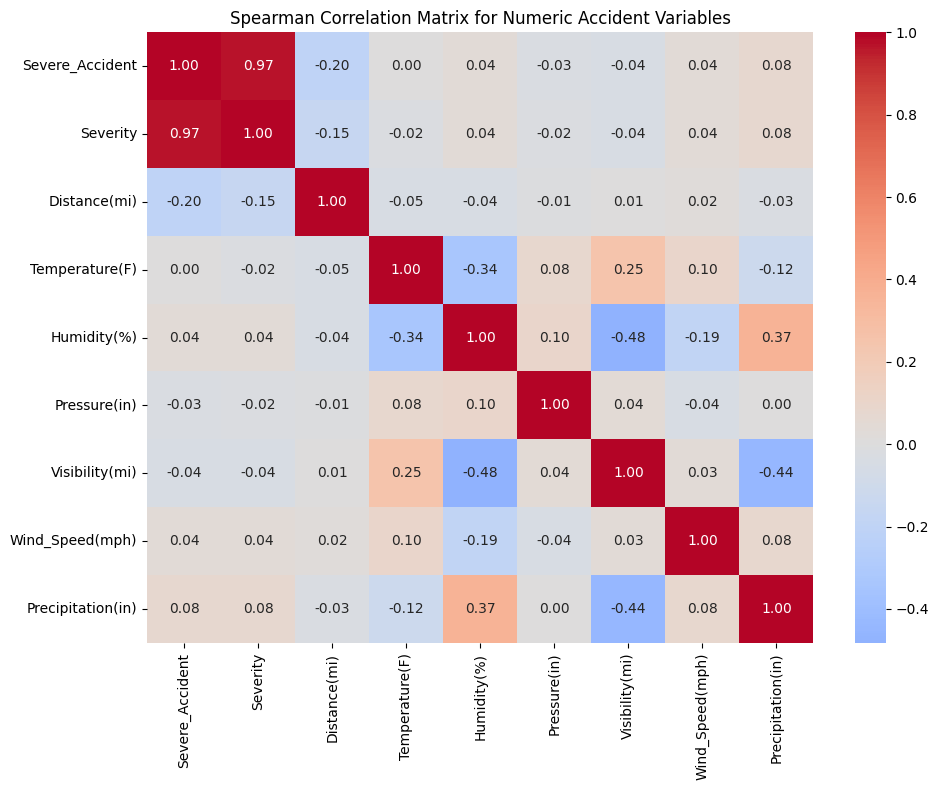

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Matrix for Numeric Accident Variables")
plt.tight_layout()
plt.show()

### Correlation Analysis Conclusion

A Spearman correlation analysis was performed to examine relationships between numeric accident variables and accident severity. Spearman correlation was selected because many accident-related variables, such as precipitation, wind speed, visibility, and distance, are not normally distributed and may contain skewed values or outliers. A sample of **500,000 records** was used for the correlation matrix to improve processing efficiency while still maintaining a large sample size.

The strongest correlation with `Severe_Accident` was `Severity`, with a correlation of **0.97**. This is expected because `Severe_Accident` was created directly from the original `Severity` column, where Severity 3 and 4 were classified as severe. Because of this, the strong correlation between these two variables confirms the target definition but should not be interpreted as an independent predictor.

Among the other numeric variables, most correlations with `Severe_Accident` were weak. `Precipitation(in)` had the strongest positive correlation outside of `Severity`, with a Spearman correlation of **0.08**. This supports the earlier precipitation analysis, which found that accidents with recorded precipitation had a higher severe-accident rate. However, the correlation is still small, indicating that precipitation alone does not strongly explain accident severity.

`Distance(mi)` had the strongest negative correlation with severe accidents at **-0.20**. This suggests that accidents classified as severe in this dataset tend to have shorter recorded accident distances. This may reflect how accident impact distance is measured or reported rather than a direct causal relationship. Other weather-related variables, including `Wind_Speed(mph)`, `Humidity(%)`, `Visibility(mi)`, and `Pressure(in)`, had weak correlations with severity.

Overall, the correlation analysis supports the broader conclusion that accident severity is not explained by one numeric variable alone. Instead, severity appears to be influenced by a combination of weather, roadway, temporal, and geographic factors. These weak individual correlations also support the need for predictive modeling, where multiple variables can be evaluated together to better identify patterns associated with severe accident outcomes.

## 8D ANOVA / Nonparametric Comparison: Precipitation Amount Across Severity Levels

To satisfy the requirement of comparing group means, precipitation amount was compared across the original accident `Severity` levels 1, 2, 3, and 4.

A one-way ANOVA is commonly used to compare the mean of a numeric variable across three or more groups. In this case, the numeric variable was `Precipitation(in)`, and the groups were the four original severity levels.

However, the precipitation summaries show that precipitation is highly skewed across all severity levels. Each severity group had a median precipitation value of **0.00 inches**, meaning that most accidents occurred with no recorded precipitation. The skewness values were also very high, ranging from **29.75** for Severity 1 accidents to **101.79** for Severity 2 accidents. Because this violates the normality assumption of ANOVA, the ANOVA result was calculated for reference, but the Kruskal-Wallis test was used as the more appropriate nonparametric alternative.

The hypotheses were:

* **Null hypothesis:** Precipitation amounts are distributed the same across Severity levels 1, 2, 3, and 4.
* **Alternative hypothesis:** At least one Severity level has a different precipitation amount distribution.


First, import ANOVA and Kruskal-Wallis tools

In [144]:
from scipy.stats import f_oneway, kruskal

In [145]:
# Compare precipitation amount across original Severity levels

precip_by_severity = (
    df.groupby("Severity")["Precipitation(in)"]
    .agg(["count", "mean", "median", "std", "min", "max", "skew"])
    .round(4)
)

precip_by_severity

,count,mean,median,std,min,max,skew
Severity,,,,,,,
1,63450,0.01,0.00,0.05,0.00,3.19,29.75
2,4667015,0.01,0.00,0.10,0.00,36.47,101.79
3,658955,0.02,0.00,0.19,0.00,23.97,48.74
4,135388,0.01,0.00,0.09,0.00,10.02,89.83


In [146]:
# Create precipitation groups by original Severity level

severity_1_precip = df.loc[df["Severity"] == 1, "Precipitation(in)"].dropna()
severity_2_precip = df.loc[df["Severity"] == 2, "Precipitation(in)"].dropna()
severity_3_precip = df.loc[df["Severity"] == 3, "Precipitation(in)"].dropna()
severity_4_precip = df.loc[df["Severity"] == 4, "Precipitation(in)"].dropna()

print("Group sizes:")
print("Severity 1:", len(severity_1_precip))
print("Severity 2:", len(severity_2_precip))
print("Severity 3:", len(severity_3_precip))
print("Severity 4:", len(severity_4_precip))

Group sizes:
Severity 1: 63450
Severity 2: 4667015
Severity 3: 658955
Severity 4: 135388


In [147]:
# One-way ANOVA comparing precipitation amount across Severity levels

anova_stat, anova_p = f_oneway(
    severity_1_precip,
    severity_2_precip,
    severity_3_precip,
    severity_4_precip
)

print(f"ANOVA F-statistic: {anova_stat:,.4f}")
print(f"ANOVA p-value: {anova_p:.6g}")

ANOVA F-statistic: 1,620.9298
ANOVA p-value: 0


In [148]:
# Kruskal-Wallis test as nonparametric alternative to ANOVA

kruskal_stat, kruskal_p = kruskal(
    severity_1_precip,
    severity_2_precip,
    severity_3_precip,
    severity_4_precip
)

print(f"Kruskal-Wallis statistic: {kruskal_stat:,.4f}")
print(f"Kruskal-Wallis p-value: {kruskal_p:.6g}")

Kruskal-Wallis statistic: 41,296.0657
Kruskal-Wallis p-value: 0


### ANOVA and Kruskal-Wallis Test Results

The one-way ANOVA produced an F-statistic of **1,620.9298** with a p-value of **0.000000**. This suggests that mean precipitation amounts differ across the four original severity levels.

However, because precipitation values are highly skewed, the Kruskal-Wallis test provides the more appropriate result. The Kruskal-Wallis test produced a statistic of **41,296.0657** with a p-value of **0.000000**. Since the p-value is below 0.05, the null hypothesis is rejected. This indicates that precipitation amount distributions differ significantly across accident severity levels.

The descriptive statistics show that Severity 3 accidents had the highest average precipitation amount at **0.02 inches**, while Severity 1, Severity 2, and Severity 4 accidents each had average precipitation values of about **0.01 inches**. However, the median was **0.00 inches** for every severity level.

This means that while precipitation amounts differ statistically across severity levels, the practical differences are small. The result supports the broader precipitation finding, but it also reinforces that precipitation amount alone is not a strong standalone explanation for accident severity.


### Significant Factors Contributing to Accident Severity and Frequency

The statistical analysis identified several significant factors associated with accident severity. The three primary categorical factors tested were recorded precipitation, weekend status, and junction status. All three chi-square tests produced p-values below 0.05, indicating that each factor is statistically associated with whether an accident is severe.

Among these factors, **junction status** showed the strongest practical relationship with severity. Junction-related accidents had a severe-accident rate of **26.79%**, compared to **18.88%** for non-junction accidents. This was the largest severe-rate difference among the three tested factors and also had the highest Cramér’s V value. This suggests that junctions may be one of the most meaningful roadway-related contributors to severe accident outcomes.

**Recorded precipitation** was also associated with higher severity. Accidents with recorded precipitation had a severe-accident rate of **22.89%**, compared to **19.21%** for accidents without recorded precipitation. The Mann-Whitney U tests further showed that precipitation amounts differed significantly between severe and non-severe accidents. However, the differences in precipitation amount were small in practical terms, meaning precipitation should be interpreted as a contributing environmental risk factor rather than a standalone explanation.

**Weekend status** was another significant factor. Weekend accidents had a severe-accident rate of **21.60%**, compared to **19.06%** for weekday accidents. This supports the EDA finding that accident frequency and accident severity do not always follow the same pattern. Weekdays had more total accidents, likely due to higher commuting and workday traffic volume, but weekends had a higher proportion of severe accidents.

The correlation analysis also showed that individual numeric weather and roadway variables had generally weak correlations with severe accidents. Outside of the original `Severity` column, which is directly related to the target definition, `Precipitation(in)` had a weak positive correlation with severe accidents, while `Distance(mi)` had the strongest negative correlation. These results suggest that accident severity is not driven by one variable alone, but rather by a combination of roadway, weather, temporal, and geographic factors.

For accident frequency, the EDA showed that accidents are more common during weekdays, in high-population states and cities, and during high-traffic periods such as rush hour. However, the statistical results show that the areas or conditions with the most accidents are not always the same as those with the highest severe-accident rates. This distinction is important for Department of Transportation planning because reducing total accident volume and reducing severe accident outcomes may require different strategies.


### Limitations of the Statistical Analysis

Several limitations should be considered when interpreting the statistical analysis results.

First, the dataset is extremely large, with more than **7.7 million records**. Because of this large sample size, even small differences between groups can produce statistically significant p-values. For that reason, p-values were interpreted alongside severe-rate differences and effect sizes such as Cramér’s V. Several results were statistically significant but had weak effect sizes, meaning they may have limited practical importance on their own.

Second, the analysis shows association, not causation. For example, precipitation, weekend status, and junction status were statistically associated with accident severity, but this does not prove that these factors directly caused accidents to become severe. Other variables such as traffic speed, driver behavior, road design, lighting, enforcement, and reporting practices may also influence severity.

Third, the accident records may be affected by reporting bias. The dataset includes recorded traffic accidents, but it may not capture every accident equally across all locations, agencies, time periods, or severity levels. Some states, cities, or roadway types may have more complete reporting than others, which could affect geographic and temporal patterns.

Fourth, some variables may contain missing values, measurement error, or inconsistent reporting. Weather variables such as precipitation, visibility, wind speed, and temperature may not perfectly describe the exact conditions at the accident location and time. Similarly, roadway indicator variables such as `Junction` depend on how the accident location was coded.

Fifth, some engineered variables simplify more complex conditions. For example, precipitation was converted into a binary recorded-versus-not-recorded variable, and weekend status was grouped into weekday versus weekend. These transformations make the statistical tests easier to interpret, but they may lose some detail.

Finally, the correlation analysis was based on numeric variables and should be interpreted cautiously because the target variable `Severe_Accident` is binary. Correlation values help identify directional relationships, but they do not fully capture complex interactions between variables.

Overall, the statistical analysis provides useful evidence supporting the EDA findings, but the results should be interpreted as preliminary evidence. Predictive modeling is needed to evaluate multiple factors together and better estimate which variables are most important for predicting severe accident outcomes.


## Statistical Analysis Final Conclusion

The statistical analysis validated several of the strongest patterns identified during exploratory data analysis. Chi-square tests showed that recorded precipitation, weekend status, and junction status are each statistically associated with accident severity. In all three cases, the null hypothesis of independence was rejected.

The precipitation analysis showed that accidents with recorded precipitation had a higher severe-accident rate than accidents without recorded precipitation: **22.89%** compared to **19.21%**. Mann-Whitney U tests also found statistically significant differences in precipitation amounts between severe and non-severe accidents. In addition, precipitation amount was compared across the original Severity levels 1 through 4 using ANOVA and the Kruskal-Wallis test. Because precipitation values were highly skewed, the Kruskal-Wallis test was the more appropriate method. It showed that precipitation distributions differed significantly across severity levels, although the practical differences were small because all groups had a median precipitation value of **0.00 inches**.

The weekend analysis showed that weekend accidents had a higher severe-accident rate than weekday accidents: **21.60%** compared to **19.06%**. This finding is important because it shows that accident frequency and accident severity are not identical. Weekdays had more total accidents, but weekends had a higher proportion of severe outcomes.

The junction analysis produced the strongest result among the three main hypothesis tests. Junction-related accidents had a severe-accident rate of **26.79%**, compared to **18.88%** for non-junction accidents. Junction status also had the highest Cramér’s V value among the tested categorical factors, making it the most practically meaningful factor tested in this section.

The correlation analysis showed that most individual numeric variables had weak relationships with severe accidents. Outside of the original `Severity` column, which is directly related to the target definition, `Precipitation(in)` had a weak positive correlation with severe accidents, while `Distance(mi)` had the strongest negative correlation. These results suggest that accident severity is influenced by multiple factors rather than one single variable.

Overall, this section provides statistical support for the project’s main EDA findings. Precipitation and weekend status are useful contextual risk indicators, while junction status stands out as a particularly important and actionable infrastructure-related factor. From a Department of Transportation perspective, these findings suggest that safety planning should consider not only where accidents happen most often, but also where accidents are more likely to become severe. These results provide a strong foundation for the next step of the project: predictive modeling of severe accident outcomes.


## **Step 7: Insights and Recommendations (Evaluation)**

Based on the exploratory data analysis and statistical testing, several actionable recommendations can be made to help the Department of Transportation reduce severe traffic accidents. These recommendations focus on roadway infrastructure, weather-related risk, temporal accident patterns, and geographic prioritization.

The goal is not only to reduce the total number of accidents, but also to reduce the proportion of accidents that result in severe outcomes.

## Recommendation 1: Prioritize Safety Improvements at Junctions and Intersections

One of the strongest findings from the analysis was that junction-related accidents had a much higher severe-accident rate than non-junction accidents. Junction accidents had a severe-accident rate of **26.79%**, compared to **18.88%** for non-junction accidents. The chi-square test confirmed that junction status and accident severity are statistically associated, and junction status had the highest Cramér’s V value among the three main categorical factors tested.

This suggests that junctions are an important roadway infrastructure factor related to severe accident outcomes.

### Actionable Steps

The Department of Transportation should identify high-risk junctions and intersections where severe accidents occur at elevated rates. These locations should be prioritized for roadway safety audits and targeted improvements.

Potential interventions include:

- Improving signal timing and protected turn phases.
- Adding or improving turn lanes.
- Increasing visibility through better lighting and signage.
- Improving lane markings and pavement markings.
- Installing warning signs or speed feedback signs near high-risk junctions.
- Redesigning confusing ramps, merges, or intersections.
- Reviewing crash histories at high-severity junction locations.

### Potential Impact

Improving high-risk junctions could reduce the number and percentage of severe accidents at these locations. Because junctions are specific physical locations, this recommendation is highly actionable and allows transportation agencies to focus resources where infrastructure changes may have the greatest safety benefit.

### Metrics to Track

Effectiveness could be measured using:

- Severe-accident rate at treated junctions before and after improvements.
- Total accident count at treated junctions.
- Number of Severity 3 and Severity 4 accidents at treated junctions.
- Percentage change in severe accidents within 6, 12, and 24 months after intervention.
- Comparison with similar untreated junctions as a control group.

### Challenges and Limitations

Infrastructure improvements can be expensive and may require coordination between local, state, and federal transportation agencies. Some junctions may need long-term redesign rather than quick fixes. Also, accident reductions may take time to measure because severe crashes are less frequent than minor crashes.

## Recommendation 2: Strengthen Weather-Responsive Traffic Safety Measures During Precipitation

The analysis found that accidents with recorded precipitation had a higher severe-accident rate than accidents without recorded precipitation. Accidents with recorded precipitation were severe **22.89%** of the time, compared to **19.21%** for accidents with no recorded precipitation. The chi-square test confirmed a statistically significant association between recorded precipitation and severity.

The Mann-Whitney U and Kruskal-Wallis tests also showed that precipitation amounts differed significantly across severity groups, although the practical differences were small. This suggests that precipitation is a contributing environmental risk factor, especially when combined with other roadway or traffic conditions.

### Actionable Steps

The Department of Transportation should strengthen weather-responsive safety strategies during rain and wet-road conditions.

Potential interventions include:

- Activating dynamic message signs during rainfall to warn drivers about wet roads and reduced stopping distance.
- Increasing patrol or incident-response readiness during rainy periods.
- Prioritizing drainage improvements in locations with repeated wet-weather accidents.
- Reviewing high-risk corridors where precipitation-related severe accidents are more common.
- Using weather-based alerts to encourage slower speeds during precipitation.
- Coordinating with local weather services to anticipate high-risk driving conditions.

### Potential Impact

Weather-responsive interventions could reduce severe accidents during precipitation by encouraging safer speeds, improving driver awareness, and addressing roadway conditions that worsen during rain. Even though precipitation alone is not a strong standalone predictor, it is an important contextual factor that can increase risk when combined with speed, congestion, poor visibility, or roadway design issues.

### Metrics to Track

Effectiveness could be measured using:

- Severe-accident rate during precipitation before and after interventions.
- Number of severe accidents during rainy conditions.
- Average response time to weather-related incidents.
- Accident counts on corridors with drainage or signage improvements.
- Driver speed data during precipitation events.
- Comparison of wet-weather severe accident rates across treated and untreated locations.

### Challenges and Limitations

Weather conditions vary by location and season, making it difficult to isolate the effect of a single intervention. Weather data may also be imperfect because recorded precipitation may not exactly match conditions at the accident location. In addition, driver behavior during precipitation may be difficult to control without enforcement, education, or dynamic speed-management tools.

## Recommendation 3: Target Weekend Severe-Accident Risk With Focused Safety Campaigns and Enforcement

The analysis found that weekends had fewer total accidents than weekdays but a higher severe-accident rate. Weekend accidents were severe **21.60%** of the time, compared to **19.06%** for weekday accidents. The chi-square test confirmed that weekend status and accident severity are statistically associated.

This finding is important because it shows that accident frequency and accident severity are not the same. Weekdays have higher accident volume, likely due to commuting and workday traffic, but weekends have a higher proportion of severe outcomes.

### Actionable Steps

The Department of Transportation should develop weekend-focused safety strategies aimed at reducing severe crashes.

Potential interventions include:

- Increasing safety messaging before weekends and holidays.
- Coordinating targeted enforcement during high-risk weekend hours.
- Monitoring corridors with elevated weekend severe-accident rates.
- Increasing impaired-driving prevention campaigns.
- Using dynamic signs to encourage seat belt use, lower speeds, and sober driving.
- Increasing incident-response coverage during weekend evenings and high-travel periods.

### Potential Impact

Weekend-focused safety programs could reduce the proportion of severe accidents during periods when severe outcomes are more likely. These strategies may be especially useful during holidays, recreational travel periods, major events, and nighttime weekend travel.

### Metrics to Track

Effectiveness could be measured using:

- Weekend severe-accident rate before and after campaigns.
- Number of Severity 3 and Severity 4 accidents on weekends.
- Severe accident rate during weekend evenings or nights.
- Number of crashes in targeted enforcement zones.
- DUI-related or speed-related crash indicators, if available.
- Seat belt usage rates or citation data where available.

### Challenges and Limitations

Weekend accident severity may be influenced by many factors not directly measured in the dataset, such as alcohol use, recreational travel, speeding, fatigue, or event-related traffic. Enforcement and safety campaigns also require staffing and funding. Measuring the direct impact of campaigns can be difficult unless specific locations, time periods, and comparison groups are defined.

## Recommendation 4: Use Both Accident Volume and Severe-Accident Rate to Prioritize Locations

The geographic analysis showed that high accident-count areas are not always the same as high severe-rate areas. Large cities and high-population states often had the most total accidents, but some locations with lower accident counts had higher severe-accident rates.

This means that transportation agencies should not rely only on total accident counts when deciding where to invest safety resources. A location with many accidents may need congestion or incident-management improvements, while a location with fewer but more severe accidents may need infrastructure or speed-related safety interventions.

### Actionable Steps

The Department of Transportation should create a location-prioritization framework that considers both accident frequency and accident severity.

Potential interventions include:

- Ranking states, counties, cities, and corridors by total accident count.
- Ranking locations by severe-accident rate.
- Identifying locations that have both high accident volume and high severe-accident rate.
- Creating a risk score that combines accident count, severe count, and severe rate.
- Prioritizing locations with high severe counts and high severe rates for safety audits.

### Potential Impact

This approach would help transportation agencies allocate resources more effectively. High-volume areas could receive congestion management, incident-response improvements, or traffic-flow interventions. High-severity-rate areas could receive roadway redesign, speed management, lighting improvements, signage upgrades, or enforcement attention.

### Metrics to Track

Effectiveness could be measured using:

- Severe-accident count by location.
- Severe-accident rate by location.
- Total accident count by location.
- Change in severe accident rate after intervention.
- Number of high-risk locations improved per year.
- Ranking changes in severe-risk locations over time.

### Challenges and Limitations

Locations with smaller accident counts may have unstable severe-rate estimates because a small number of severe accidents can create a high percentage. To avoid overreacting to small sample sizes, the Department of Transportation should use minimum accident-count thresholds or multi-year averages when ranking locations.

## Overall Recommendations Summary

The analysis suggests that reducing severe accidents requires more than focusing only on where the most accidents occur. The most useful safety strategy is to combine accident frequency, severe-accident rate, roadway characteristics, weather conditions, and time-based risk patterns.

The strongest actionable finding is the elevated severe-accident rate at junctions. Junction-related accidents were severe **26.79%** of the time, making junction safety improvements a key recommendation. Weather-responsive safety planning is also recommended because accidents with recorded precipitation had a higher severe-accident rate than accidents without precipitation. Weekend-focused safety campaigns are recommended because weekends had fewer total accidents but a higher proportion of severe accidents.

Together, these recommendations provide a data-driven framework for Department of Transportation decision-making. Infrastructure improvements should focus on high-risk junctions, operational strategies should account for precipitation and weekend risk, and geographic prioritization should consider both accident volume and accident severity.

The effectiveness of these recommendations should be measured using before-and-after severe-accident rates, total accident counts, severity counts, location-specific trends, and comparisons with untreated control areas where possible.

## **Step 8: Interactive Tableau Dashboard link and plan**

In [149]:
# Export cleaned data to CSV for Tableau

df.to_csv("Data/cleaned_us_accidents_tableau.csv", index=False)

In [151]:
# Create Tableau-ready dataset with dashboard-relevant columns only

tableau_cols = [
    "ID",
    "Start_Time",
    "Severity",
    "Severe_Accident",
    "State",
    "City",
    "County",
    "Start_Lat",
    "Start_Lng",
    "Weather_Condition",
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Junction",
    "Sunrise_Sunset"
]

tableau_cols = [col for col in tableau_cols if col in df.columns]

df_tableau = df[tableau_cols].copy()

df_tableau.to_csv("Data/us_accidents_tableau_dashboard_reduced.csv", index=False)

df_tableau.shape

(7728394, 17)

For the Tableau dashboard, a reduced dashboard-ready dataset was exported as `Data/us_accidents_tableau_dashboard_reduced.csv`, containing only the columns needed for visualization and filtering.


## Dashboard Testing and Usability

The dashboard should be tested with peers or classmates acting as non-technical stakeholders. Reviewers should be asked to complete simple tasks, such as identifying the state with the highest accident count, comparing severe-accident rates for junction and non-junction accidents, comparing weekend and weekday severe-accident rates, and using the state and year filters.

The dashboard should be considered successful if users can understand the main findings without needing to inspect the notebook code. Feedback should be used to improve chart titles, filter placement, tooltips, labels, and explanatory notes.

An interactive Tableau dashboard was created to help Department of Transportation stakeholders explore US traffic accident patterns and severe-accident risk across time, location, roadway features, and environmental conditions.

The dashboard was designed for non-technical users and focuses on clear visuals, simple filters, and direct connections to the project’s final recommendations.

**Published Tableau Dashboard:**
[US Traffic Accident Severity Dashboard](https://public.tableau.com/app/profile/bennett.trott/viz/USTrafficAccidnetSeverityDashboard/USAccidentSeverityDashboard?publish=yes)

*(Click the above hyperlink to access the pubic Tableau Dashboard)*

## Dashboard Components

The dashboard includes four KPI cards at the top:

* **Total Accidents:** 7,728,394
* **Severe Accidents:** 1,504,047
* **Overall Severe-Accident Rate:** 19.46%
* **Junction Severe-Accident Rate:** 26.79%

These KPI cards provide a quick summary of the dataset and highlight the overall size of the analysis, the number of severe accidents, and the importance of junction-related accident severity.

The dashboard also includes the following visualizations:

1. **Accident Count by Year**
   This line chart shows annual accident volume from 2016 through 2023. Accident counts increased from 2016 through 2022, while 2023 is lower because the dataset only includes records through March 31. A note was included on the dashboard to clarify that 2023 is partial and should not be compared directly with full prior years.

2. **Top States by Accident Count**
   This bar chart shows the states with the highest total accident counts. California, Florida, and Texas appear among the highest-volume states, reinforcing the importance of geographic accident concentration.

3. **Severe Rate by Junction**
   This chart compares severe-accident rates for junction and non-junction accidents. Junction-related accidents had a severe-accident rate of 26.79%, compared to 18.88% for non-junction accidents. This directly supports the recommendation to prioritize junction and intersection safety improvements.

4. **Severe Rate by Precipitation**
   This chart compares severe-accident rates for accidents with recorded precipitation and accidents without recorded precipitation. Accidents with recorded precipitation had a severe-accident rate of 22.89%, compared to 19.21% for accidents without recorded precipitation. This supports weather-responsive traffic safety planning.

5. **Severe Rate by Weekend**
   This chart compares weekday and weekend severe-accident rates. Weekend accidents had a severe-accident rate of 21.60%, compared to 19.06% for weekday accidents. This supports the finding that accident frequency and severity do not always follow the same pattern.

## Interactive Filters

The dashboard includes interactive filters for:

* **State**
* **Year of Start Time**

These filters allow users to explore how accident patterns change by location and year. This makes the dashboard more useful for DOT stakeholders who may want to focus on specific states or time periods.

## Dashboard Context and Usability

The dashboard was designed to be user-friendly for non-technical stakeholders. It uses KPI cards for quick summary statistics, bar charts for clear comparisons, and a line chart for the yearly accident trend. The visualizations are organized so that users can first understand the overall accident picture, then explore the specific findings that support the project recommendations.

The dashboard also includes a note explaining that 2023 data is partial through March 31. This context is important because the 2023 accident count appears much lower than prior years, but that decrease is due to incomplete-year data rather than a confirmed full-year decline.

## Connection to Recommendations

The dashboard supports the project’s final recommendations in several ways:

* The **junction severity chart** supports prioritizing safety audits and infrastructure improvements at high-risk junctions and intersections.
* The **precipitation severity chart** supports strengthening weather-responsive safety measures during rain or wet-road conditions.
* The **weekend severity chart** supports targeted weekend safety campaigns and enforcement strategies.
* The **state-level accident count chart** supports geographic prioritization of safety resources.

Overall, the dashboard provides an interactive, stakeholder-friendly summary of the project’s key findings and helps explain the evidence behind the final recommendations.


![Tableau Dashboard Screenshot](Images/Tableau%20Screenshot.png)

## Dashboard Testing and Usability Review

The dashboard should be reviewed by peers or classmates acting as non-technical Department of Transportation stakeholders. Reviewers should be asked to complete simple tasks such as identifying the state with the highest accident count, comparing severe-accident rates for junction and non-junction accidents, comparing severe-accident rates for precipitation and non-precipitation accidents, and using the state and year filters.

The dashboard should be considered successful if users can understand the main findings without needing to inspect the notebook code. Feedback should be used to improve chart labels, filter placement, tooltips, explanatory notes, and overall layout.

A static screenshot of the final Tableau dashboard is also included in the notebook as a backup reference in case the Tableau Public embed does not render correctly.


# Conclusion and Next Steps

This project analyzed more than **7.7 million US traffic accident records** from 2016 through 2023 to identify patterns in accident frequency and severe-accident risk. Severe accidents were defined as accidents with Severity 3 or 4, resulting in **1,504,047 severe accidents**, or **19.46%** of the cleaned dataset.

The analysis showed that accident frequency and accident severity do not always follow the same patterns. Recorded accident counts increased from 2016 through 2022, while 2023 appeared lower because the dataset only includes records through March 31. Weekdays had more total accidents, but weekends had a higher severe-accident rate. High-volume states and cities were not always the same as the locations with the highest severe-accident rates.

Statistical testing supported several of the strongest EDA findings. Accidents with recorded precipitation had a higher severe-accident rate than accidents without recorded precipitation: **22.89% vs. 19.21%**. Weekend accidents had a higher severe-accident rate than weekday accidents: **21.60% vs. 19.06%**. The strongest tested factor was junction status, where junction-related accidents had a severe-accident rate of **26.79%**, compared to **18.88%** for non-junction accidents.

Based on these findings, the main recommendations are to prioritize safety improvements at high-risk junctions, strengthen weather-responsive traffic safety measures during precipitation, target weekend severe-accident risk with focused safety campaigns or enforcement, and use both accident volume and severe-accident rate when prioritizing locations for safety investment.

## Limitations

Several limitations should be considered when interpreting the results. First, the dataset contains recorded accidents only, so it may be affected by reporting differences across states, cities, agencies, and time periods. Some areas may report accidents more completely than others, which can influence geographic comparisons.

Second, the dataset is very large. Because of the large sample size, statistical tests can produce extremely small p-values even when the practical difference between groups is modest. For this reason, effect sizes, severe-rate differences, and practical interpretation were emphasized alongside statistical significance.

Third, some variables may contain missing values, measurement error, or inconsistent reporting. Weather variables such as precipitation and visibility may not perfectly represent the exact conditions at the accident location and time. Roadway indicators such as `Junction` depend on how accident locations were coded.

Fourth, 2023 data is partial through March 31, so it should not be compared directly to full prior years. The apparent drop in 2023 accident count is a data coverage issue, not necessarily evidence of a real decline in accidents.

Fifth, some analysis decisions simplified complex conditions. For example, precipitation was grouped into recorded precipitation versus no recorded precipitation, and severity was converted into a binary severe versus non-severe target. These choices made the analysis clearer and more actionable but may reduce some detail.

Finally, this project identifies associations, not causation. Factors such as precipitation, weekend status, and junction status were statistically associated with severity, but the analysis does not prove that these factors directly caused severe outcomes.

## Next Steps

Future work should focus on predictive modeling to estimate the likelihood of severe accidents using multiple factors together. A classification model could help identify which combinations of weather, time, location, and roadway features are most predictive of severe accidents.

Additional next steps include:

* Building and evaluating machine learning models to predict severe accident outcomes.
* Comparing model feature importance to the EDA and statistical findings.
* Creating location-level risk scores that combine accident count, severe count, and severe-accident rate.
* Using multi-year averages or minimum accident-count thresholds to reduce instability in small-location severe-rate rankings.
* Adding more detailed external data, such as traffic volume, speed limits, road design, population density, and enforcement data.
* Expanding the Tableau dashboard with county, city, weather, and roadway filters if performance allows.
* Testing the dashboard with peers or stakeholders and improving layout, labels, filters, and tooltips based on feedback.

Overall, this project provides a strong data-driven foundation for Department of Transportation decision-making. The results suggest that reducing severe accidents requires looking beyond total accident counts and focusing on the conditions and locations where accidents are more likely to become severe.


# Step 9: Create Deliverables

The final project deliverables include the completed Jupyter Notebook, cleaned dataset or dashboard-ready dataset, Tableau dashboard link, Tableau screenshot, and supporting project files.

The Jupyter Notebook contains the full project workflow, including business understanding, data understanding, data preparation, exploratory data analysis, statistical testing, insights, recommendations, dashboard documentation, and final conclusions.

The interactive Tableau dashboard was published to Tableau Public and is linked below:

[US Traffic Accident Severity Dashboard](https://public.tableau.com/app/profile/bennett.trott/viz/USTrafficAccidnetSeverityDashboard/USAccidentSeverityDashboard?publish=yes)

The GitHub repository was updated with all necessary deliverables, including the final notebook, project images, dashboard screenshot, and supporting files needed to understand and reproduce the analysis.

The cleaned dataset originally contained 7,728,394 rows and 63 columns. After additional feature engineering for statistical testing and dashboard preparation, the working dataframe contained 7,728,394 rows and 67 columns.


In [153]:
df.shape

(7728394, 67)